In [192]:
import re
import os
from ase.io import read
from ocpmodels.preprocessing import AtomsToGraphs


a2g = AtomsToGraphs(
    max_neigh=200,
    radius=6,
    r_energy=True,  # False for test data
    r_forces=True,  # False for test data
    r_distances=False,
    r_fixed=True,
)

def judgeele(elements):
    ele=[]
    if 'Cr' in elements:
        ele.append("Cr")
        elements.replace("Cr","")
    if 'Cu' in elements:
        ele.append("Cu")
        elements.replace("Cu","")
    if 'V' in elements:
        ele.append("V")
        elements.replace("V","")
    if 'Mn' in elements:
        ele.append("Mn")
        elements.replace("Mn","")
    if 'Fe' in elements:
        ele.append("Fe")
        elements.replace("Fe","")
    if 'Zn' in elements:
        ele.append("Zn")
        elements.replace("Zn","")
    if 'Ti' in elements:
        ele.append("Ti")
        elements.replace("Ti","")
    if 'Ni' in elements:
        ele.append("Ni")
        elements.replace("Ni","")
    if 'Co' in elements:
        ele.append("Co")
        elements.replace("Co","")
    if len(ele) == 1:
        ele.append(ele[0])
    return ele

element_energy = {
    "Ti": -8.294,
    "V": -9.512,
    "Cr": -9.948,
    "Mn": -9.332,
    "Fe": -8.583,
    "Co": -7.397,
    "Ni": -5.914,
    "Cu": -4.293,
    "Zn": -1.471,
    'Sc': -6.538
}

doping_total_path = []
doping_formation_energy = []
doping_formation_energy_init = []


ModuleNotFoundError: No module named 'ocpmodels'

In [ ]:
folder_path = "H:\\totaldata\\two_done"

subfolders = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

for folder in subfolders:
    txt = folder.split("\\")[-1]
    # elements = judgeele(txt)
    # elements = re.findall(r'\b([A-Z]+)\b', txt)
    ele = txt.split('_')
    elements = [ele[0][3:],ele[1]]
    print(elements)

    traj_path = os.path.join(folder, "OUTCAR")
    doping_total_path.append(traj_path)
    traj = read(traj_path, index=":", format="vasp-out")
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    energy1 = data_objects[0].y + 644.61173
    energy2 = data_objects[1].y + 644.61173

    for element in elements:
        element = element.strip()
        if element:
            energy1 = energy1 - element_energy[element] + element_energy["Co"]
            energy2 = energy2 - element_energy[element] + element_energy["Co"]
    print(energy1, energy2)
    doping_formation_energy_init.append(energy1)
    doping_formation_energy.append(energy2)
    

['Cr', 'Cr']
-3.1217538599999877 -3.122359280000044
['Cr', 'Cr']
-2.7515708800000063 -2.7522584400000802
['Cr', 'Cu']
-0.7621646900000796 -1.0931659600000811
['Cr', 'Fe']
-1.0428194900000225 -1.067408330000001
['Cr', 'Mn']
-3.0722119800000094 -3.077935310000033
['Mn', 'Fe']
-0.2877331900000204 -1.1843949400000415
['Cr', 'Mn']
-2.941627620000066 -3.118638430000022
['Cr', 'Mn']
-3.3137310700000064 -3.3152091599999842
['Mn', 'Mn']
-2.470958590000013 -2.901396710000089
['Cr', 'Ni']
1.7744921599999248 0.9982007499999259
['Cr', 'Ni']
1.443276610000014 1.4318676199999505
['Cr', 'Ni']
1.1770319099999984 0.798324369999948
['Cr', 'Ni']
0.7341703699999176 0.7333207800000014
['Fe', 'Ni']
3.0581987099999672 3.058100559999982
['Fe', 'Cu']
1.5490539499999212 0.7571308399999506
['Fe', 'Fe']
2.0392998499999493 0.8598979799999569
['Mn', 'Mn']
-2.9341655399999844 -3.1650450800000307
['Fe', 'Fe']
1.9448876199999603 0.8996535399999601
['Fe', 'Fe']
2.1756861599999837 0.49881316999999115
['Fe', 'Ni']
4.31566

In [ ]:
folder_path = "H:\\totaldata\\three_done"

subfolders = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

for folder in subfolders:
    txt = folder.split("\\")[-1]
    # elements = re.findall(r'\b([A-Z]+)\b', txt)
    ele = txt.split('_')
    elements = [ele[0][3:],ele[1], ele[2]]
    print(elements)

    traj_path = os.path.join(folder, "OUTCAR")
    doping_total_path.append(traj_path)
    traj = read(traj_path, index=":", format="vasp-out")
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    energy1 = data_objects[0].y + 644.61173
    energy2 = data_objects[1].y + 644.61173

    for element in elements:
        element = element.strip()
        if element:
            energy1 = energy1 - element_energy[element] + element_energy["Co"]
            energy2 = energy2 - element_energy[element] + element_energy["Co"]
    print(energy1, energy2)
    doping_formation_energy_init.append(energy1)
    doping_formation_energy.append(energy2)

['Cr', 'Cr', 'Cr']
-4.025644309999981 -4.747650050000081
['Cr', 'Cr', 'Fe']
-3.1804119400000097 -3.1999365500000856
['Cr', 'Cr', 'Mn']
-5.087341970000045 -5.0880780200000455
['Cr', 'Cr', 'Ti']
-11.452608300000088 -11.454828310000062
['Cr', 'Cr', 'V']
-5.413927610000071 -6.499193650000036
['Cr', 'Cr', 'Zn']
-4.407747710000011 -4.407682100000033
['Cr', 'Cu', 'Mn']
-2.720307340000038 -2.826691240000007
['Cr', 'Cu', 'Ni']
0.9342065899999756 0.8264182799999293
['Cr', 'Fe', 'Cr']
-3.13507538 -3.1356139199999795
['Cr', 'Fe', 'Fe']
-1.1495075999999944 -1.1502205799999974
['Cr', 'Fe', 'Mn']
-2.090878640000053 -2.7508365900000875
['Cr', 'Fe', 'Mn']
-3.3485098999999785 -3.3507730000000286
['Cr', 'Fe', 'Ni']
0.9985067300000114 0.9952836400000056
['Cr', 'Fe', 'V']
-4.533861040000009 -4.55083758999999
['Cr', 'Mn', 'Cr']
-4.928128690000028 -4.9285014600000405
['Cr', 'Mn', 'Cu']
-3.4046304400000666 -3.405812280000025
['Cr', 'Mn', 'Fe']
-2.8532926000000565 -3.076822130000007
['Cr', 'Mn', 'Fe']
-3.04440

In [ ]:
folder_path = "H:\\四元-能带数据\\bandgap\\four"

subfolders = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

for folder in subfolders:
    elements = folder.split("\\")[-1]
    elements = re.findall('[A-Z][^A-Z]*', elements)
    # elements = re.findall(r'\b([A-Z]+)\b', txt)
    # elements = folder.split("\\")[-2]
    print(elements)

    traj_path = os.path.join(folder, "OUTCAR")
    doping_total_path.append(traj_path)
    traj = read(traj_path, index=":", format="vasp-out")
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    energy1 = data_objects[0].y + 644.61173
    energy2 = data_objects[1].y + 644.61173

    for element in elements:
        element = element.strip()
        if element:
            energy1 = energy1 - element_energy[element] + element_energy["Co"]
            energy2 = energy2 - element_energy[element] + element_energy["Co"]
    print(energy1, energy2)
    doping_formation_energy_init.append(energy1)
    doping_formation_energy.append(energy2)

['Cr', 'Fe', 'Ni', 'Cu']
0.337908809999953 0.337346129999923
['Cr', 'Fe', 'Ni', 'Ti']
-5.144323080000003 -6.775543030000062
['Cr', 'Fe', 'Ni', 'V']
-2.4861709600000097 -5.072848359999995
['Cr', 'Fe', 'Ti', 'Cu']
-4.343699100000067 -5.501819970000015
['Cr', 'Fe', 'V', 'Cu']
-2.5435701900000156 -3.7627367400000837
['Cr', 'Fe', 'Zn', 'Cu']
-1.1916863400000404 -1.1943803999999938
['Cr', 'Fe', 'Zn', 'Ni']
-2.0248273900000164 -2.5488888900000326
['Cr', 'Fe', 'Zn', 'Ti']
-7.593099260000001 -8.508788500000007
['Cr', 'Fe', 'Zn', 'V']
-4.147309660000063 -6.571636730000067
['Cr', 'Mn', 'Fe', 'Ti']
-7.038370720000062 -8.478752899999977
['Cr', 'Mn', 'Ni', 'Cu']
-0.437715750000053 -0.4635362700000778
['Cr', 'Mn', 'Ni', 'Ti']
-6.36488573000006 -7.709731140000008
['Cr', 'Mn', 'Ti', 'Cu']
-5.193652880000054 -6.590621750000078
['Cr', 'Mn', 'Zn', 'Cu']
-1.6558178100000474 -2.5018202000000143
['Cr', 'Mn', 'Zn', 'Ni']
-3.663827720000084 -3.6668646100000597
['Cr', 'Mn', 'Zn', 'Ti']
-7.503739530000068 -9.482

In [ ]:
best_model_path = ("D:\\pre_train\\checkpoint\\equiformerV2\\equiformerV2-OC22-finetune-IS2RE//equiformerV2-500-6-split.pt")
if best_model_path:
    model_config = {
        "use_pbc": True,
        "regress_forces": True,
        "otf_graph": True,
        "enforce_max_neighbors_strictly": False,
        "max_neighbors": 20,
        "max_radius": 12.0,
        "max_num_elements": 90,
        "num_layers": 18,
        "sphere_channels": 128,
        "attn_hidden_channels": 64,
        # [64, 96] This determines the hidden size of message passing. Do not necessarily use 96.
        "num_heads": 8,
        "attn_alpha_channels": 64,  # Not used when `use_s2_act_attn` is True.
        "attn_value_channels": 16,
        "ffn_hidden_channels": 128,
        "norm_type": "layer_norm_sh",  # ['rms_norm_sh', 'layer_norm', 'layer_norm_sh']
        "lmax_list": [6],
        "mmax_list": [2],
        "grid_resolution": 18,  # [18, 16, 14, None] For `None`, simply comment this line.
        "num_sphere_samples": 128,
        "edge_channels": 128,
        "use_atom_edge_embedding": True,
        "share_atom_edge_embedding": False,
        # If `True`, `use_atom_edge_embedding` must be `True` and the atom edge embedding will be shared across all blocks.
        "use_m_share_rad": False,
        "distance_function": "gaussian",
        "num_distance_basis": 512,  # not used
        "attn_activation": "silu",
        "use_s2_act_attn": False,
        # [False, True] Switch between attention after S2 activation or the original EquiformerV1 attention.
        "use_attn_renorm": True,  # Attention re-normalization. Used for ablation study.
        "ffn_activation": "silu",  # ['silu', 'swiglu']
        "use_gate_act": False,  # [True, False] Switch between gate activation and S2 activation
        "use_grid_mlp": True,  # [False, True] If `True`, use projecting to grids and performing MLPs for FFNs.
        "use_sep_s2_act": True,  # Separable S2 activation. Used for ablation study.
        "alpha_drop": 0.1,  # [0.0, 0.1]
        "drop_path_rate": 0.1,  # [0.0, 0.05]
        "proj_drop": 0.0,
        "weight_init": "uniform",  # ['uniform', 'normal']
        "load_energy_lin_ref": True,
        # Set to `True` for the test set or when loading a checkpoint that has `energy_lin_ref` parameters, `False` for training and val.
        "use_energy_lin_ref": True,  # Set to `True` for the test set, `False` for training and val.
    }

    # 加载EquiformeV2-OC20的模型初始化和预训练参数加载
    equiformer = EquiformerV2_OC20(num_atoms=-1, bond_feat_dim=-1, num_targets=-1, **model_config)
    equiformer.regress_forces = False
    layer_output = 128
    dropout1 = 0.3274258493383787
    dropout2 = 0.065463034529189
    my_model = EquiformerV2_f(equiformer, layer_output, dropout1, dropout2)
    # checkpoint_path = "D:\pre_train\checkpoint\equiformerV2" \
    #                   "\equiformerV2-OC22-finetune-IS2RE\equiformerV2-withforce-FT-best-2023-11-19.pt"
    ckpt = torch.load(best_model_path)
    state_dict = ckpt["state_dict"]

    my_model.load_state_dict(state_dict)

In [ ]:
def judgeele(elements):
    ele=[]
    if 'cr' in elements:
        ele.append("Cr")
    if 'cu' in elements:
        ele.append("Cu")
    if 'v' in elements:
        ele.append("V")
    if 'mn' in elements:
        ele.append("Mn")
    if 'fe' in elements:
        ele.append("Fe")
    if 'zn' in elements:
        ele.append("Zn")
    if 'ti' in elements:
        ele.append("Ti")
    if 'ni' in elements:
        ele.append("Ni")
    if 'co' in elements:
        ele.append("Co")
    return ele

folder_path = "D:\ldh\\total\\train"

subfolders = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

for folder in subfolders:
    elements = folder.split("\\")[-1]
    elements = re.findall('[A-Z][^A-Z]*', elements)
    # elements = re.findall(r'\b([A-Z]+)\b', txt)
    # elements = folder.split("\\")[-2]
    print(elements)

    traj_path = os.path.join(folder, "OUTCAR")
    doping_total_path.append(traj_path)
    traj = read(traj_path, index=":", format="vasp-out")
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    energy1 = data_objects[0].y + 644.61173
    energy2 = data_objects[1].y + 644.61173

    for element in elements:
        element = element.strip()
        if element:
            energy1 = energy1 - element_energy[element] + element_energy["Co"]
            energy2 = energy2 - element_energy[element] + element_energy["Co"]
    print(energy1, energy2)
    doping_formation_energy_init.append(energy1)
    doping_formation_energy.append(energy2)
    

['Cr', 'Mn', 'Fe', 'Cu']
-1.5095609800000434 -1.5105935700000659
['Cr', 'Mn', 'Fe', 'Ni']
-2.9877206700000087 -2.9892221199999867
['Fe', 'Ni', 'Cu', 'Zn']
4.120012309999989 1.4817649599999605
['Mn', 'Fe', 'Ni', 'Cu']
2.5668390500000076 0.9187030700000012
['Ti', 'V', 'Cr', 'Cu']
-5.249907940000017 -8.501619580000071
['Ti', 'V', 'Cr', 'Fe']
-9.898093600000061 -10.78790906999998
['Ti', 'V', 'Cr', 'Mn']
-9.047539930000017 -11.949600290000081
['Ti', 'V', 'Cr', 'Ni']
-8.50754994000003 -9.421858470000002
['Ti', 'V', 'Cr', 'Zn']
-7.531791140000053 -11.557821789999991
['V', 'Cr', 'Mn', 'Cu']
-2.4626750399999784 -5.036309120000012
['V', 'Cr', 'Mn', 'Fe']
-4.530519980000042 -7.2481658700000136
['V', 'Cr', 'Mn', 'Ni']
-4.229187830000052 -6.491933540000042
['V', 'Cr', 'Mn', 'Zn']
-8.036870350000026 -8.039512150000018


In [ ]:
with open("H:\文章\大模型微调\\doping_formation_energy.txt", "w") as f:
    for i in range(len(doping_total_path)):
        f.write(doping_total_path[i] + " " + str(doping_formation_energy[i]) + "\n")
    f.close()

In [ ]:
from ocpmodels.preprocessing import AtomsToGraphs
# from ocpmodels.datasets import SinglePointLmdbDataset
from ocpmodels.datasets import LmdbDataset
from ase.io import read

import os
import lmdb
import pickle
import torch

a2g = AtomsToGraphs(
    max_neigh=200,
    radius=6,
    r_energy=True,  # False for test data
    r_forces=True,  # False for test data
    r_distances=False,
    r_fixed=True,
)

def read_trajectory_extract_features(a2g, traj_path):
    traj = read(traj_path, index=":", format="vasp-out")
    tags = traj[0].get_tags()
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    data_objects[0].tags = torch.LongTensor(tags)
    data_objects[1].tags = torch.LongTensor(tags)
    return data_objects

db = lmdb.open(
    "H:\文章\大模型微调\\doping_total.lmdb",
    map_size= 10 * 1024 * 1024 * 1024,
    subdir=False,
    meminit=False,
    map_async=True,
)

idx = 0
for system in doping_total_path:
    # Extract Data object
    try:
        data_objects = read_trajectory_extract_features(a2g, system)
        initial_struc = data_objects[0]
        relaxed_struc = data_objects[1]

        initial_struc.y_init = initial_struc.y  # subtract off reference energy, if applicable
        del initial_struc.y
        initial_struc.y_relaxed = relaxed_struc.y  # subtract off reference energy, if applicable
        initial_struc.pos_relaxed = relaxed_struc.pos

        # Filter data if necessary
        # OCP filters adsorption energies > |10| eV

        initial_struc.sid = idx  # arbitrary unique identifier

        # no neighbor edge case check
        if initial_struc.edge_index.shape[1] == 0:
            print("no neighbors", system)
            continue

        # Write to LMDB
        txn = db.begin(write=True)
        txn.put(f"{idx}".encode("ascii"), pickle.dumps(initial_struc, protocol=-1))
        txn.commit()
        db.sync()
        with open("H:\文章\大模型微调\\doping_total.txt", 'a') as f:
            f.writelines(str(idx) + "\t" +  system + "\n")
        print(idx, system)
        idx += 1
    except:
        print("error", system)
        continue
db.close()


0 H:\totaldata\two_done\000Cr_Cr_15_0\OUTCAR
1 H:\totaldata\two_done\000Cr_Cr_8_15\OUTCAR
2 H:\totaldata\two_done\001Cr_Cu_0_6\OUTCAR
3 H:\totaldata\two_done\002Cr_Fe_8_9\OUTCAR
4 H:\totaldata\two_done\003Cr_Mn_3_0\OUTCAR
5 H:\totaldata\two_done\003Mn_Fe_10_1\OUTCAR
6 H:\totaldata\two_done\004Cr_Mn_15_6\OUTCAR
7 H:\totaldata\two_done\004Cr_Mn_8_5\OUTCAR
8 H:\totaldata\two_done\004Mn_Mn_14_1\OUTCAR
9 H:\totaldata\two_done\005Cr_Ni_0_15\OUTCAR
10 H:\totaldata\two_done\005Cr_Ni_15_13\OUTCAR
11 H:\totaldata\two_done\006Cr_Ni_15_2\OUTCAR
12 H:\totaldata\two_done\007Cr_Ni_8_3\OUTCAR
13 H:\totaldata\two_done\007Fe_Ni_7_14\OUTCAR
14 H:\totaldata\two_done\008Fe_Cu_8_15\OUTCAR
15 H:\totaldata\two_done\008Fe_Fe_1_14\OUTCAR
16 H:\totaldata\two_done\008Mn_Mn_6_12\OUTCAR
17 H:\totaldata\two_done\009Fe_Fe_0_1\OUTCAR
18 H:\totaldata\two_done\010Fe_Fe_10_1\OUTCAR
19 H:\totaldata\two_done\010Fe_Ni_2_3\OUTCAR
20 H:\totaldata\two_done\010Mn_Mn_7_2\OUTCAR
21 H:\totaldata\two_done\011Fe_Fe_10_11\OUTCAR
22 H

In [ ]:
band_gap = []
band_gap_path = []
folder_path = "H:\\four\\bandgap\\four\\"

subfolders = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

for folder in subfolders:
    print(folder)
    path = os.path.join(folder, "static\\dos\\get_check")
    outcar_path = os.path.join(folder, "OUTCAR")
    with open(path, 'r') as f:
        data = f.readlines()
    band_gap_path.append(outcar_path)
    bandgap = float(data[-1].split()[-1])
    band_gap.append(bandgap)

print(band_gap)
print(band_gap_path)

    

H:\four\bandgap\four\CrFeNiCu
H:\four\bandgap\four\CrFeNiTi
H:\four\bandgap\four\CrFeNiV
H:\four\bandgap\four\CrFeTiCu
H:\four\bandgap\four\CrFeVCu
H:\four\bandgap\four\CrFeZnCu
H:\four\bandgap\four\CrFeZnNi
H:\four\bandgap\four\CrFeZnTi
H:\four\bandgap\four\CrFeZnV
H:\four\bandgap\four\CrMnFeTi
H:\four\bandgap\four\CrMnNiCu
H:\four\bandgap\four\CrMnNiTi
H:\four\bandgap\four\CrMnTiCu
H:\four\bandgap\four\CrMnZnCu
H:\four\bandgap\four\CrMnZnNi
H:\four\bandgap\four\CrMnZnTi
H:\four\bandgap\four\CrNiTiCu
H:\four\bandgap\four\CrNiVCu
H:\four\bandgap\four\CrZnNiCu
H:\four\bandgap\four\CrZnNiTi
H:\four\bandgap\four\CrZnNiV
H:\four\bandgap\four\CrZnTiCu
H:\four\bandgap\four\CrZnVCu
H:\four\bandgap\four\FeNiTiCu
H:\four\bandgap\four\FeNiVCu
H:\four\bandgap\four\FeNiVTi
H:\four\bandgap\four\FeVTiCu
H:\four\bandgap\four\FeZnNiTi
H:\four\bandgap\four\FeZnNiV
H:\four\bandgap\four\FeZnTiCu
H:\four\bandgap\four\FeZnVCu
H:\four\bandgap\four\FeZnVTi
H:\four\bandgap\four\MnFeNiTi
H:\four\bandgap\four\M

In [ ]:
from ocpmodels.preprocessing import AtomsToGraphs
from ocpmodels.datasets import SinglePointLmdbDataset
from ocpmodels.datasets import LmdbDataset
from ase.io import read
#
import lmdb
import pickle
import torch

a2g = AtomsToGraphs(
    max_neigh=200,
    radius=6,
    r_energy=True,  # False for test data
    r_forces=True,  # False for test data
    r_distances=False,
    r_fixed=True,
)


db = lmdb.open(
    "D:\ldh\lmdbdata\\c",
    map_size= 64 * 1024 * 1024,
    subdir=False,
    meminit=False,
    map_async=True,
)

def read_trajectory_extract_features(a2g, traj_path):
    traj = read(traj_path, index=":", format="vasp-out")
    tags = traj[0].get_tags()
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    data_objects[0].tags = torch.LongTensor(tags)
    data_objects[1].tags = torch.LongTensor(tags)
    return data_objects

idx = 0
for system in band_gap_path:
    # Extract Data object
    print(idx, '\t', system)
    # f.writelines(str(idx) + "\t" +  system + "\n")
    # idx = idx + 1
    data_objects = read_trajectory_extract_features(a2g, system)
    initial_struc = data_objects[0]
    relaxed_struc = data_objects[1]
    
    initial_struc.y_init = round(band_gap[band_gap_path.index(system)], 8)  # subtract off reference energy, if applicable
    del initial_struc.y
    initial_struc.y_relaxed = round(band_gap[band_gap_path.index(system)], 8)
    initial_struc.pos_relaxed = relaxed_struc.pos
    initial_struc.sid = idx  # arbitrary unique identifier

    # no neighbor edge case check
    if initial_struc.edge_index.shape[1] == 0:
        print("no neighbors", system)
        continue
    print(initial_struc)
    # Write to LMDB
    txn = db.begin(write=True)
    txn.put(f"{idx}".encode("ascii"), pickle.dumps(initial_struc, protocol=-1))
    txn.commit()
    db.sync()
    idx += 1

db.close()


0 	 H:\four\bandgap\four\CrFeNiCu\OUTCAR
Data(pos=[112, 3], cell=[1, 3, 3], atomic_numbers=[112], natoms=112, tags=[112], edge_index=[2, 9008], cell_offsets=[9008, 3], force=[112, 3], fixed=[112], y_init=0.4062, y_relaxed=0.4062, pos_relaxed=[112, 3], sid=0)
1 	 H:\four\bandgap\four\CrFeNiTi\OUTCAR
Data(pos=[112, 3], cell=[1, 3, 3], atomic_numbers=[112], natoms=112, tags=[112], edge_index=[2, 9048], cell_offsets=[9048, 3], force=[112, 3], fixed=[112], y_init=0.3239, y_relaxed=0.3239, pos_relaxed=[112, 3], sid=1)
2 	 H:\four\bandgap\four\CrFeNiV\OUTCAR
Data(pos=[112, 3], cell=[1, 3, 3], atomic_numbers=[112], natoms=112, tags=[112], edge_index=[2, 9048], cell_offsets=[9048, 3], force=[112, 3], fixed=[112], y_init=0.7893, y_relaxed=0.7893, pos_relaxed=[112, 3], sid=2)
3 	 H:\four\bandgap\four\CrFeTiCu\OUTCAR
Data(pos=[112, 3], cell=[1, 3, 3], atomic_numbers=[112], natoms=112, tags=[112], edge_index=[2, 9048], cell_offsets=[9048, 3], force=[112, 3], fixed=[112], y_init=0.1066, y_relaxed=0.

In [ ]:
from ocpmodels.preprocessing import AtomsToGraphs
from ocpmodels.datasets import SinglePointLmdbDataset
from ocpmodels.datasets import LmdbDataset
from ase.io import read
#
import lmdb
import pickle
import torch

a2g = AtomsToGraphs(
    max_neigh=200,
    radius=6,
    r_energy=True,  # False for test data
    r_forces=True,  # False for test data
    r_distances=False,
    r_fixed=True,
)


db = lmdb.open(
    "H:\\totdoping.lmdb",
    map_size= 1024 * 1024 * 1024,
    subdir=False,
    meminit=False,
    map_async=True,
)

def read_trajectory_extract_features(a2g, traj_path):
    traj = read(traj_path, index=":", format="vasp-out")
    tags = traj[0].get_tags()
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    data_objects[0].tags = torch.LongTensor(tags)
    data_objects[1].tags = torch.LongTensor(tags)
    return data_objects

idx = 0
for system in total_path:
    try:
        # Extract Data object
        print(idx, '\t', system)
        # f.writelines(str(idx) + "\t" +  system + "\n")
        # idx = idx + 1
        data_objects = read_trajectory_extract_features(a2g, system)
        initial_struc = data_objects[0]
        relaxed_struc = data_objects[1]
        
        initial_struc.y_init = round(doping_formation_energy_init[total_path.index(system)], 8)  # subtract off reference energy, if applicable
        del initial_struc.y
        initial_struc.y_relaxed = round(doping_formation_energy[total_path.index(system)], 8)
        initial_struc.pos_relaxed = relaxed_struc.pos
        initial_struc.sid = idx  # arbitrary unique identifier

        # no neighbor edge case check
        if initial_struc.edge_index.shape[1] == 0:
            print("no neighbors", system)
            continue
        print(initial_struc)
        # Write to LMDB
        txn = db.begin(write=True)
        txn.put(f"{idx}".encode("ascii"), pickle.dumps(initial_struc, protocol=-1))
        txn.commit()
        db.sync()
        with open("H:\\doping.txt", 'a') as f:
            f.writelines(str(idx) + "\t" +  system + "\n")
        print(idx, system)
        idx += 1
    except:
        print("error", system)
        continue   

db.close()


0 	 H:\totaldata\two_done\000Cr_Cr_15_0\OUTCAR
Data(pos=[112, 3], cell=[1, 3, 3], atomic_numbers=[112], natoms=112, tags=[112], edge_index=[2, 8984], cell_offsets=[8984, 3], force=[112, 3], fixed=[112], y_init=-3.12175386, y_relaxed=-3.12235928, pos_relaxed=[112, 3], sid=0)
0 H:\totaldata\two_done\000Cr_Cr_15_0\OUTCAR
1 	 H:\totaldata\two_done\000Cr_Cr_8_15\OUTCAR
Data(pos=[112, 3], cell=[1, 3, 3], atomic_numbers=[112], natoms=112, tags=[112], edge_index=[2, 8976], cell_offsets=[8976, 3], force=[112, 3], fixed=[112], y_init=-2.75157088, y_relaxed=-2.75225844, pos_relaxed=[112, 3], sid=1)
1 H:\totaldata\two_done\000Cr_Cr_8_15\OUTCAR
2 	 H:\totaldata\two_done\001Cr_Cu_0_6\OUTCAR
Data(pos=[112, 3], cell=[1, 3, 3], atomic_numbers=[112], natoms=112, tags=[112], edge_index=[2, 8968], cell_offsets=[8968, 3], force=[112, 3], fixed=[112], y_init=-0.76216469, y_relaxed=-1.09316596, pos_relaxed=[112, 3], sid=2)
2 H:\totaldata\two_done\001Cr_Cu_0_6\OUTCAR
3 	 H:\totaldata\two_done\002Cr_Fe_8_9\OUT

In [ ]:
from ocpmodels.preprocessing import AtomsToGraphs
# from ocpmodels.datasets import SinglePointLmdbDataset
from ocpmodels.datasets import LmdbDataset
from ase.io import read

import os
import lmdb
import pickle
import torch
import pandas as pd
import multiprocessing
import numpy as np

def outcar_judge(path):
    with open(path, 'r') as f:
        lines = f.readlines()[-50:]
        if any("reached required accuracy - stopping structural energy minimisation" in line for line in lines):
        # Append the path of the OUTCAR file to the list
            return True
        else:
            return False

def judge_bond(name, path):
    try :
        judge = read(path, format="vasp")
    except:
        print(f"no {name}", path)
        return False
    distances = judge.get_all_distances(mic=True)
    # print("distances数组的形状:", distances.shape)
    sorted_indices = np.argsort(distances[112])
    second_smallest_index = sorted_indices[2]
    second_smallest_value = distances[112][second_smallest_index]
    # print(second_smallest_value, path)

    if name == "O":
        return True
    if name == "OH" and judge.get_distance(112, 113, mic=True) < 1.7 and second_smallest_value < 1.7:
        return True
    if name == "OOH" and judge.get_distance(112, 113, mic=True) < 1.7 and judge.get_distance(113, 114, mic=True) < 2.1 and second_smallest_value < 1.7:
        return True
    return False

def judge_absorb_right(path):
    totpath = []
    for dirpath, dirnames, filenames in os.walk(path):
        if "CONTCAR" in filenames and "OUTCAR" in filenames:
            contcar_path = os.path.join(dirpath, "CONTCAR")
            outcar_path = os.path.join(dirpath, "OUTCAR")
            # print(dirpath)
            ele = dirpath.split("\\")[-2]
            if ele not in ["O", "OH", "OOH"] and outcar_judge(outcar_path):
                totpath.append(outcar_path)
                print(outcar_path)
            if ele in ["O", "OH", "OOH"] and judge_bond(ele, contcar_path) and outcar_judge(outcar_path):
                totpath.append(outcar_path)
                print(outcar_path)

    return totpath

datamining_path = judge_absorb_right("I:\\ldh")



ModuleNotFoundError: No module named 'ocpmodels'

In [ ]:
from ase.io import read

import os
import pandas as pd
import numpy as np

def outcar_judge(path):
    with open(path, 'r') as f:
        lines = f.readlines()[-50:]
        if any("reached required accuracy - stopping structural energy minimisation" in line for line in lines):
        # Append the path of the OUTCAR file to the list
            return True
        else:
            return False

def judge_totalbond(name, path):
    try :
        judge = read(path, format="vasp")
    except:
        print(f"no {name}", path)
        return False
    distances = judge.get_all_distances(mic=True)
    # print("distances数组的形状:", distances.shape)
    sorted_indices = np.argsort(distances[112])
    if sorted_indices[1] < 112:
        second_smallest_index = sorted_indices[1]
    else:
        if sorted_indices[2] < 112:
            second_smallest_index = sorted_indices[2]
        else:
            second_smallest_index = sorted_indices[3]
    second_smallest_value = distances[112][second_smallest_index]
    # print(second_smallest_value, path)

    if name == "O" and second_smallest_value < 2.2:
        return True
    if name == "OH" and judge.get_distance(112, 113, mic=True) < 1.5 and second_smallest_value < 2.2:
        return True
    if name == "OOH" and judge.get_distance(112, 113, mic=True) < 1.5 and judge.get_distance(113, 114, mic=True) < 1.1 and second_smallest_value < 2.2:
        return True
    return False


def judge_absorb_rights(path):
    totpath = []
    for dirpath, dirnames, filenames in os.walk(path):
        if "CONTCAR" in filenames and "OUTCAR" in filenames:
            contcar_path = os.path.join(dirpath, "CONTCAR")
            outcar_path = os.path.join(dirpath, "OUTCAR")
            # print(dirpath)
            ele = dirpath.split("\\")[-2]
            if ele not in ["O", "OH", "OOH"] and outcar_judge(outcar_path):
                totpath.append(outcar_path)
                print(outcar_path)
            if ele in ["O", "OH", "OOH"] and judge_totalbond(ele, contcar_path) and outcar_judge(outcar_path):
                totpath.append(outcar_path)
                print(outcar_path)
    return totpath

filter_total_path = judge_absorb_rights("H:\\totaldata")
print(len(filter_total_path))

H:\totaldata\four_done\CrFeNiCu\OUTCAR
H:\totaldata\four_done\CrFeNiCu\O\0\OUTCAR
H:\totaldata\four_done\CrFeNiCu\O\1\OUTCAR
H:\totaldata\four_done\CrFeNiCu\O\2\OUTCAR
H:\totaldata\four_done\CrFeNiCu\OH\0\OUTCAR
H:\totaldata\four_done\CrFeNiCu\OH\1\OUTCAR
H:\totaldata\four_done\CrFeNiCu\OH\2\OUTCAR
H:\totaldata\four_done\CrFeNiTi\OUTCAR
H:\totaldata\four_done\CrFeNiTi\O\0\OUTCAR
H:\totaldata\four_done\CrFeNiTi\O\1\OUTCAR
H:\totaldata\four_done\CrFeNiTi\O\2\OUTCAR
H:\totaldata\four_done\CrFeNiTi\OH\0\OUTCAR
H:\totaldata\four_done\CrFeNiTi\OH\1\OUTCAR
H:\totaldata\four_done\CrFeNiTi\OH\2\OUTCAR
H:\totaldata\four_done\CrFeNiV\OUTCAR
H:\totaldata\four_done\CrFeNiV\O\0\OUTCAR
H:\totaldata\four_done\CrFeNiV\O\1\OUTCAR
H:\totaldata\four_done\CrFeNiV\O\2\OUTCAR
H:\totaldata\four_done\CrFeNiV\OH\1\OUTCAR
H:\totaldata\four_done\CrFeTiCu\OUTCAR
H:\totaldata\four_done\CrFeTiCu\O\0\OUTCAR
H:\totaldata\four_done\CrFeTiCu\O\1\OUTCAR
H:\totaldata\four_done\CrFeTiCu\O\2\OUTCAR
H:\totaldata\four_done\Cr

In [ ]:
def judge_absorb_outcarrights(path):
    totpath = []
    for dirpath, dirnames, filenames in os.walk(path):
        if "CONTCAR" in filenames and "OUTCAR" in filenames:
            # contcar_path = os.path.join(dirpath, "CONTCAR")
            outcar_path = os.path.join(dirpath, "OUTCAR")
            if outcar_judge(outcar_path):
                totpath.append(outcar_path)
                print(outcar_path)
    return totpath

a_total_path = judge_absorb_outcarrights("H:\\totaldata")
print(len(a_total_path))


H:\totaldata\four_done\CrFeNiCu\OUTCAR
H:\totaldata\four_done\CrFeNiCu\O\0\OUTCAR
H:\totaldata\four_done\CrFeNiCu\O\1\OUTCAR
H:\totaldata\four_done\CrFeNiCu\O\2\OUTCAR
H:\totaldata\four_done\CrFeNiCu\OH\0\OUTCAR
H:\totaldata\four_done\CrFeNiCu\OH\1\OUTCAR
H:\totaldata\four_done\CrFeNiCu\OH\2\OUTCAR
H:\totaldata\four_done\CrFeNiCu\OOH\0\OUTCAR
H:\totaldata\four_done\CrFeNiCu\OOH\1\OUTCAR
H:\totaldata\four_done\CrFeNiCu\OOH\2\OUTCAR
H:\totaldata\four_done\CrFeNiTi\OUTCAR
H:\totaldata\four_done\CrFeNiTi\O\0\OUTCAR
H:\totaldata\four_done\CrFeNiTi\O\1\OUTCAR
H:\totaldata\four_done\CrFeNiTi\O\2\OUTCAR
H:\totaldata\four_done\CrFeNiTi\OH\0\OUTCAR
H:\totaldata\four_done\CrFeNiTi\OH\1\OUTCAR
H:\totaldata\four_done\CrFeNiTi\OH\2\OUTCAR
H:\totaldata\four_done\CrFeNiTi\OOH\0\OUTCAR
H:\totaldata\four_done\CrFeNiTi\OOH\1\OUTCAR
H:\totaldata\four_done\CrFeNiV\OUTCAR
H:\totaldata\four_done\CrFeNiV\O\0\OUTCAR
H:\totaldata\four_done\CrFeNiV\O\1\OUTCAR
H:\totaldata\four_done\CrFeNiV\O\2\OUTCAR
H:\totaldat

In [ ]:
four_OOH_OK = []
for ele in filter_total_path:
    if "OOH" in ele and "four_done" in ele:
        four_OOH_OK.append(ele)

for elel in four_OOH_OK:
    based_energy =[]

    path_spices = elel.split("\\")
    based_path = os.path.join(path_spices[0], path_spices[1], path_spices[2], path_spices[3], "OUTCAR")
    
    print(based_path)

    

H:totaldata\four_done\CrFeTiCu\OUTCAR
H:totaldata\four_done\CrFeZnCu\OUTCAR
H:totaldata\four_done\CrFeZnCu\OUTCAR
H:totaldata\four_done\CrFeZnCu\OUTCAR
H:totaldata\four_done\CrMnFeCu\OUTCAR
H:totaldata\four_done\CrMnFeZn\OUTCAR
H:totaldata\four_done\CrMnFeZn\OUTCAR
H:totaldata\four_done\CrMnFeZn\OUTCAR
H:totaldata\four_done\CrMnFeZn\OUTCAR
H:totaldata\four_done\CrMnNiCu\OUTCAR
H:totaldata\four_done\CrMnTiCu\OUTCAR
H:totaldata\four_done\CrMnTiCu\OUTCAR
H:totaldata\four_done\CrMnZnCu\OUTCAR
H:totaldata\four_done\CrNiTiCu\OUTCAR
H:totaldata\four_done\CrZnNiTi\OUTCAR
H:totaldata\four_done\FeNiCuZn\OUTCAR
H:totaldata\four_done\FeZnTiCu\OUTCAR
H:totaldata\four_done\FeZnTiCu\OUTCAR
H:totaldata\four_done\FeZnVCu\OUTCAR
H:totaldata\four_done\FeZnVTi\OUTCAR
H:totaldata\four_done\MnFeNiTi\OUTCAR
H:totaldata\four_done\MnFeNiTi\OUTCAR
H:totaldata\four_done\MnFeNiZn\OUTCAR
H:totaldata\four_done\MnFeNiZn\OUTCAR
H:totaldata\four_done\MnFeNiZn\OUTCAR
H:totaldata\four_done\MnFeNiZn\OUTCAR
H:totaldata\fo

In [ ]:
str1 = """H:\\totaldata\\four_done\CrFeTiCu\OOH\\2\OUTCAR
H:\\totaldata\\four_done\CrMnFeZn\OOH\\45\OUTCAR
H:\\totaldata\\four_done\CrMnNiCu\OOH\\1\OUTCAR
H:\\totaldata\\four_done\CrNiTiCu\OOH\\2\OUTCAR
H:\\totaldata\\four_done\CrZnNiTi\OOH\\2\OUTCAR
H:\\totaldata\\four_done\FeNiCuZn\OOH\\8\OUTCAR
H:\\totaldata\\four_done\FeZnTiCu\OOH\\1\OUTCAR
H:\\totaldata\\four_done\FeZnVTi\OOH\\2\OUTCAR
H:\\totaldata\\four_done\MnFeNiTi\OOH\\0\OUTCAR
H:\\totaldata\\four_done\MnFeNiZn\OOH\\45\OUTCAR
H:\\totaldata\\four_done\MnFeVCu\OOH\\2\OUTCAR
H:\\totaldata\\four_done\MnFeZnTi\OOH\\0\OUTCAR
H:\\totaldata\\four_done\MnVTiCu\OOH\\2\OUTCAR
H:\\totaldata\\four_done\TiVCrCu\OOH\\22\OUTCAR
H:\\totaldata\\four_done\TiVCrCu\OOH\\8\OUTCAR
H:\\totaldata\\four_done\TiVCrFe\OOH\\11\OUTCAR
H:\\totaldata\\four_done\TiVCrMn\OOH\\48\OUTCAR
H:\\totaldata\\four_done\TiVCrZn\OOH\\8\OUTCAR
H:\\totaldata\\four_done\VCrMnCu\OOH\\34\OUTCAR
H:\\totaldata\\four_done\VCrMnCu\OOH\\8\OUTCAR
H:\\totaldata\\four_done\ZnNiVCu\OOH\\2\OUTCAR"""

test_OOH = str1.split("\n")
print(len(test_OOH))


21


In [ ]:

filter_path_new_trainandvalid = []
test_based = []
test_total = []
for ele in test_OOH:
    # print(ele)
    O_name = ele.replace("OOH", "O")
    if O_name not in filter_total_path:
        continue
    OH_name = ele.replace("OOH", "OH")
    if OH_name not in filter_total_path:
        continue
    name = ele.split("\\")
    based_name = name[0] + "\\" + name[1] + "\\" + name[2] + "\\" + name[3] + "\\" + name[6]
    test_based.append(based_name)
    test_total.append(O_name)
    test_total.append(OH_name)
    test_total.append(ele)
print(len(test_total))
for ele in filter_total_path:
    if ele in test_total:
        # filter_path_new_trainandvalid.append(ele)
        print(ele)
    else:
        filter_path_new_trainandvalid.append(ele)

with open("H:\data\\filter_path.txt", 'w') as f:
    for ele in filter_path_new_trainandvalid:
        f.writelines(ele + "\n")
    f.close()
with open("H:\data\\test_total.txt", 'w') as f:
    for ele in test_total:
        f.writelines(ele + "\n")
    f.close()
# print(len(filter_path_new_trainandvalid))
# print(len(filter_total_path))

51
H:\totaldata\four_done\CrFeTiCu\O\2\OUTCAR
H:\totaldata\four_done\CrFeTiCu\OH\2\OUTCAR
H:\totaldata\four_done\CrFeTiCu\OOH\2\OUTCAR
H:\totaldata\four_done\CrMnFeZn\O\45\OUTCAR
H:\totaldata\four_done\CrMnFeZn\OH\45\OUTCAR
H:\totaldata\four_done\CrMnFeZn\OOH\45\OUTCAR
H:\totaldata\four_done\CrNiTiCu\O\2\OUTCAR
H:\totaldata\four_done\CrNiTiCu\OH\2\OUTCAR
H:\totaldata\four_done\CrNiTiCu\OOH\2\OUTCAR
H:\totaldata\four_done\FeNiCuZn\O\8\OUTCAR
H:\totaldata\four_done\FeNiCuZn\OH\8\OUTCAR
H:\totaldata\four_done\FeNiCuZn\OOH\8\OUTCAR
H:\totaldata\four_done\FeZnTiCu\O\1\OUTCAR
H:\totaldata\four_done\FeZnTiCu\OH\1\OUTCAR
H:\totaldata\four_done\FeZnTiCu\OOH\1\OUTCAR
H:\totaldata\four_done\FeZnVTi\O\2\OUTCAR
H:\totaldata\four_done\FeZnVTi\OH\2\OUTCAR
H:\totaldata\four_done\FeZnVTi\OOH\2\OUTCAR
H:\totaldata\four_done\MnFeNiTi\O\0\OUTCAR
H:\totaldata\four_done\MnFeNiTi\OH\0\OUTCAR
H:\totaldata\four_done\MnFeNiTi\OOH\0\OUTCAR
H:\totaldata\four_done\MnFeNiZn\O\45\OUTCAR
H:\totaldata\four_done\MnFeNi

In [ ]:
print(len(test_based))

17


In [ ]:
import re
import os

def judgeele(elements):
    ele = []
    if 'Cr' in elements:
        ele.append("Cr")
        elements = elements.replace("Cr", "")
    if 'Cu' in elements:
        ele.append("Cu")
        elements = elements.replace("Cu", "")
    if 'V' in elements:
        ele.append("V")
        elements = elements.replace("V", "")
    if 'Mn' in elements:
        ele.append("Mn")
        elements = elements.replace("Mn", "")
    if 'Fe' in elements:
        ele.append("Fe")
        elements = elements.replace("Fe", "")
    if 'Zn' in elements:
        ele.append("Zn")
        elements = elements.replace("Zn", "")
    if 'Ti' in elements:
        ele.append("Ti")
        elements = elements.replace("Ti", "")
    if 'Ni' in elements:
        ele.append("Ni")
        elements = elements.replace("Ni", "")
    if 'Co' in elements:
        ele.append("Co")
        elements = elements.replace("Co", "")
    if len(ele) == 1:
        ele.append(ele[0])
    return ele

element_energy = {
    "Ti": -8.294,
    "V": -9.512,
    "Cr": -9.948,
    "Mn": -9.332,
    "Fe": -8.583,
    "Co": -7.397,
    "Ni": -5.914,
    "Cu": -4.293,
    "Zn": -1.471,
    'Sc': -6.538
}

doping_total_path = []
doping_formation_energy = []
doping_formation_energy_init = []
folder_path = "H:\\totaldata\\two_done"

subfolders = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

for folder in subfolders:
    txt = folder.split("\\")[-1]
    ele = txt.split('_')
    elements = [ele[0][3:], ele[1]]
    traj_path = os.path.join(folder, "OUTCAR")
    doping_total_path.append(traj_path)

folder_path = "H:\\totaldata\\three_done"

subfolders = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

for folder in subfolders:
    txt = folder.split("\\")[-1]
    ele = txt.split('_')
    elements = [ele[0][3:], ele[1], ele[2]]
    traj_path = os.path.join(folder, "OUTCAR")
    doping_total_path.append(traj_path)

folder_path = "H:\\totaldata\\four_done"

subfolders = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

for folder in subfolders:
    elements = folder.split("\\")[-1]
    elements = re.findall('[A-Z][^A-Z]*', elements)
    traj_path = os.path.join(folder, "OUTCAR")
    doping_total_path.append(traj_path)

print(len(doping_total_path))

test_doping = ['H:\\totaldata\\four_done\\CrFeTiCu\\OUTCAR',
 'H:\\totaldata\\four_done\\CrMnFeZn\\OUTCAR',
 'H:\\totaldata\\four_done\\CrNiTiCu\\OUTCAR',
 'H:\\totaldata\\four_done\\FeNiCuZn\\OUTCAR',
 'H:\\totaldata\\four_done\\FeZnTiCu\\OUTCAR',
 'H:\\totaldata\\four_done\\FeZnVTi\\OUTCAR',
 'H:\\totaldata\\four_done\\MnFeNiTi\\OUTCAR',
 'H:\\totaldata\\four_done\\MnFeNiZn\\OUTCAR',
 'H:\\totaldata\\four_done\\MnFeVCu\\OUTCAR',
 'H:\\totaldata\\four_done\\MnFeZnTi\\OUTCAR',
 'H:\\totaldata\\four_done\\TiVCrCu\\OUTCAR',
 'H:\\totaldata\\four_done\\TiVCrCu\\OUTCAR',
 'H:\\totaldata\\four_done\\TiVCrFe\\OUTCAR',
 'H:\\totaldata\\four_done\\TiVCrMn\\OUTCAR',
 'H:\\totaldata\\four_done\\TiVCrZn\\OUTCAR',
 'H:\\totaldata\\four_done\\VCrMnCu\\OUTCAR',
 'H:\\totaldata\\four_done\\VCrMnCu\\OUTCAR']

# Normalize paths
# doping_total_path = [os.path.normcase(os.path.normpath(p)) for p in doping_total_path]
# test_doping = [os.path.normcase(os.path.normpath(p)) for p in test_doping]

for ele in test_doping:
    if ele in doping_total_path:
        doping_total_path.remove(ele)

print(len(doping_total_path))


601
586


In [ ]:
doping_total_path

['H:\\totaldata\\two_done\\000Cr_Cr_15_0\\OUTCAR',
 'H:\\totaldata\\two_done\\000Cr_Cr_8_15\\OUTCAR',
 'H:\\totaldata\\two_done\\001Cr_Cu_0_6\\OUTCAR',
 'H:\\totaldata\\two_done\\002Cr_Fe_8_9\\OUTCAR',
 'H:\\totaldata\\two_done\\003Cr_Mn_3_0\\OUTCAR',
 'H:\\totaldata\\two_done\\003Mn_Fe_10_1\\OUTCAR',
 'H:\\totaldata\\two_done\\004Cr_Mn_15_6\\OUTCAR',
 'H:\\totaldata\\two_done\\004Cr_Mn_8_5\\OUTCAR',
 'H:\\totaldata\\two_done\\004Mn_Mn_14_1\\OUTCAR',
 'H:\\totaldata\\two_done\\005Cr_Ni_0_15\\OUTCAR',
 'H:\\totaldata\\two_done\\005Cr_Ni_15_13\\OUTCAR',
 'H:\\totaldata\\two_done\\006Cr_Ni_15_2\\OUTCAR',
 'H:\\totaldata\\two_done\\007Cr_Ni_8_3\\OUTCAR',
 'H:\\totaldata\\two_done\\007Fe_Ni_7_14\\OUTCAR',
 'H:\\totaldata\\two_done\\008Fe_Cu_8_15\\OUTCAR',
 'H:\\totaldata\\two_done\\008Fe_Fe_1_14\\OUTCAR',
 'H:\\totaldata\\two_done\\008Mn_Mn_6_12\\OUTCAR',
 'H:\\totaldata\\two_done\\009Fe_Fe_0_1\\OUTCAR',
 'H:\\totaldata\\two_done\\010Fe_Fe_10_1\\OUTCAR',
 'H:\\totaldata\\two_done\\010Fe_Ni_

In [ ]:
total_trainandvalid = []
for ele in a_total_path:
    if ele not in test_total:
        total_trainandvalid.append(ele)
print(len(total_trainandvalid))
with open("H:\data\\total_trainandvalid.txt", 'w') as f:
    for ele in total_trainandvalid:
        f.writelines(ele + "\n")
    f.close()

6791


In [ ]:
# def judge_totalbond(name, path):
#     try :
#         judge = read(path, format="vasp")
#     except:
#         print(f"no {name}", path)
#         return False
#     distances = judge.get_all_distances(mic=True)
#     # print("distances数组的形状:", distances.shape)
#     sorted_indices = np.argsort(distances[112])
#     # print(sorted_indices)
#     if sorted_indices[1] < 112:
#         second_smallest_index = sorted_indices[1]
#     else:
#         second_smallest_index = sorted_indices[2]
#     second_smallest_value = distances[112][second_smallest_index]
#     print(second_smallest_value, path)

#     if name == "O" and second_smallest_value < 1.7:
#         return True
#     if name == "OH" and judge.get_distance(112, 113, mic=True) < 1.7 and second_smallest_value < 1.7:
#         return True
#     if name == "OOH" and judge.get_distance(112, 113, mic=True) < 1.7 and judge.get_distance(113, 114, mic=True) < 2.1 and second_smallest_value < 1.7:
#         return True
#     return False

# print(judge_totalbond("O","I:\\ldh\\three_done\\000Cr_Cr_Cr_12_7_6\O\\0\\CONTCAR"))
from ocpmodels.preprocessing import AtomsToGraphs
# from ocpmodels.datasets import SinglePointLmdbDataset
from ocpmodels.datasets import LmdbDataset
from ase.io import read

import os
import lmdb
import pickle
import torch

a2g = AtomsToGraphs(
    max_neigh=200,
    radius=6,
    r_energy=True,  # False for test data
    r_forces=True,  # False for test data
    r_distances=False,
    r_fixed=True,
)

def read_trajectory_extract_features(a2g, traj_path):
    traj = read(traj_path, index=":", format="vasp-out")
    tags = traj[0].get_tags()
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    data_objects[0].tags = torch.LongTensor(tags)
    data_objects[1].tags = torch.LongTensor(tags)
    return data_objects

db = lmdb.open(
    "H:\\filter_total.lmdb",
    map_size= 10 * 1024 * 1024 * 1024,
    subdir=False,
    meminit=False,
    map_async=True,
)

idx = 0
for system in filter_total_path:
    # Extract Data object
    try:
        data_objects = read_trajectory_extract_features(a2g, system)
        initial_struc = data_objects[0]
        relaxed_struc = data_objects[1]

        initial_struc.y_init = initial_struc.y  # subtract off reference energy, if applicable
        del initial_struc.y
        initial_struc.y_relaxed = relaxed_struc.y  # subtract off reference energy, if applicable
        initial_struc.pos_relaxed = relaxed_struc.pos

        # Filter data if necessary
        # OCP filters adsorption energies > |10| eV

        initial_struc.sid = idx  # arbitrary unique identifier

        # no neighbor edge case check
        if initial_struc.edge_index.shape[1] == 0:
            print("no neighbors", system)
            continue

        # Write to LMDB
        txn = db.begin(write=True)
        txn.put(f"{idx}".encode("ascii"), pickle.dumps(initial_struc, protocol=-1))
        txn.commit()
        db.sync()
        with open("H:\\filter_total_sidtoidx.txt", 'a') as f:
            f.writelines(str(idx) + "\t" +  system + "\n")
        print(idx, system)
        idx += 1
    except:
        print("error", system)
        continue
db.close()





c:\Users\PS\anaconda3\envs\ocp-models\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0 H:\totaldata\four_done\CrFeNiCu\OUTCAR
1 H:\totaldata\four_done\CrFeNiCu\O\0\OUTCAR
2 H:\totaldata\four_done\CrFeNiCu\O\1\OUTCAR
3 H:\totaldata\four_done\CrFeNiCu\O\2\OUTCAR
4 H:\totaldata\four_done\CrFeNiCu\OH\0\OUTCAR
5 H:\totaldata\four_done\CrFeNiCu\OH\1\OUTCAR
6 H:\totaldata\four_done\CrFeNiCu\OH\2\OUTCAR
7 H:\totaldata\four_done\CrFeNiTi\OUTCAR
8 H:\totaldata\four_done\CrFeNiTi\O\0\OUTCAR
9 H:\totaldata\four_done\CrFeNiTi\O\1\OUTCAR
10 H:\totaldata\four_done\CrFeNiTi\O\2\OUTCAR
11 H:\totaldata\four_done\CrFeNiTi\OH\1\OUTCAR
12 H:\totaldata\four_done\CrFeNiV\OUTCAR
13 H:\totaldata\four_done\CrFeNiV\O\0\OUTCAR
14 H:\totaldata\four_done\CrFeNiV\O\1\OUTCAR
15 H:\totaldata\four_done\CrFeNiV\O\2\OUTCAR
16 H:\totaldata\four_done\CrFeNiV\OH\1\OUTCAR
17 H:\totaldata\four_done\CrFeTiCu\OUTCAR
18 H:\totaldata\four_done\CrFeTiCu\O\0\OUTCAR
19 H:\totaldata\four_done\CrFeTiCu\O\1\OUTCAR
20 H:\totaldata\four_done\CrFeTiCu\O\2\OUTCAR
21 H:\totaldata\four_done\CrFeTiCu\OH\0\OUTCAR
22 H:\totalda

In [ ]:
with open("H:\\filter_total_sidtoidx.txt", 'r') as f:
    lines = f.readlines()

import random

random.seed(42)
valid_lines = random.sample(lines, 300)
remaining_elements = [element for element in lines if element not in valid_lines]
# print(len(remaining_elements))
filter_train_path = []
valid_path = []
for pat in valid_lines:
    valid_path.append(pat.split("\t")[1].strip())
    # print(pat.split("\t")[1].strip())
for pat in remaining_elements:
    filter_train_path.append(pat.split("\t")[1].strip())
    # print(pat.split("\t")[1].strip()

with open("H:\\total_sirtoidx.txt", 'r') as f:
    totallines = f.readlines()

total_lines = []
for pat in totallines:
    total_lines.append(pat.split("\t")[1].strip())

total_train_path = [element for element in total_lines if element not in valid_path]
print(len(total_train_path))


6235


In [ ]:
# def judge_totalbond(name, path):
#     try :
#         judge = read(path, format="vasp")
#     except:
#         print(f"no {name}", path)
#         return False
#     distances = judge.get_all_distances(mic=True)
#     # print("distances数组的形状:", distances.shape)
#     sorted_indices = np.argsort(distances[112])
#     # print(sorted_indices)
#     if sorted_indices[1] < 112:
#         second_smallest_index = sorted_indices[1]
#     else:
#         second_smallest_index = sorted_indices[2]
#     second_smallest_value = distances[112][second_smallest_index]
#     print(second_smallest_value, path)

#     if name == "O" and second_smallest_value < 1.7:
#         return True
#     if name == "OH" and judge.get_distance(112, 113, mic=True) < 1.7 and second_smallest_value < 1.7:
#         return True
#     if name == "OOH" and judge.get_distance(112, 113, mic=True) < 1.7 and judge.get_distance(113, 114, mic=True) < 2.1 and second_smallest_value < 1.7:
#         return True
#     return False

# print(judge_totalbond("O","I:\\ldh\\three_done\\000Cr_Cr_Cr_12_7_6\O\\0\\CONTCAR"))
from ocpmodels.preprocessing import AtomsToGraphs
# from ocpmodels.datasets import SinglePointLmdbDataset
from ocpmodels.datasets import LmdbDataset
from ase.io import read

import os
import lmdb
import pickle
import torch

a2g = AtomsToGraphs(
    max_neigh=200,
    radius=6,
    r_energy=True,  # False for test data
    r_forces=True,  # False for test data
    r_distances=False,
    r_fixed=True,
)

def read_trajectory_extract_features(a2g, traj_path):
    traj = read(traj_path, index=":", format="vasp-out")
    tags = traj[0].get_tags()
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    data_objects[0].tags = torch.LongTensor(tags)
    data_objects[1].tags = torch.LongTensor(tags)
    return data_objects

db = lmdb.open(
    "H:\\文章\\大模型微调\\filter_trian_total.lmdb",
    map_size= 10 * 1024 * 1024 * 1024,
    subdir=False,
    meminit=False,
    map_async=True,
)

idx = 0
for system in filter_train_path:
    # Extract Data object
    try:
        data_objects = read_trajectory_extract_features(a2g, system)
        initial_struc = data_objects[0]
        relaxed_struc = data_objects[1]

        initial_struc.y_init = initial_struc.y  # subtract off reference energy, if applicable
        del initial_struc.y
        initial_struc.y_relaxed = relaxed_struc.y  # subtract off reference energy, if applicable
        initial_struc.pos_relaxed = relaxed_struc.pos

        # Filter data if necessary
        # OCP filters adsorption energies > |10| eV

        initial_struc.sid = idx  # arbitrary unique identifier

        # no neighbor edge case check
        if initial_struc.edge_index.shape[1] == 0:
            print("no neighbors", system)
            continue

        # Write to LMDB
        txn = db.begin(write=True)
        txn.put(f"{idx}".encode("ascii"), pickle.dumps(initial_struc, protocol=-1))
        txn.commit()
        db.sync()
        with open("H:\\文章\\大模型微调\\filter_total_sidtoidx.txt", 'a') as f:
            f.writelines(str(idx) + "\t" +  system + "\n")
        print(idx, system)
        idx += 1
    except:
        print("error", system)
        continue
db.close()



0 H:\totaldata\four_done\CrFeNiCu\OUTCAR
1 H:\totaldata\four_done\CrFeNiCu\O\0\OUTCAR
2 H:\totaldata\four_done\CrFeNiCu\O\1\OUTCAR
3 H:\totaldata\four_done\CrFeNiCu\O\2\OUTCAR
4 H:\totaldata\four_done\CrFeNiCu\OH\1\OUTCAR
5 H:\totaldata\four_done\CrFeNiCu\OH\2\OUTCAR
6 H:\totaldata\four_done\CrFeNiTi\OUTCAR
7 H:\totaldata\four_done\CrFeNiTi\O\0\OUTCAR
8 H:\totaldata\four_done\CrFeNiTi\O\1\OUTCAR
9 H:\totaldata\four_done\CrFeNiTi\O\2\OUTCAR
10 H:\totaldata\four_done\CrFeNiTi\OH\1\OUTCAR
11 H:\totaldata\four_done\CrFeNiV\OUTCAR
12 H:\totaldata\four_done\CrFeNiV\O\0\OUTCAR
13 H:\totaldata\four_done\CrFeNiV\O\1\OUTCAR
14 H:\totaldata\four_done\CrFeNiV\O\2\OUTCAR
15 H:\totaldata\four_done\CrFeNiV\OH\1\OUTCAR
16 H:\totaldata\four_done\CrFeTiCu\O\0\OUTCAR
17 H:\totaldata\four_done\CrFeTiCu\O\1\OUTCAR
18 H:\totaldata\four_done\CrFeTiCu\O\2\OUTCAR
19 H:\totaldata\four_done\CrFeTiCu\OH\0\OUTCAR
20 H:\totaldata\four_done\CrFeTiCu\OH\1\OUTCAR
21 H:\totaldata\four_done\CrFeTiCu\OH\2\OUTCAR
22 H:\to

In [ ]:

from ocpmodels.preprocessing import AtomsToGraphs
# from ocpmodels.datasets import SinglePointLmdbDataset
from ocpmodels.datasets import LmdbDataset
from ase.io import read

import os
import lmdb
import pickle
import torch

a2g = AtomsToGraphs(
    max_neigh=200,
    radius=6,
    r_energy=True,  # False for test data
    r_forces=True,  # False for test data
    r_distances=False,
    r_fixed=True,
)

def read_trajectory_extract_features(a2g, traj_path):
    traj = read(traj_path, index=":", format="vasp-out")
    tags = traj[0].get_tags()
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    data_objects[0].tags = torch.LongTensor(tags)
    data_objects[1].tags = torch.LongTensor(tags)
    return data_objects

db = lmdb.open(
    "H:\\文章\\大模型微调\\total_train_path.lmdb",
    map_size= 10 * 1024 * 1024 * 1024,
    subdir=False,
    meminit=False,
    map_async=True,
)

idx = 0
for system in total_train_path:
    # Extract Data object
    try:
        data_objects = read_trajectory_extract_features(a2g, system)
        initial_struc = data_objects[0]
        relaxed_struc = data_objects[1]

        initial_struc.y_init = initial_struc.y  # subtract off reference energy, if applicable
        del initial_struc.y
        initial_struc.y_relaxed = relaxed_struc.y  # subtract off reference energy, if applicable
        initial_struc.pos_relaxed = relaxed_struc.pos

        # Filter data if necessary
        # OCP filters adsorption energies > |10| eV

        initial_struc.sid = idx  # arbitrary unique identifier

        # no neighbor edge case check
        if initial_struc.edge_index.shape[1] == 0:
            print("no neighbors", system)
            continue

        # Write to LMDB
        txn = db.begin(write=True)
        txn.put(f"{idx}".encode("ascii"), pickle.dumps(initial_struc, protocol=-1))
        txn.commit()
        db.sync()
        with open("H:\\文章\\大模型微调\\total_train_path.txt", 'a') as f:
            f.writelines(str(idx) + "\t" +  system + "\n")
        print(idx, system)
        idx += 1
    except:
        print("error", system)
        continue
db.close()



0 H:\totaldata\four_done\CrFeNiCu\OUTCAR
1 H:\totaldata\four_done\CrFeNiCu\O\0\OUTCAR
2 H:\totaldata\four_done\CrFeNiCu\O\1\OUTCAR
3 H:\totaldata\four_done\CrFeNiCu\O\2\OUTCAR
4 H:\totaldata\four_done\CrFeNiCu\OH\1\OUTCAR
5 H:\totaldata\four_done\CrFeNiCu\OH\2\OUTCAR
6 H:\totaldata\four_done\CrFeNiCu\OOH\0\OUTCAR
7 H:\totaldata\four_done\CrFeNiCu\OOH\1\OUTCAR
8 H:\totaldata\four_done\CrFeNiCu\OOH\2\OUTCAR
9 H:\totaldata\four_done\CrFeNiTi\OUTCAR
10 H:\totaldata\four_done\CrFeNiTi\O\0\OUTCAR
11 H:\totaldata\four_done\CrFeNiTi\O\1\OUTCAR
12 H:\totaldata\four_done\CrFeNiTi\O\2\OUTCAR
13 H:\totaldata\four_done\CrFeNiTi\OH\0\OUTCAR
14 H:\totaldata\four_done\CrFeNiTi\OH\1\OUTCAR
15 H:\totaldata\four_done\CrFeNiTi\OH\2\OUTCAR
16 H:\totaldata\four_done\CrFeNiTi\OOH\0\OUTCAR
17 H:\totaldata\four_done\CrFeNiTi\OOH\1\OUTCAR
18 H:\totaldata\four_done\CrFeNiV\OUTCAR
19 H:\totaldata\four_done\CrFeNiV\O\0\OUTCAR
20 H:\totaldata\four_done\CrFeNiV\O\1\OUTCAR
21 H:\totaldata\four_done\CrFeNiV\O\2\OUTCAR

In [ ]:

from ocpmodels.preprocessing import AtomsToGraphs
# from ocpmodels.datasets import SinglePointLmdbDataset
from ocpmodels.datasets import LmdbDataset
from ase.io import read

import os
import lmdb
import pickle
import torch

a2g = AtomsToGraphs(
    max_neigh=200,
    radius=6,
    r_energy=True,  # False for test data
    r_forces=True,  # False for test data
    r_distances=False,
    r_fixed=True,
)

def read_trajectory_extract_features(a2g, traj_path):
    traj = read(traj_path, index=":", format="vasp-out")
    tags = traj[0].get_tags()
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    data_objects[0].tags = torch.LongTensor(tags)
    data_objects[1].tags = torch.LongTensor(tags)
    return data_objects

db = lmdb.open(
    "H:\\文章\\大模型微调\\valid_path.lmdb",
    map_size= 10 * 1024 * 1024 * 1024,
    subdir=False,
    meminit=False,
    map_async=True,
)

idx = 0
for system in valid_path:
    # Extract Data object
    try:
        data_objects = read_trajectory_extract_features(a2g, system)
        initial_struc = data_objects[0]
        relaxed_struc = data_objects[1]

        initial_struc.y_init = initial_struc.y  # subtract off reference energy, if applicable
        del initial_struc.y
        initial_struc.y_relaxed = relaxed_struc.y  # subtract off reference energy, if applicable
        initial_struc.pos_relaxed = relaxed_struc.pos

        # Filter data if necessary
        # OCP filters adsorption energies > |10| eV

        initial_struc.sid = idx  # arbitrary unique identifier

        # no neighbor edge case check
        if initial_struc.edge_index.shape[1] == 0:
            print("no neighbors", system)
            continue

        # Write to LMDB
        txn = db.begin(write=True)
        txn.put(f"{idx}".encode("ascii"), pickle.dumps(initial_struc, protocol=-1))
        txn.commit()
        db.sync()
        with open("H:\\文章\\大模型微调\\valid_path.txt", 'a') as f:
            f.writelines(str(idx) + "\t" +  system + "\n")
        print(idx, system)
        idx += 1
    except:
        print("error", system)
        continue
db.close()



0 H:\totaldata\four_done\TiVCrNi\OH\44\OUTCAR
1 H:\totaldata\four_done\CrMnFeNi\OH\44\OUTCAR
2 H:\totaldata\three_done\146Sc_Cr_Ni_16_7_6\OH\0\OUTCAR
3 H:\totaldata\three_done\110Mn_Ni_Fe_15_13_9\OOH\2\OUTCAR
4 H:\totaldata\three_done\078Mn_Fe_Mn_6_16_15\OH\8\OUTCAR
5 H:\totaldata\four_done\VCrMnNi\O\4\OUTCAR
6 H:\totaldata\four_done\TiVCrMn\OH\41\OUTCAR
7 H:\totaldata\four_done\TiVCrFe\O\12\OUTCAR
8 H:\totaldata\two_done\035Ni_Ni_3_2\OH\1\OUTCAR
9 H:\totaldata\four_done\CrMnZnTi\O\2\OUTCAR
10 H:\totaldata\four_done\CrMnZnCu\O\1\OUTCAR
11 H:\totaldata\four_done\TiVCrFe\OH\39\OUTCAR
12 H:\totaldata\three_done\075Mn_Fe_Fe_14_6_3\OUTCAR
13 H:\totaldata\three_done\094Mn_Mn_Mn_11_6_7\O\3\OUTCAR
14 H:\totaldata\two_done\108V_Fe_12_10\OOH\0\OUTCAR
15 H:\totaldata\four_done\CrMnFeTi\O\2\OUTCAR
16 H:\totaldata\three_done\050Fe_Fe_V_16_9_15\O\5\OUTCAR
17 H:\totaldata\two_done\034Mn_Fe_12_1\OUTCAR
18 H:\totaldata\three_done\076Mn_Fe_Fe_16_5_10\OH\4\OUTCAR
19 H:\totaldata\two_done\053Mn_Ni_14_7\O\

In [ ]:
def get_overpotential(based_energy, O_energy, OH_energy, OOH_energy, judge):
    a1 = 0.35
    a2 = 0.04
    a3 = 0.35
    a4 = -9.87
    a5 = -14.22
    a6 = -6.82
    delter_1 = []
    delter_2 = []
    delter_3 = []
    delter_4 = []
    fine_based_energy = based_energy + 2*a5
#     print(fine_based_energy)

    for i in range(min(len(O_energy), len(OH_energy), len(OOH_energy))):
        if judge:
            OH = OH_energy[i] + a1 + a5 + 0.5*a6
            O = O_energy[i] + a2 + a5 + a6
            OOH = OOH_energy[i] + a3 + 1.5*a6
        delter_1.append(OH - fine_based_energy)
        delter_2.append(O - OH)
        delter_3.append(OOH - O)
        delter_4.append(4.92 - OOH + fine_based_energy)
#         print(delter_1)
#         print(delter_2)
#         print(delter_3)
#         print(delter_4)

    pop = []
    for i in range(min(len(O_energy), len(OH_energy), len(OOH_energy))):
        pop.append(max(delter_1[i],delter_2[i],delter_3[i], delter_4[i]) - 1.23)
    return pop

def get_g1_g4(based_energy, O_energy, OH_energy, OOH_energy, judge):
    a1 = 0.35
    a2 = 0.04
    a3 = 0.35
    a4 = -9.87
    a5 = -14.22
    a6 = -6.82
    delter_1 = []
    delter_2 = []
    delter_3 = []
    delter_4 = []
    fine_based_energy = based_energy + 2*a5
#     print(fine_based_energy)

    for i in range(min(len(O_energy), len(OH_energy), len(OOH_energy))):
        if judge:
            OH = OH_energy[i] + a1 + a5 + 0.5*a6
            O = O_energy[i] + a2 + a5 + a6
            OOH = OOH_energy[i] + a3 + 1.5*a6
        delter_1.append(OH - fine_based_energy)
        delter_2.append(O - OH)
        delter_3.append(OOH - O)
        delter_4.append(4.92 - OOH + fine_based_energy)
#         print(delter_1)
#         print(delter_2)
#         print(delter_3)
#         print(delter_4)

#     pop = []
#     for i in range(49):
#         pop.append(max(delter_1[i],delter_2[i],delter_3[i], delter_4[i]) - 1.23)
    return delter_1,delter_2,delter_3,delter_4

In [ ]:
folder_path = "H:\\totaldata\\four_done"

subfolders = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

elements = []
for folder in subfolders:
    elements.append(folder.split("\\")[-1])
print(elements)
based_energy = []
potential = []
for ele in elements:
    path1 = os.path.join("H:\\totaldata\\four_done", ele)
    basedpath = os.path.join(path1, "OUTCAR")
    if basedpath in filter_total_path:
        x = []
        with open(basedpath, 'r') as f:
            for line in f:
                if "energy(sigma->0)" in line:
                    x.append(line)
        if x:
            based_energy.append(x[-1].split()[-1])
            # print(x[-1].split()[-1])
            x1 = float(x[-1].split()[-1])

    for i in range(49):
        O_energy = []
        OH_energy = []
        OOH_energy = []
        O_path = os.path.join(path1, f"O\\{i}\\OUTCAR")
        OH_path = os.path.join(path1, f"OH\\{i}\\OUTCAR")
        OOH_path = os.path.join(path1, f"OOH\\{i}\\OUTCAR")
        if O_path in filter_total_path and OH_path in filter_total_path and OOH_path in filter_total_path:
            x = []
            y = []
            z = []
            print(O_path, OH_path, OOH_path)
            with open(O_path, 'r') as f:
                for line in f:
                    if "energy(sigma->0)" in line:
                        x.append(line)
            if x:
                O_energy.append(float(x[-1].split()[-1]))
            
            with open(OH_path, 'r') as f:
                for line in f:
                    if "energy(sigma->0)" in line:
                        y.append(line)
            if y:
                OH_energy.append(float(y[-1].split()[-1]))
            
            with open(OOH_path, 'r') as f:
                for line in f:
                    if "energy(sigma->0)" in line:
                        z.append(line)
            if z:    
                OOH_energy.append(float(z[-1].split()[-1]))

            potential_energy = get_overpotential(x1, O_energy, OH_energy, OOH_energy, True)
            potential.append(potential_energy)
            print(potential_energy)
        else:
            continue
    



['CrFeNiCu', 'CrFeNiTi', 'CrFeNiV', 'CrFeTiCu', 'CrFeVCu', 'CrFeZnCu', 'CrFeZnNi', 'CrFeZnTi', 'CrFeZnV', 'CrMnFeCu', 'CrMnFeNi', 'CrMnFeTi', 'CrMnNiCu', 'CrMnNiTi', 'CrMnTiCu', 'CrMnZnCu', 'CrMnZnNi', 'CrMnZnTi', 'CrNiTiCu', 'CrNiVCu', 'CrZnNiCu', 'CrZnNiTi', 'CrZnNiV', 'CrZnTiCu', 'CrZnVCu', 'FeNiCuZn', 'FeNiTiCu', 'FeNiVCu', 'FeNiVTi', 'FeVTiCu', 'FeZnNiTi', 'FeZnNiV', 'FeZnTiCu', 'FeZnVCu', 'FeZnVTi', 'MnFeNiCu', 'MnFeNiTi', 'MnFeNiV', 'MnFeTiCu', 'MnFeVCu', 'MnFeVTi', 'MnFeZnCu', 'MnFeZnTi', 'MnFeZnV', 'MnNiTiCu', 'MnNiVCu', 'MnNiVTi', 'MnVTiCu', 'MnZnNiCu', 'MnZnNiTi', 'MnZnNiV', 'MnZnTiCu', 'MnZnVCu', 'MnZnVTi', 'NiVTiCu', 'TiVCrCu', 'TiVCrFe', 'TiVCrMn', 'TiVCrNi', 'TiVCrZn', 'VCrMnCu', 'VCrMnFe', 'VCrMnNi', 'VCrMnZn', 'ZnNiTiCu', 'ZnNiVCu', 'ZnNiVTi', 'ZnVTiCu']
H:\totaldata\four_done\CrFeTiCu\O\2\OUTCAR H:\totaldata\four_done\CrFeTiCu\OH\2\OUTCAR H:\totaldata\four_done\CrFeTiCu\OOH\2\OUTCAR
[0.5488516100000607]
H:\totaldata\four_done\CrFeZnCu\O\0\OUTCAR H:\totaldata\four_done

In [ ]:
total_path = []
root_path = "H:\\totaldata"
for dirpath, dirnames, filenames in os.walk(root_path):
    if "CONTCAR" in filenames and "OUTCAR" in filenames:
        outcar_path = os.path.join(dirpath, "OUTCAR")
        if outcar_judge(outcar_path):
            total_path.append(outcar_path)
print(len(total_path))

6546


In [ ]:
tot_four = []
root_path = "H:\\totaldata\\four_done"
for dirpath, dirnames, filenames in os.walk(root_path):
    if "CONTCAR" in filenames and "OUTCAR" in filenames:
        outcar_path = os.path.join(dirpath, "OUTCAR")
        if outcar_judge(outcar_path):
            tot_four.append(outcar_path)
print(len(tot_four))

2373


In [ ]:
tot_two = []
root_path = "I:\\ldh\\two_done"
for dirpath, dirnames, filenames in os.walk(root_path):
    if "CONTCAR" in filenames and "OUTCAR" in filenames:
        outcar_path = os.path.join(dirpath, "OUTCAR")
        if outcar_judge(outcar_path):
            tot_two.append(outcar_path)
print(len(tot_two))

1865


In [ ]:
tot_three = []
root_path = "I:\\ldh\\three_done"
for dirpath, dirnames, filenames in os.walk(root_path):
    if "CONTCAR" in filenames and "OUTCAR" in filenames:
        outcar_path = os.path.join(dirpath, "OUTCAR")
        if outcar_judge(outcar_path):
            tot_three.append(outcar_path)
print(len(tot_three))

2309


In [ ]:
print(len(datamining_path))
# 2805 

4328


In [ ]:
from ocpmodels.preprocessing import AtomsToGraphs
# from ocpmodels.datasets import SinglePointLmdbDataset
from ocpmodels.datasets import LmdbDataset
from ase.io import read

import os
import lmdb
import pickle
import torch

a2g = AtomsToGraphs(
    max_neigh=200,
    radius=6,
    r_energy=True,  # False for test data
    r_forces=True,  # False for test data
    r_distances=False,
    r_fixed=True,
)

def read_trajectory_extract_features(a2g, traj_path):
    traj = read(traj_path, index=":", format="vasp-out")
    tags = traj[0].get_tags()
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    data_objects[0].tags = torch.LongTensor(tags)
    data_objects[1].tags = torch.LongTensor(tags)
    return data_objects

db = lmdb.open(
    "H:\\totaldata.lmdb",
    map_size= 30 * 1024 * 1024 * 1024,
    subdir=False,
    meminit=False,
    map_async=True,
)

idx = 0
for system in total_path:
    # Extract Data object
    try:
        data_objects = read_trajectory_extract_features(a2g, system)
        initial_struc = data_objects[0]
        relaxed_struc = data_objects[1]

        initial_struc.y_init = initial_struc.y  # subtract off reference energy, if applicable
        del initial_struc.y
        initial_struc.y_relaxed = relaxed_struc.y  # subtract off reference energy, if applicable
        initial_struc.pos_relaxed = relaxed_struc.pos

        # Filter data if necessary
        # OCP filters adsorption energies > |10| eV

        initial_struc.sid = idx  # arbitrary unique identifier

        # no neighbor edge case check
        if initial_struc.edge_index.shape[1] == 0:
            print("no neighbors", system)
            continue

        # Write to LMDB
        txn = db.begin(write=True)
        txn.put(f"{idx}".encode("ascii"), pickle.dumps(initial_struc, protocol=-1))
        txn.commit()
        db.sync()
        with open('H:\\total_sirtoidx.txt', 'a') as f:
            f.writelines(str(idx) + "\t" +  system + "\n")
        print(idx, system)
        idx += 1
    except:
        print("error", system)
        continue
db.close()


0 H:\totaldata\four_done\CrFeNiCu\OUTCAR
1 H:\totaldata\four_done\CrFeNiCu\O\0\OUTCAR
2 H:\totaldata\four_done\CrFeNiCu\O\1\OUTCAR
3 H:\totaldata\four_done\CrFeNiCu\O\2\OUTCAR
4 H:\totaldata\four_done\CrFeNiCu\OH\0\OUTCAR
5 H:\totaldata\four_done\CrFeNiCu\OH\1\OUTCAR
6 H:\totaldata\four_done\CrFeNiCu\OH\2\OUTCAR
7 H:\totaldata\four_done\CrFeNiCu\OOH\0\OUTCAR
8 H:\totaldata\four_done\CrFeNiCu\OOH\1\OUTCAR
9 H:\totaldata\four_done\CrFeNiCu\OOH\2\OUTCAR
10 H:\totaldata\four_done\CrFeNiTi\OUTCAR
11 H:\totaldata\four_done\CrFeNiTi\O\0\OUTCAR
12 H:\totaldata\four_done\CrFeNiTi\O\1\OUTCAR
13 H:\totaldata\four_done\CrFeNiTi\O\2\OUTCAR
14 H:\totaldata\four_done\CrFeNiTi\OH\0\OUTCAR
15 H:\totaldata\four_done\CrFeNiTi\OH\1\OUTCAR
16 H:\totaldata\four_done\CrFeNiTi\OH\2\OUTCAR
17 H:\totaldata\four_done\CrFeNiTi\OOH\0\OUTCAR
18 H:\totaldata\four_done\CrFeNiTi\OOH\1\OUTCAR
19 H:\totaldata\four_done\CrFeNiV\OUTCAR
20 H:\totaldata\four_done\CrFeNiV\O\0\OUTCAR
21 H:\totaldata\four_done\CrFeNiV\O\1\OUTC

In [ ]:
total_potential = []
with open("H:\\total_sirtoidx.txt", 'r') as f:
    data = f.readlines()
nofilter_path = []
for da in data:
    nofilter_path.append(da.split("\t")[-1].strip())

for ele in elements:
    path1 = os.path.join("H:\\totaldata\\four_done", ele)
    basedpath = os.path.join(path1, "OUTCAR")

    if basedpath in nofilter_path:
        x = []
        with open(basedpath, 'r') as f:
            for line in f:
                if "energy(sigma->0)" in line:
                    x.append(line)
        if x:
            x1 = float(x[-1].split()[-1])

    for i in range(49):
        O_energy = []
        OH_energy = []
        OOH_energy = []
        O_path = os.path.join(path1, f"O\\{i}\\OUTCAR")
        OH_path = os.path.join(path1, f"OH\\{i}\\OUTCAR")
        OOH_path = os.path.join(path1, f"OOH\\{i}\\OUTCAR")
        if O_path in nofilter_path and OH_path in nofilter_path and OOH_path in nofilter_path:
            x = []
            y = []
            z = []
            print(O_path, OH_path, OOH_path)
            with open(O_path, 'r') as f:
                for line in f:
                    if "energy(sigma->0)" in line:
                        x.append(line)
            if x:
                O_energy.append(float(x[-1].split()[-1]))
            
            with open(OH_path, 'r') as f:
                for line in f:
                    if "energy(sigma->0)" in line:
                        y.append(line)
            if y:
                OH_energy.append(float(y[-1].split()[-1]))
            
            with open(OOH_path, 'r') as f:
                for line in f:
                    if "energy(sigma->0)" in line:
                        z.append(line)
            if z:    
                OOH_energy.append(float(z[-1].split()[-1]))

            potential_energy = get_overpotential(x1, O_energy, OH_energy, OOH_energy, True)
            total_potential.append(potential_energy)
            print(potential_energy)
        else:
            continue

H:\totaldata\four_done\CrFeNiCu\O\0\OUTCAR H:\totaldata\four_done\CrFeNiCu\OH\0\OUTCAR H:\totaldata\four_done\CrFeNiCu\OOH\0\OUTCAR
[2.0087030300001243]
H:\totaldata\four_done\CrFeNiCu\O\1\OUTCAR H:\totaldata\four_done\CrFeNiCu\OH\1\OUTCAR H:\totaldata\four_done\CrFeNiCu\OOH\1\OUTCAR
[2.125946620000168]
H:\totaldata\four_done\CrFeNiCu\O\2\OUTCAR H:\totaldata\four_done\CrFeNiCu\OH\2\OUTCAR H:\totaldata\four_done\CrFeNiCu\OOH\2\OUTCAR
[1.962331460000105]
H:\totaldata\four_done\CrFeNiTi\O\0\OUTCAR H:\totaldata\four_done\CrFeNiTi\OH\0\OUTCAR H:\totaldata\four_done\CrFeNiTi\OOH\0\OUTCAR
[2.0264053200001126]
H:\totaldata\four_done\CrFeNiTi\O\1\OUTCAR H:\totaldata\four_done\CrFeNiTi\OH\1\OUTCAR H:\totaldata\four_done\CrFeNiTi\OOH\1\OUTCAR
[0.6565750700001627]
H:\totaldata\four_done\CrFeNiV\O\0\OUTCAR H:\totaldata\four_done\CrFeNiV\OH\0\OUTCAR H:\totaldata\four_done\CrFeNiV\OOH\0\OUTCAR
[2.0477853500000447]
H:\totaldata\four_done\CrFeNiV\O\2\OUTCAR H:\totaldata\four_done\CrFeNiV\OH\2\OUTCAR H:

In [ ]:
from ocpmodels.preprocessing import AtomsToGraphs
# from ocpmodels.datasets import SinglePointLmdbDataset
from ocpmodels.datasets import LmdbDataset
from ase.io import read

import os
import lmdb
import pickle
import torch

a2g = AtomsToGraphs(
    max_neigh=200,
    radius=6,
    r_energy=True,  # False for test data
    r_forces=True,  # False for test data
    r_distances=False,
    r_fixed=True,
)

def read_trajectory_extract_features(a2g, traj_path):
    traj = read(traj_path, index=":", format="vasp-out")
    tags = traj[0].get_tags()
    images = [traj[0], traj[-1]]
    data_objects = a2g.convert_all(images, disable_tqdm=True)
    data_objects[0].tags = torch.LongTensor(tags)
    data_objects[1].tags = torch.LongTensor(tags)
    return data_objects

db = lmdb.open(
    "D:\\ldh\\lmdbdata\\no_matterabsorbtotal.lmdb",
    map_size= 30 * 1024 * 1024 * 1024,
    subdir=False,
    meminit=False,
    map_async=True,
)

idx = 0
for system in tot_without_datamining:
    # Extract Data object
    try:
        data_objects = read_trajectory_extract_features(a2g, system)
        initial_struc = data_objects[0]
        relaxed_struc = data_objects[1]

        initial_struc.y_init = initial_struc.y  # subtract off reference energy, if applicable
        del initial_struc.y
        initial_struc.y_relaxed = relaxed_struc.y  # subtract off reference energy, if applicable
        initial_struc.pos_relaxed = relaxed_struc.pos

        # Filter data if necessary
        # OCP filters adsorption energies > |10| eV

        initial_struc.sid = idx  # arbitrary unique identifier

        # no neighbor edge case check
        if initial_struc.edge_index.shape[1] == 0:
            print("no neighbors", system)
            continue

        # Write to LMDB
        txn = db.begin(write=True)
        txn.put(f"{idx}".encode("ascii"), pickle.dumps(initial_struc, protocol=-1))
        txn.commit()
        db.sync()
        idx += 1
    except:
        print("error", system)
        continue
db.close()


error I:\ldh\three_done\206Ti_Ni_Ni_16_2_6\OOH\3\OUTCAR
error I:\ldh\three_done\215Ti_Ti_Mn_3_16_2\OOH\2\OUTCAR
error I:\ldh\two_done\023Mn_Fe_2_12\OOH\2\OUTCAR
error I:\ldh\two_done\023Mn_Fe_2_12\OOH\5\OUTCAR
error I:\ldh\two_done\081Ti_Mn_14_15\OOH\0\OUTCAR
error I:\ldh\two_done\108Ti_Ti_5_4\OOH\0\OUTCAR
error I:\ldh\two_done\117Ti_V_8_6\O\1\OUTCAR
error I:\ldh\two_done\117Ti_V_8_6\OOH\1\OUTCAR
error I:\ldh\two_done\134V_Fe_9_5\OH\0\OUTCAR
error I:\ldh\two_done\134V_Fe_9_5\OOH\0\OUTCAR


In [ ]:
from ase.io import read
import numpy as np

# 从CONTCAR文件中读取结构，返回Atoms对象列表
atoms_list = read("I:\ldh\\four\crmnfeni\O\\0\\CONTCAR", format="vasp")

distances = atoms_list.get_all_distances(mic=True)
sorted_indices = np.argsort(distances[112])
second_smallest_index = sorted_indices[2]
second_smallest_value = distances[112][second_smallest_index]

print(second_smallest_value)
print(min(np.delete(distances[112], 0)))
print(distances[112])
# 输出距离矩阵
# for i, dist_matrix in enumerate(distances):
#     print(f"结构{i + 1}的所有原子之间的距离矩阵：")
#     print(dist_matrix)


101
2.2189593295877543
0.0
[ 8.11057159  2.45961469  6.14589437  7.07440719  8.18995699  3.81016158
  5.49319328  7.07051685  9.06566793  3.71755159  5.55275838  8.09649569
  8.1748376   5.43826697  3.74539621  7.67607063  7.60260407  6.19937646
  6.16641683  9.10439801  5.60552598  3.73040488  8.19440281  5.5431898
  9.10375066  7.08985751  7.88334154  3.80026098  7.6166459   6.53456609
  6.27341394  5.15669315  6.48584337  5.55347942  5.61432594  5.04266664
  7.53274684  7.53276744  5.04205187  7.49216275  6.49826758  8.16012
  5.60539648  6.55598302  6.29545347  9.58376792  5.60102841  5.54806189
  7.76746969  9.62247674  7.35569623  7.35394486  2.21501309  4.67992626
  3.81643235  5.5064532   8.32738562  9.22298321  6.14762129  7.29691857
  2.28323559  6.10686513  4.70641989  4.78022287  8.25405042  9.2813584
  6.7213397   6.79829097  4.57769182  4.65728375  3.77797965  6.92487929
  9.20437376  8.29464092  6.08680594  8.38734442  3.7152884   3.59933182
  6.95524152  3.80040652  9.6

In [ ]:

def has_duplicates(lst):
    return len(lst) != len(set(lst))
    
with open("D:\pre_train\checkpoint\equiformerV2\\train_record\\siyuanyuce_doping.txt", 'r')as file:
    data = file.readlines()
basedE = []
elements_doping = []
for da in data:
    basedE.append(float(da.split()[0]))
    elements_doping.append(da.split()[-1])

element_energy = {
    "Ti": -8.294,
    "V": -9.512,
    "Cr": -9.948,
    "Mn": -9.332,
    "Fe": -8.583,
    "Co": -7.397,
    "Ni": -5.914,
    "Cu": -4.293,
    "Zn": -1.471,
    'Sc': -6.538
}

dop = {}
basedE_dict = {}
for i, ele in enumerate(elements_doping):
    basedE_dict[ele.strip("[]'")] = basedE[i]
    e1 = basedE[i] + 644.61173
    ele1 = ele.strip("[]'")
    ele1 = ele1.split("_")
    ele1 = [ele1[0], ele1[1], ele1[2], ele1[3]]

    if has_duplicates(ele1):
        continue

    for x in ele1:
        e1 = e1 + element_energy["Co"] - element_energy[x]
    dop[ele.strip("[]'")] = e1

# dop["CrMnFeZn"] = 

In [ ]:
def get_overpotential(based_energy, O_energy, OH_energy, OOH_energy, judge):
    a1 = 0.352
    a2 = 0.043
    a3 = 0.346
    a4 = -9.86717672
    a5 = -14.21525147
    a6 = -6.82166311
    delter_1 = []
    delter_2 = []
    delter_3 = []
    delter_4 = []
    fine_based_energy = based_energy + 2*a5

    for i in range(min(len(O_energy), len(OH_energy), len(OOH_energy))):
        delter_1.append(OH_energy[i] + a1 + 0.5*a6 - based_energy - a5)
        delter_2.append(O_energy[i] + a2 + 0.5*a6 - OH_energy[i] - a1)
        delter_3.append(OOH_energy[i] + a3 + 0.5*a6 - O_energy[i] - a2 - a5)
        delter_4.append(based_energy + a4 + 0.5*a6 - a3 - OOH_energy[i])

    pop = []
    for i in range(min(len(O_energy), len(OH_energy), len(OOH_energy))):
        pop.append(max(delter_1[i],delter_2[i],delter_3[i], delter_4[i]) - 1.23)
    return pop

with open("D:\pre_train\checkpoint\equiformerV2\\train_record\\siyuanyuce_overpotential.txt", 'r') as f:
    data = f.readlines()

energys = []
paths = []
for da in data:
    energys.append(float(da.split()[0]))
    paths.append(da.split()[-1])

overpotentials = {}

for i in range(len(paths)//49): #len(paths)//49-1
    index_paths_plus = paths[i*49].strip("[]'").split("\\\\")[-2]

    based_energy = basedE_dict[index_paths_plus]
    extra_energy = energys[i*49+1:(i+1)*49]
    if index_paths_plus == "Cr_Mn_Fe_Zn_0_0_0_0":
        O_energy = extra_energy[0:16]
        OH_energy = extra_energy[16:32]
        OOH_energy = extra_energy[32:]
        over = get_overpotential(based_energy, O_energy[:14], OH_energy[:14], OOH_energy, True)
        overpotentials[index_paths_plus] = [over.index(min(over)), min(over)]
    else:
        O_energy = extra_energy[0::3]
        OH_energy = extra_energy[1::3]
        OOH_energy = extra_energy[2::3]
    # print(based_energy)
    # print(O_energy)
    # print(OH_energy)
    # print(OOH_energy)
        over = get_overpotential(based_energy, O_energy, OH_energy, OOH_energy, True)
        # print(over)
        overpotentials[index_paths_plus] = [over.index(min(over)), min(over)]
    # print(index_paths_plus, min(over))




In [ ]:
print(overpotentials["Cr_Mn_Fe_Zn_0_0_0_0"])

[0, 0.5250829957812977]


In [ ]:
with open("D:\pre_train\checkpoint\equiformerV2\\train_record\\siyuanyuce_overpotential_3000_2_224.txt", 'r') as f:
    data = f.readlines()

energys_1 = []
paths_1 = []
for da in data:
    energys_1.append(float(da.split()[0]))
    paths_1.append(da.split()[-1])

overpotentials_1 = {}

for i in range(len(paths_1)//49): #len(paths)//49-1
    index_paths_plus = paths_1[i*49].strip("[]'").split("\\\\")[-2]

    based_energy = basedE_dict[index_paths_plus]
    extra_energy = energys_1[i*49+1:(i+1)*49]
    if index_paths_plus == "Cr_Mn_Fe_Zn_0_0_0_0":
        O_energy = extra_energy[0:16]
        OH_energy = extra_energy[16:32]
        OOH_energy = extra_energy[32:]
        over = get_overpotential(based_energy, O_energy[:14], OH_energy[:14], OOH_energy[:14], True)
        overpotentials[index_paths_plus] = [over.index(min(over)), min(over)]
    else:
        O_energy = extra_energy[0::3]
        OH_energy = extra_energy[1::3]
        OOH_energy = extra_energy[2::3]
    # print(based_energy)
    # print(O_energy)
    # print(OH_energy)
    # print(OOH_energy)
        over = get_overpotential(based_energy, O_energy, OH_energy, OOH_energy, True)
        # print(over)
        overpotentials_1[index_paths_plus] = [over.index(min(over)), min(over)]
    # print(index_paths_plus, min(over))



In [ ]:
overpotentials_1['Cr_Mn_Fe_Zn_0_0_0_0'] = [0, 0.3600829957812977]
print(overpotentials_1['Ti_V_Fe_Ni_3_16_8_12'])
print(overpotentials_1["Cr_Mn_Fe_Zn_0_0_0_0"])
dop['Cr_Mn_Fe_Zn_0_0_0_0']
print(len(overpotentials_1))

[13, 0.25723046187501675]
[0, 0.3600829957812977]
17501


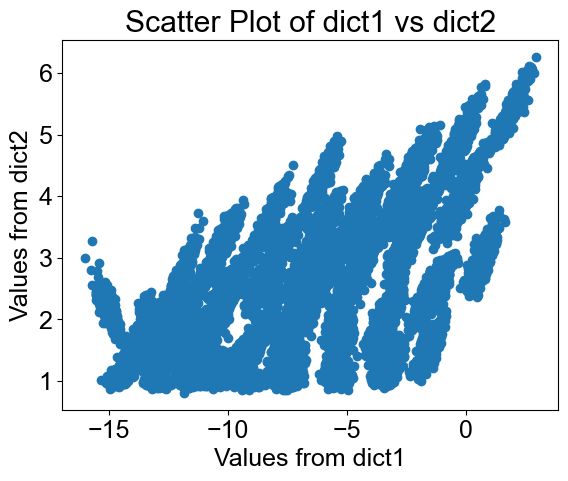

In [ ]:
import matplotlib.pyplot as plt

keys = dop.keys() & overpotentials.keys()
x_values = [dop[key] for key in keys]
y_values = [overpotentials[key][1] for key in keys]

# 绘图
plt.scatter(x_values, y_values)
plt.xlabel('Values from dict1')
plt.ylabel('Values from dict2')
plt.title('Scatter Plot of dict1 vs dict2')
plt.show()

0.8078286064062667


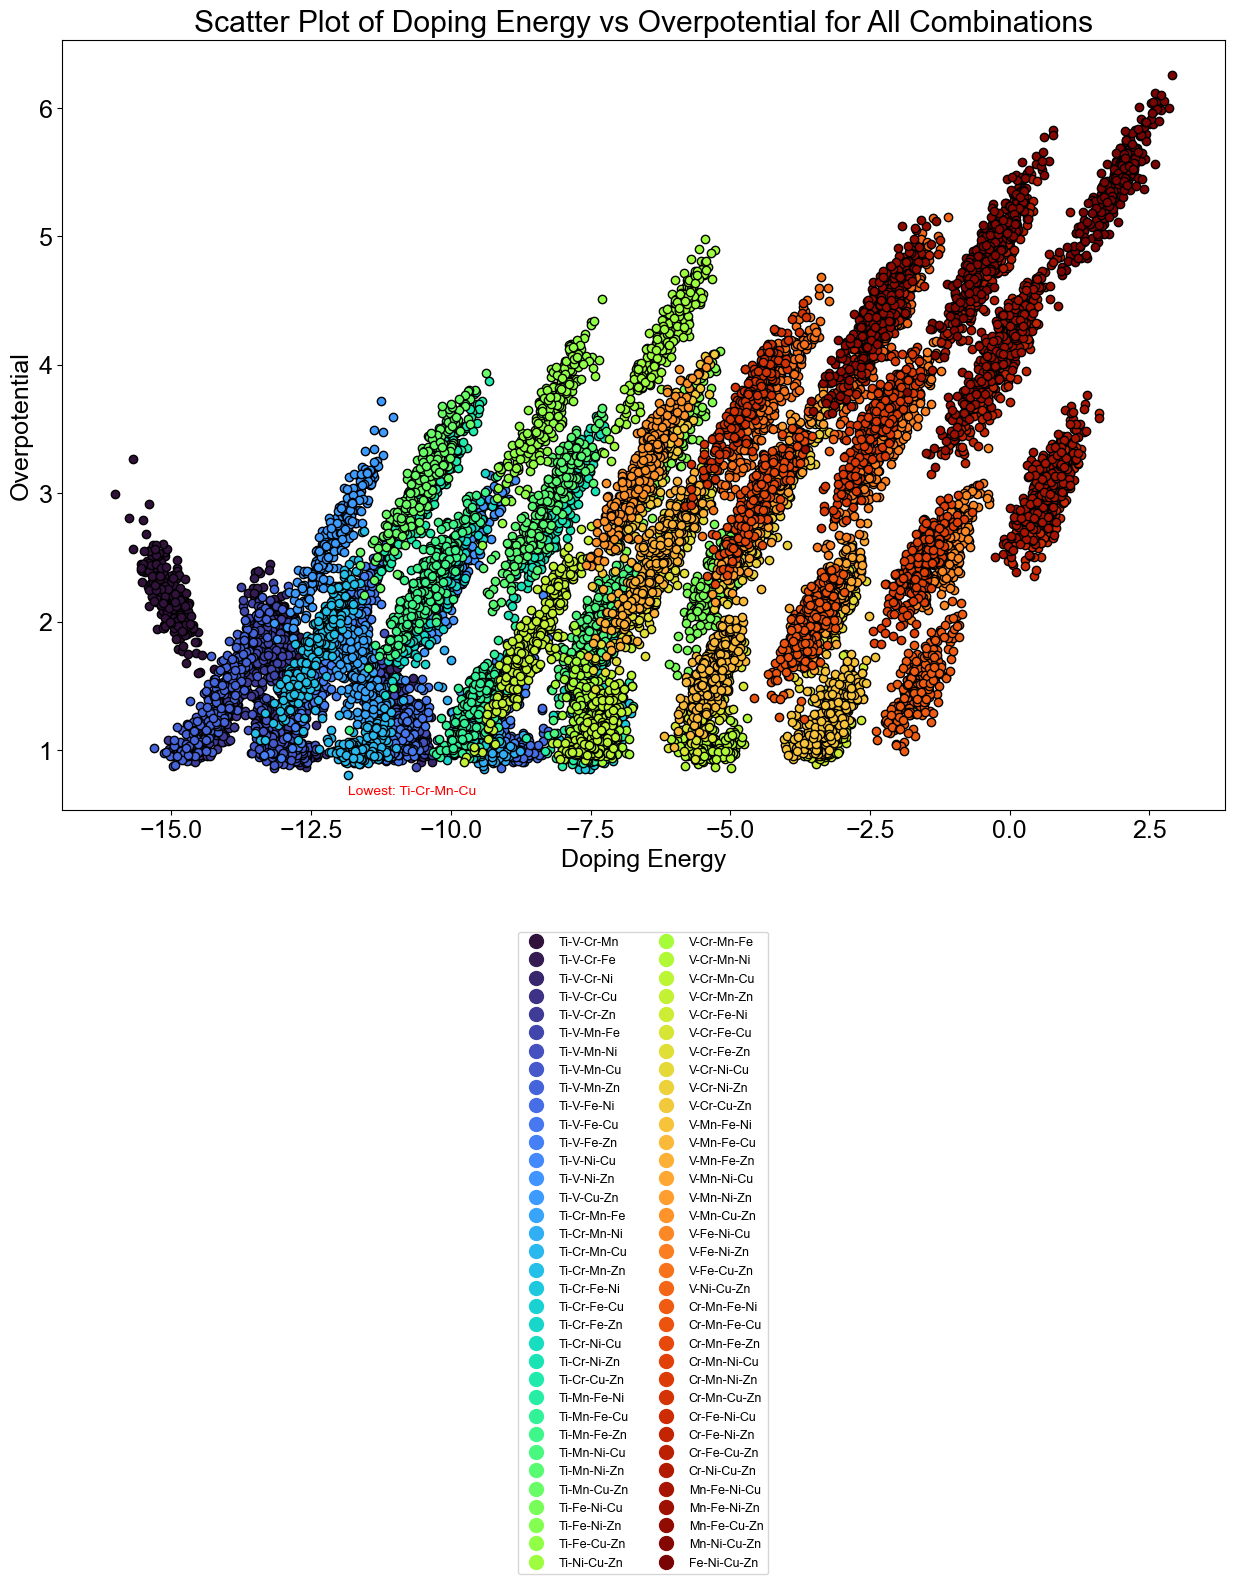

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from matplotlib import colormaps
import matplotlib.lines as mlines

# 给定元素列表
elements = ['Ti', 'V', 'Cr', 'Mn', 'Fe', 'Ni', 'Cu', 'Zn']
plt.rcParams.update({'font.size': 18, 'font.family': 'Arial'})
# 生成所有可能的两两组合
# combinations = [comb for comb in combinations(elements, 2) if 'Zn' in comb]
combinations = list(combinations(elements, 4))

# 分别存储包含每个组合的点
x_values_comb = {comb: [] for comb in combinations}
y_values_comb = {comb: [] for comb in combinations}

min_overpotential = float('inf')
min_comb = None
min_x = None
min_y = None

for key in dop.keys() & overpotentials_1.keys():
    x_val = dop[key]
    y_val = overpotentials[key][1]
    for comb in combinations:
        if all(element in key for element in comb):
            x_values_comb[comb].append(x_val)
            y_values_comb[comb].append(y_val)
            if y_val < min_overpotential:
                min_overpotential = y_val
                min_comb = comb
                min_x = x_val
                min_y = y_val

# 使用颜色映射
colormap = colormaps['turbo']  # 选择颜色映射
norm = plt.Normalize(0, len(combinations) - 1)  # 归一化器
print(min_y)
# 绘图
fig, ax = plt.subplots(figsize=(15, 10))
for i, comb in enumerate(combinations):
    plt.scatter(x_values_comb[comb], y_values_comb[comb], 
                label=f'{comb[0]}-{comb[1]}-{comb[2]}-{comb[3]}', 
                c=[colormap(norm(i))], edgecolor='k')

plt.xlabel('Doping Energy')
plt.ylabel('Overpotential')
plt.title('Scatter Plot of Doping Energy vs Overpotential for All Combinations')

# 标记最低的 overpotential 位置
if min_comb:
    plt.annotate(f'Lowest: {min_comb[0]}-{min_comb[1]}-{min_comb[2]}-{min_comb[3]}',
                 xy=(min_x, min_y), xytext=(min_x, min_y - 0.15),
                #  arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=10, color='red')

# 添加颜色尺
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
# cbar = plt.colorbar(sm, ax=ax)
# cbar.set_label('Combination Index')

# 创建带有颜色标记的自定义图例
# handles = [mlines.Line2D([], [], color=colormap(norm(i)), marker='o', linestyle='None', markersize=10, label=f'{comb[0]}-{comb[1]}-{comb[2]}-{comb[3]}') 
#            for i, comb in enumerate(combinations)]

plt.legend(handles=handles, fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.show()

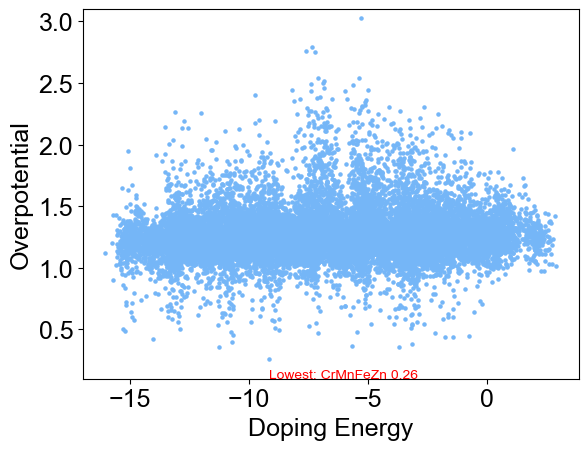

In [ ]:
import matplotlib.pyplot as plt
# 找到两个字典中共有的 key
# del overpotentials_1['Ti_V_Fe_Ni_3_16_8_12']
common_keys = set(overpotentials_1.keys()).intersection(dop.keys())

# 分别获取这些共有 key 的 x 和 y 值
y_values = [overpotentials_1[key][1] for key in common_keys]
x_values = [dop[key] for key in common_keys]
plt.rcParams.update({'font.size': 18, 'font.family': 'Arial'})

# 设置散点图的颜色和大小
scatter_color = (117/255, 182/255, 247/255)  # 将 RGB 值转换为 0-1 范围
plt.scatter(x_values, y_values, s=5, color=scatter_color)

# 找到 y 轴最小值的点
min_y_value = min(y_values)
min_x_value = x_values[y_values.index(min_y_value)]
min_y_index = y_values.index(min_y_value)
min_y_key = list(common_keys)[min_y_index]

# 标记 y 轴最小值的点
plt.annotate(f'Lowest: CrMnFeZn {"{:.2f}".format(min_y_value)}',
             xy=(min_x_value, min_y_value), xytext=(min_x_value, min_y_value - 0.15),
             fontsize=10, color='red')

# 输出 key 对应的最小 y 值
# print(f"y 轴最小值的点对应的 key 是: CrMnFeZn")
plt.ylim(0.1, 3.1)
# 显示图表
plt.xlabel('Doping Energy')
plt.ylabel('Overpotential')
# plt.title('Scatter Plot of Doping Energy vs Overpotential for All Combinations')

plt.show()


In [ ]:
import os
import numpy as np

def has_duplicates(lst):
    return len(lst) != len(set(lst))

def create_directory(parent_dir, new_dir_name):
    # 创建新目录的完整路径
    new_dir_path = os.path.join(parent_dir, new_dir_name)
    
    # 检查目录是否已经存在
    if not os.path.exists(new_dir_path):
        os.makedirs(new_dir_path)
target_path = []

folder_path = "D:\\POSCAR_data_four\\POSCAR_data_four"
# 获取目标文件夹下的所有子文件夹
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]

for folder in subfolders:
    txt = folder.split("\\")[-1]
    ele = txt.split('_')[:4]
    if has_duplicates(ele):
        continue
    create_directory(folder, "O")
    create_directory(folder, "OH")
    create_directory(folder, "OOH")
    poscar_path = os.path.join(folder, "POSCAR")
    with open(poscar_path, 'r') as f:
        lines = f.readlines()
    target_path.append(poscar_path)

    atom_coords= []
    for line in lines[8:120]:
        atom_coords.append(list(map(float, line.split()[:3])))
    # print(atom_coords[0])
    i = 0
    for coords in atom_coords:

        elements = lines[5].split()
        counts = lines[6].split()

        if 0.32 < float(coords[2]) < 0.33:
            # print(os.path.join(folder, f"O\\POSCAR{i}"))
            # print(coords[2])
            target_path.append(os.path.join(folder, f"O\\POSCAR{i}"))
            target_path.append(os.path.join(folder, f"OH\\POSCAR{i}"))
            target_path.append(os.path.join(folder, f"OOH\\POSCAR{i}"))

            with open(os.path.join(folder, f"O\\POSCAR{i}"), 'w') as f:
                elements.append("O")
                counts.append("1")
                f.writelines(lines[:5])
                f.writelines(" ".join(elements) + "\n")
                f.writelines(" ".join(counts) + "\n")
                f.writelines(lines[7:120])
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.391) + "\n")
            
            with open(os.path.join(folder, f"OH\\POSCAR{i}"), 'w') as f:
                elements.append("H")
                counts.append("1")
                f.writelines(lines[:5])
                f.writelines(" ".join(elements) + "\n")
                f.writelines(" ".join(counts) + "\n")
                f.writelines(lines[7:120])
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.391) + "\n")
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.441) + "\n")

            with open(os.path.join(folder, f"OOH\\POSCAR{i}"), 'w') as f:
                elements.insert(-2, "O")
                counts.append("1")
                f.writelines(lines[:5])
                f.writelines(" ".join(elements) + "\n")
                f.writelines(" ".join(counts) + "\n")
                f.writelines(lines[7:120])
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.391) + "\n")
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.451) + "\n")
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.501) + "\n")
            i += 1
        else:
            # print(coords[2])
            continue


In [ ]:
print(len(target_path))


1543543


In [194]:
from typing import Dict, List
import os
import numpy as np
from ase import Atoms
from ase.neighborlist import NeighborList
from ase.io import read
from collections import Counter
import json

root_path = "D:\\pre_train\\checkpoint\\equiformerV2\\train_record\\预测"

def has_duplicates(lst):
    return len(lst) != len(set(lst))

def euclidean_distance(coord1, coord2):
    """计算两个三维坐标的欧氏距离"""
    return np.sqrt((coord2[0] - coord1[0])**2 + 
                   (coord2[1] - coord1[1])**2 + 
                   (coord2[2] - coord1[2])**2)

def find_three_nearest_atoms(atoms, target_index: int):
    """从POSCAR文件中查找某个原子最近的三个邻居原子"""
    # 获取原子的范德华半径（或者可以自定义cutoff距离）
    cutoffs = [atoms.get_distance(i, target_index, mic=True) + 0.2 for i in range(len(atoms))]

    # 创建邻近列表，基于cutoffs自动生成相邻原子对
    nl = NeighborList(cutoffs=cutoffs, skin=0.0, self_interaction=False, bothways=True)
    nl.update(atoms)

    # 查找给定原子的所有邻居
    indices, offsets = nl.get_neighbors(target_index)

    # 计算邻居原子到目标原子的距离（考虑周期性边界条件）
    distances = [atoms.get_distance(target_index, i, mic=True) for i in indices]

    # 将邻居及其距离按距离排序，并选出前三个
    nearest_atoms_with_distances = sorted(zip(indices, distances), key=lambda x: x[1])[:3]

    return nearest_atoms_with_distances

def calculate_distances_to_list(atoms, fixed_atom_index: int, atom_list: list):
    """计算固定原子与一个列表中的多个原子之间的距离，并找到最小的三个距离的索引"""
    # 存储每个原子的距离
    distances = []
    
    # 遍历 atom_list 中的原子，计算与 fixed_atom_index 的距离
    for atom_index in atom_list:
        distance = atoms.get_distance(fixed_atom_index, atom_index, mic=True)
        distances.append((atom_index, distance))  # 存储原子的索引和距离
    
    # 按照距离对 (atom_index, distance) 进行排序，按距离升序排序
    sorted_distances = sorted(distances, key=lambda x: x[1])
    
    # 提取最小的三个距离的原子索引
    min_three_distances = sorted_distances[:3]  # 取前3个最小的
    min_indices = [atom_list.index(item[0]) for item in min_three_distances]  # 提取原子索引

    
    return min_indices, min_three_distances

def get_dop(jiyuan_path:int):
    data = []
    for i in range(5):
        if jiyuan_path == 4:
            with open(f"D:\pre_train\checkpoint\equiformerV2\\train_record\预测\\siyuan\\siyuanyuce_doping_0_{i}.txt", 'r')as file:
                data4 = file.readlines()
            data.append(data4)
        if jiyuan_path == 2:
            with open(f"D:\pre_train\checkpoint\equiformerV2\\train_record\预测\\eryuan\\eryuanyuce_doping_0_{i}.txt", 'r')as file:
                data3 = file.readlines()
            data.append(data3)
        if jiyuan_path == 3:
            with open(f"D:\pre_train\checkpoint\equiformerV2\\train_record\预测\\sanyuan\\sanyuanyuce_doping_0_{i}.txt", 'r')as file:
                data2 = file.readlines()
            data.append(data2)

    basedE = []
    elements_doping = []
    for i in range(len(data[0])):
        avergae_energy = 0.0
        for j in range(1):
            avergae_energy += float(data[j][i].split()[0])
        basedE.append(avergae_energy/1)
        elements_doping.append(data[0][i].split()[-1])

    element_energy = {
        "Ti": -8.294,
        "V": -9.512,
        "Cr": -9.948,
        "Mn": -9.332,
        "Fe": -8.583,
        "Co": -7.397,
        "Ni": -5.914,
        "Cu": -4.293,
        "Zn": -1.471,
        'Sc': -6.538
    }

    dop = {}
    basedE_dict = {}
    for i, ele in enumerate(elements_doping):
        basedE_dict[ele.strip("[]'")] = basedE[i]
        e1 = basedE[i] + 644.61173
        ele1 = ele.strip("[]'")
        ele1 = ele1.split("_")
        if jiyuan_path == 4:
            ele1 = [ele1[0], ele1[1], ele1[2], ele1[3]]
        if jiyuan_path == 3:
            ele1 = [ele1[0], ele1[1], ele1[2]]
        if jiyuan_path == 2:
            ele1 = [ele1[0], ele1[1]]

        if has_duplicates(ele1):
            continue

        for x in ele1:
            e1 = e1 + element_energy["Co"] - element_energy[x]
        dop[ele.strip("[]'")] = e1
    return dop, basedE_dict

def get_dop1(jiyuan_path:int):
    if jiyuan_path == 4:
        with open(f"D:\pre_train\checkpoint\equiformerV2\\train_record\\siyuanyuce_doping.txt", 'r')as file:
            data = file.readlines()

    basedE = []
    elements_doping = []
    for da in data:
        basedE.append(float(da.split()[0]))
        elements_doping.append(da.split()[-1])

    element_energy = {
        "Ti": -8.294,
        "V": -9.512,
        "Cr": -9.948,
        "Mn": -9.332,
        "Fe": -8.583,
        "Co": -7.397,
        "Ni": -5.914,
        "Cu": -4.293,
        "Zn": -1.471,
        'Sc': -6.538
    }

    dop = {}
    basedE_dict = {}
    for i, ele in enumerate(elements_doping):
        basedE_dict[ele.strip("[]'")] = basedE[i]
        e1 = basedE[i] + 644.61173
        ele1 = ele.strip("[]'")
        ele1 = ele1.split("_")
        if jiyuan_path == 4:
            ele1 = [ele1[0], ele1[1], ele1[2], ele1[3]]
        if jiyuan_path == 3:
            ele1 = [ele1[0], ele1[1], ele1[2]]
        if jiyuan_path == 2:
            ele1 = [ele1[0], ele1[1]]

        if has_duplicates(ele1):
            continue

        for x in ele1:
            e1 = e1 + element_energy["Co"] - element_energy[x]
        dop[ele.strip("[]'")] = e1
    return dop, basedE_dict

def get_overpotential(based_energy: float, O_energy: List[float], OH_energy: List[float], OOH_energy: List[float], judge: bool) -> List[float]:
    a1, a2, a3 = 0.352, 0.043, 0.346
    a4, a5, a6 = -9.86717672, -14.21525147, -6.82166311
    delter_1 = []
    delter_2 = []
    delter_3 = []
    delter_4 = []
    fine_based_energy = based_energy + 2 * a5

    for i in range(min(len(O_energy), len(OH_energy), len(OOH_energy))):
        delter_1.append(OH_energy[i] + a1 + 0.5 * a6 - based_energy - a5)
        delter_2.append(O_energy[i] + a2 + 0.5 * a6 - OH_energy[i] - a1)
        delter_3.append(OOH_energy[i] + a3 + 0.5 * a6 - O_energy[i] - a2 - a5)
        delter_4.append(based_energy + a4 + 0.5 * a6 - a3 - OOH_energy[i])

    return [max(delter_1[i], delter_2[i], delter_3[i], delter_4[i]) - 1.23 for i in range(len(delter_1))]

def get_split_checkpoints_overpotential(path: str, overpotentials: Dict[str, List[List[float]]], judge: bool, basedE_dict) -> Dict[str, List[List[float]]]:
    with open(path, 'r') as f:
        data = f.readlines()

    energys = [float(da.split()[0]) for da in data]
    paths = [da.split()[-1] for da in data]

    for i in range(len(paths) // 49):
        index_paths_plus = paths[i * 49].strip("[]'").split("\\\\")[-2]

        based_energy = basedE_dict[index_paths_plus]
        extra_energy = energys[i * 49 + 1:(i + 1) * 49]

        O_energy = extra_energy[0::3]
        OH_energy = extra_energy[1::3]
        OOH_energy = extra_energy[2::3]

        over = get_overpotential(based_energy, O_energy, OH_energy, OOH_energy, True)
        if judge:
            overpotentials[index_paths_plus] = [over]
        else:
            overpotentials[index_paths_plus].append(over)

    return overpotentials

def calculate_column_boxplot_data(overpotentials: Dict[str, List[List[float]]]) -> Dict[str, List[Dict[str, float]]]:
    boxplot_data = {}
    
    for key, values in overpotentials.items():
        # 转置二维数组，提取列数据
        transposed_data = list(zip(*values))
        
        column_stats = []
        for column in transposed_data:
            # 计算统计值
            # if key == "Ti_Fe_Ni_Zn_9_1_14_7" or key == "Cr_Fe_Cu_Zn_11_6_7_3" or key == "Mn_Fe_Ni_Zn_1_10_7_3":
            #     print(key, column)
            q1 = np.percentile(column, 25)  # 第一四分位数
            median = np.median(column)       # 中位数
            mean_value = np.mean(column)     # 平均数
            q3 = np.percentile(column, 75)   # 第三四分位数
            min_value = np.min(column)       # 最小值
            max_value = np.max(column)       # 最大值
            
            # 存储结果
            column_stats.append({
                'min': min_value,
                'q1': q1,
                'median': median,
                'mean': mean_value,
                'q3': q3,
                'max': max_value
            })
        
        # 将列的统计数据存储在结果字典中
        boxplot_data[key] = column_stats
    
    return boxplot_data

def compare_boxplot_statistics(boxplot_results: Dict[str, List[Dict[str, float]]]) -> Dict[str, Dict[str, int]]:
    min_values = {}
    
    for key, stats_list in boxplot_results.items():
        # 创建一个字典存储所有统计值的比较结果
        overall_stats = {}
        
        # 收集所有统计值
        for stats in stats_list:
            overall_stats['min'] = overall_stats.get('min', []) + [stats['min']]
            overall_stats['q1'] = overall_stats.get('q1', []) + [stats['q1']]
            overall_stats['median'] = overall_stats.get('median', []) + [stats['median']]
            overall_stats['mean'] = overall_stats.get('mean', []) + [stats['mean']]
            overall_stats['q3'] = overall_stats.get('q3', []) + [stats['q3']]
            overall_stats['max'] = overall_stats.get('max', []) + [stats['max']]
        
        # 找到每个统计值的最小值及其索引
        for stat_name, values in overall_stats.items():
            min_value = min(values)
            min_index = values.index(min_value)
            if key not in min_values:
                min_values[key] = {}
            min_values[key][stat_name] = {'min_value': min_value, 'index': min_index}
            # if key == "Cr_Fe_Cu_Zn_11_6_7_3":
            #     print(key, stat_name, values, min_value, min_index)
    
    return min_values

def judge_Zn_O_importance(min_values: Dict[str, Dict[str, int]], atom_S, yuanshu: int):
    if yuanshu == 4:
        path_ = "D:\\POSCAR_data_four\\POSCAR_data_four"
    if yuanshu == 3:
        path_ = "D:\\POSCAR_data_three"
    if yuanshu == 2:
        path_ = "D:\\POSCAR_data_two"

    shuliang_Zn_O_best_min = 0
    shuliang_Zn_O_best_mean = 0
    shuliang_Zn_O_best_median = 0
    total_shuliang = 0

    for key, stats in min_values.items():
        if atom_S not in key:
            continue

        min_value_index = stats['min']['index']
        max_value_index = stats['max']['index']
        q1_value_index = stats['q1']['index']
        q3_value_index = stats['q3']['index']
        median_value_index = stats['median']['index']
        mean_value_index = stats['mean']['index']

        poscarss = os.path.join(path_, key)
        poscarss = os.path.join(poscarss, "POSCAR")
        atoms = read(poscarss)

        with open(poscarss, 'r') as f:
            lines = f.readlines()

        atom_coords= []
        for line in lines[8:120]:
            atom_coords.append(list(map(float, line.split()[:3])))
        
        elements = lines[5].split()
        counts = list(map(int, lines[6].strip().split()))

        expanded_elements = [element for element, count in zip(elements, counts) for _ in range(count)]

        Zn_corrd_index = expanded_elements.index(atom_S)

        O_corrd_index = []
        for coords in atom_coords:
            if 0.32 < float(coords[2]) < 0.33:
                O_corrd_index.append(atom_coords.index(coords))
        indices, distance_min = calculate_distances_to_list(atoms, Zn_corrd_index, O_corrd_index)

        # if key == "Cr_Fe_Cu_Zn_11_6_7_3":
        #     print(key, median_value_index, indices)

        three_tms_comb_min = {}
        
        if min_value_index in indices:
            O_index = O_corrd_index[min_value_index]
            nearest_atoms = find_three_nearest_atoms(atoms, O_index)
            elename = []
            for idx, dist in nearest_atoms:
                elename.append(expanded_elements[idx])
            three_tms_comb_min[key] = elename
            # print(elename)
            shuliang_Zn_O_best_min += 1
            # print(f"{key} has the smallest overpotential value")
        if mean_value_index in indices:
            shuliang_Zn_O_best_mean += 1
        #     # print(f"{key} has the smallest mean overpotential value")
        if median_value_index in indices:
            shuliang_Zn_O_best_median += 1
        # if max_value_index in indices:
        #     shuliang_Zn_O_best_max += 1
        # if q1_value_index in indices:
        #     shuliang_Zn_O_best_q1 += 1
        # if q3_value_index in indices:
        #     shuliang_Zn_O_best_q3 += 1
        #     # print(f"{key} has the smallest median overpotential value")
        total_shuliang += 1
    print(shuliang_Zn_O_best_min/total_shuliang, shuliang_Zn_O_best_mean/total_shuliang, shuliang_Zn_O_best_median/total_shuliang) #, shuliang_Zn_O_best_max/total_shuliang, shuliang_Zn_O_best_q1/total_shuliang, shuliang_Zn_O_best_q3/total_shuliang)

def find_key_of_global_min(min_values):

    min_value = float('inf')
    min_key = None
    min_index = None
    mean_value = float('inf')
    mean_key = None
    mean_index = None
    median_value = float('inf')
    median_key = None
    median_index = None

    all_mean_values = []
    all_median_values = []

    for key, stats in min_values.items():
        if stats['min']['min_value'] < min_value:
            min_value = stats['min']['min_value']
            min_key = key
            min_index = stats['min']['index']
        if stats['mean']['min_value'] < mean_value:
            mean_value = stats['mean']['min_value']
            mean_key = key
            mean_index = stats['mean']['index']
        if stats['median']['min_value'] < median_value:
            median_value = stats['median']['min_value']
            median_key = key
            median_index = stats['median']['index']

        all_mean_values.append((key, stats['mean']['min_value'], stats['mean']['index']))
        all_median_values.append((key, stats['median']['min_value'], stats['median']['index']))

    all_mean_values.sort(key=lambda x: x[1])
    all_median_values.sort(key=lambda x: x[1])
    
    # Get the smallest five 'min_values'
    # smallest_five_values = all_mean_values[:20]
    # print("Five smallest min_values and their corresponding keys:")
    # for key, value, index in smallest_five_values:
    #     print(f"Key: {key}, Min Value: {value}, the index: {index}")
    smallest_five_values = all_median_values[:100]
    print("Five smallest median_values and their corresponding keys:")
    for key, value, index in smallest_five_values:
        print(f"Key: {key}, Median Value: {value}, the index: {index}")

    # print(f"Min: {min_key} with value {min_value} at index {min_index}")
    # print(f"Mean: {mean_key} with value {mean_value} at index {mean_index}")
    print(f"Median: {median_key} with value {median_value} at index {median_index}")

def huoxingweidian_tmpaibu(min_values, boxdata_name, yuanshu, ov, atom_S):

    if yuanshu == 4:
        path_ = "D:\\POSCAR_data_four\\POSCAR_data_four"
    if yuanshu == 3:
        path_ = "D:\\POSCAR_data_three"
    if yuanshu == 2:
        path_ = "D:\\POSCAR_data_two"
    comb_activeTM = {}
    j = 0
    for key, stats in min_values.items():
        if stats[boxdata_name]['min_value'] > ov or atom_S not in key:
            continue
        O_index = stats[boxdata_name]['index']
        poscarss = os.path.join(path_, key)
        poscarss = os.path.join(poscarss, "POSCAR")
        atoms = read(poscarss)
        with open(poscarss, 'r') as f:
            lines = f.readlines()

        atom_coords= []
        for line in lines[8:120]:
            atom_coords.append(list(map(float, line.split()[:3])))
        elements = lines[5].split()
        counts = list(map(int, lines[6].strip().split()))

        expanded_elements = [element for element, count in zip(elements, counts) for _ in range(count)]

        TM_name = []
        O_corrd_index = []
        TM_corrd_index = []
        for coords in atom_coords:
            if 0.26 < float(coords[2]) < 0.30:
                TM_corrd_index.append(atom_coords.index(coords))
                TM_name.append(expanded_elements[atom_coords.index(coords)])
            if 0.32 < float(coords[2]) < 0.33:
                O_corrd_index.append(atom_coords.index(coords))

        active_site_O_real_index = O_corrd_index[O_index]

        indices, distance_min = calculate_distances_to_list(atoms, active_site_O_real_index, TM_corrd_index)
        # if key == "Cr_Fe_Cu_Zn_11_6_7_3":
        #     print(TM_name)
        #     print(expanded_elements)
        #     print(key, indices)

        t = []
        for ind in indices:
            t.append(TM_name[ind])
        if atom_S not in t:
            continue
        t_key = frozenset(Counter(t).items())

        if t_key not in comb_activeTM:
            comb_activeTM[t_key] = [1, [stats[boxdata_name]['min_value']]]
            # comb_activeTM[]
        else:
            comb_activeTM[t_key][0] += 1
            comb_activeTM[t_key][1].append(stats[boxdata_name]['min_value'])
        j = j + 1
    top_keys = sorted(comb_activeTM, key=lambda x: comb_activeTM[x][0], reverse=True)[:10]
    # for key in top_keys:
    #     print(key, comb_activeTM[key]/j)
    for key in top_keys:
        frequency_ratio = comb_activeTM[key][0] / j
        box_data = comb_activeTM[key][1]

        # 计算箱线图数据
        box_plot_data = {
            "min": np.min(box_data),                # 最小值
            "q1": np.percentile(box_data, 25),     # 第一四分位数
            "median": np.percentile(box_data, 50), # 中位数
            "q3": np.percentile(box_data, 75),     # 第三四分位数
            "max": np.max(box_data)                # 最大值
        }

        # 输出结果
        print(f"Key: {key}")
        print(f"Frequency Ratio: {frequency_ratio}")
        print(f"Box Plot Data: {box_plot_data}")
    # print(top_keys, comb_activeTM[top_keys[0]], comb_activeTM[top_keys[1]], comb_activeTM[top_keys[2]])

def huoxingweidian_tmpaibu_1(min_values, boxdata_name, yuanshu, ov, atom_S):

    if yuanshu == 4:
        path_ = "D:\\POSCAR_data_four\\POSCAR_data_four"
    if yuanshu == 3:
        path_ = "D:\\POSCAR_data_three"
    if yuanshu == 2:
        path_ = "D:\\POSCAR_data_two"
    comb_activeTM = {}
    j = 0
    for key, stats in min_values.items():
        if atom_S not in key:
            continue
        O_index = stats[boxdata_name]['index']
        poscarss = os.path.join(path_, key)
        poscarss = os.path.join(poscarss, "POSCAR")
        atoms = read(poscarss)
        with open(poscarss, 'r') as f:
            lines = f.readlines()

        atom_coords= []
        for line in lines[8:120]:
            atom_coords.append(list(map(float, line.split()[:3])))
        elements = lines[5].split()
        counts = list(map(int, lines[6].strip().split()))

        expanded_elements = [element for element, count in zip(elements, counts) for _ in range(count)]

        TM_name = []
        O_corrd_index = []
        TM_corrd_index = []
        for coords in atom_coords:
            if 0.26 < float(coords[2]) < 0.30:
                TM_corrd_index.append(atom_coords.index(coords))
                TM_name.append(expanded_elements[atom_coords.index(coords)])
            if 0.32 < float(coords[2]) < 0.33:
                O_corrd_index.append(atom_coords.index(coords))

        active_site_O_real_index = O_corrd_index[O_index]

        indices, distance_min = calculate_distances_to_list(atoms, active_site_O_real_index, TM_corrd_index)
        # if key == "Cr_Fe_Cu_Zn_11_6_7_3":
        #     print(TM_name)
        #     print(expanded_elements)
        #     print(key, indices)

        t = []
        for ind in indices:
            t.append(TM_name[ind])
        t_key = frozenset(Counter(t).items())

        if t_key not in comb_activeTM:
            comb_activeTM[t_key] = 1
        else:
            comb_activeTM[t_key] += 1
        j = j + 1
    top_keys = sorted(comb_activeTM, key=comb_activeTM.get, reverse=True)[:10]
    for key in top_keys:
        print(key, comb_activeTM[key]/j)
    # print(top_keys, comb_activeTM[top_keys[0]], comb_activeTM[top_keys[1]], comb_activeTM[top_keys[2]])


9.34494111333333 8.997244413333332 9.138145393333334 9.3819014
[7.636753883333332, 9.869227, 12.730175933333333, 7.3983791666666665, 9.090169583333331] [7.438448816666668, 9.406280933333333, 12.160105533333333, 7.217402, 8.763984783333333] [7.521235083333334, 9.610360966666667, 12.324630233333334, 7.336041533333333, 8.898459149999999] [7.808616116666666, 9.81409005, 12.6431008, 7.572510916666667, 9.071189116666666]
9.090169583333331 8.763984783333333 8.898459149999999 9.071189116666666
[1.0, 0.0, 0.41226435648340026, 0.9418106954503539]


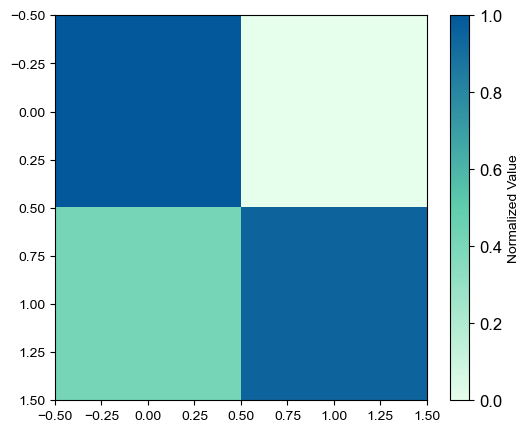

In [114]:
file_names = [f'D:\pre_train\checkpoint\equiformerV2\\train_record\预测\\siyuan_test_score_0_{i}.txt' for i in range(5)]
tifenizn_slab_structurebatch = {}
for z, filesssss in enumerate(file_names):
    with open(filesssss, 'r') as f:
        lines = f.readlines()
    for lin in lines:
        if "Ti_Fe_Ni_Zn_9_1_14_7\\\\POSCAR" in lin:
            if z == 0:
                tifenizn_slab_structurebatch["D:\\POSCAR_data_four\\POSCAR_data_four\\Ti_Fe_Ni_Zn_9_1_14_7\\POSCAR"] = [lin.split("]")[-1]]
            else:
                tifenizn_slab_structurebatch["D:\\POSCAR_data_four\\POSCAR_data_four\\Ti_Fe_Ni_Zn_9_1_14_7\\POSCAR"].append(lin.split("]")[-1])

for key, value in tifenizn_slab_structurebatch.items():
    ZnO6_slab_att = [44, 56, 87, 100, 102, 97, 111]
    NiO6_slab_att = [87, 50, 81, 100, 99, 95, 110]
    FeO6_slab_att = [104, 95, 106, 69, 62, 50, 109]
    TiO6_slab_att = [103, 96, 98, 86, 45, 74, 108]
    ZnO6att = []
    NiO6att = []
    FeO6att = []
    TiO6att = []
    # print(value)
    for val in value:
        val = val.strip().split()
        # print(val)
        Zn = 0
        Ni = 0
        Fe = 0
        Ti = 0
        for i in range(6):
            Zn += float(val[ZnO6_slab_att[i]])
            Ni += float(val[NiO6_slab_att[i]])
            Fe += float(val[FeO6_slab_att[i]])
            Ti += float(val[TiO6_slab_att[i]])
        Zn = Zn/6 + float(val[ZnO6_slab_att[6]])
        Ni = Ni/6 + float(val[NiO6_slab_att[6]])
        Fe = Fe/6 + float(val[FeO6_slab_att[6]])
        Ti = Ti/6 + float(val[TiO6_slab_att[6]])
        ZnO6att.append(Zn)
        NiO6att.append(Ni)
        FeO6att.append(Fe)
        TiO6att.append(Ti)
    print(sum(ZnO6att)/len(ZnO6att), sum(NiO6att)/len(NiO6att), sum(FeO6att)/len(FeO6att), sum(TiO6att)/len(TiO6att))
    from statistics import median
    print(ZnO6att, NiO6att, FeO6att, TiO6att)
    print(median(ZnO6att), median(NiO6att), median(FeO6att), median(TiO6att))
    list1111 = [median(ZnO6att), median(NiO6att), median(FeO6att), median(TiO6att)]
    min_val = min(list1111)
    max_val = max(list1111)
    normalized_lst = [(x - min_val) / (max_val - min_val) for x in list1111]
    print(normalized_lst)


from matplotlib.colors import LinearSegmentedColormap
# 将一维列表转换为 2x2 矩阵
plt.figure(figsize=(6, 5))
data_matrix = np.array(normalized_lst).reshape(2, 2)
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_cmap', ['#E6FEEC', '#5FCDAC', '#03589B']
)
# 绘制热力图
plt.imshow(data_matrix, cmap=custom_cmap, aspect='auto')
cbar = plt.colorbar(label='Normalized Value')
cbar.ax.tick_params(labelsize=12)





In [122]:
nums_list = ['0', ]
overpotentials = {}
yuanshu = 4
names = None
dop, basedE_dict = get_dop1(yuanshu)
if yuanshu == 4:
    names = "siyuan"
if yuanshu == 3:
    nmaes = "sanyuan"
if yuanshu == 2:
    names = "eryuan"
for ele in nums_list:
    for i in range(5): #3,4 --- 0
        checkpoints_name = f"{names}\\siyuanyuce_overpotential_{ele}_{str(i)}.txt"
        path = os.path.join(root_path, checkpoints_name)

        judge = (ele == nums_list[0] and i == 0)
        
        overpotentials = get_split_checkpoints_overpotential(path, overpotentials, judge, basedE_dict)

boxplot_results = calculate_column_boxplot_data(overpotentials)

min_values = compare_boxplot_statistics(boxplot_results)
huoxingweidian_tmpaibu(min_values, "median", yuanshu, 0.4, "Zn")
print("                                                         ")
huoxingweidian_tmpaibu(min_values, "median", yuanshu, 0.5, "Zn")

frozenset({('Co', 2), ('Zn', 1)}) 0.38562091503267976
frozenset({('Zn', 1), ('Cu', 1), ('Co', 1)}) 0.1830065359477124
frozenset({('Zn', 1), ('Ni', 1), ('Co', 1)}) 0.1830065359477124
frozenset({('Co', 3)}) 0.13725490196078433
frozenset({('Zn', 1), ('Fe', 1), ('Co', 1)}) 0.06535947712418301
frozenset({('Zn', 1), ('Cr', 1), ('Co', 1)}) 0.0196078431372549
frozenset({('Zn', 1), ('Fe', 1), ('Cu', 1)}) 0.013071895424836602
frozenset({('Zn', 1), ('Ti', 1), ('Co', 1)}) 0.006535947712418301
frozenset({('Co', 2), ('Cu', 1)}) 0.006535947712418301
                                                         
frozenset({('Co', 2), ('Zn', 1)}) 0.47756729810568294
frozenset({('Co', 3)}) 0.14955134596211367
frozenset({('Zn', 1), ('Cu', 1), ('Co', 1)}) 0.12612163509471586
frozenset({('Zn', 1), ('Ni', 1), ('Co', 1)}) 0.0847457627118644
frozenset({('Zn', 1), ('Fe', 1), ('Co', 1)}) 0.05583250249252243
frozenset({('Zn', 1), ('Cr', 1), ('Co', 1)}) 0.040877367896311065
frozenset({('Zn', 1), ('Mn', 1), ('Co', 1)})

In [217]:
for x in ["Zn", "Ni", "Fe", "Mn", "Cr", "Ti", "V", "Cu"]:
    huoxingweidian_tmpaibu_1(min_values, "median", yuanshu, 0.6, x)
    print(f"------------------------{x}---------------------------")


frozenset({('Co', 2), ('Zn', 1)}) 0.4735458804708033
frozenset({('Co', 3)}) 0.1418123643012227
frozenset({('Zn', 1), ('Cu', 1), ('Co', 1)}) 0.07987658553308194
frozenset({('Zn', 1), ('Cr', 1), ('Co', 1)}) 0.051536967203748146
frozenset({('Zn', 1), ('Ni', 1), ('Co', 1)}) 0.04548051651239858
frozenset({('Zn', 1), ('Fe', 1), ('Co', 1)}) 0.04033824705747915
frozenset({('Ti', 1), ('Zn', 1), ('Co', 1)}) 0.029253799565763912
frozenset({('Zn', 1), ('Mn', 1), ('Co', 1)}) 0.02833961832933379
frozenset({('Co', 2), ('Cu', 1)}) 0.02696834647468861
frozenset({('Co', 2), ('Cr', 1)}) 0.012798537310021712
------------------------Zn---------------------------
frozenset({('Co', 3)}) 0.3673142857142857
frozenset({('Co', 2), ('Zn', 1)}) 0.19588571428571427
frozenset({('Co', 2), ('Cu', 1)}) 0.09188571428571428
frozenset({('Zn', 1), ('Ni', 1), ('Co', 1)}) 0.04548571428571429
frozenset({('Co', 2), ('V', 1)}) 0.036457142857142855
frozenset({('Co', 2), ('Cr', 1)}) 0.03131428571428571
frozenset({('Co', 2), ('Ni'

In [195]:
for x in ["Zn", "Ni", "Fe", "Mn", "Cr", "Ti", "V", "Cu"]:
    huoxingweidian_tmpaibu(min_values, "median", yuanshu, 0.6, x)
    print(f"------------------------{x}---------------------------")


Key: frozenset({('Co', 2), ('Zn', 1)})
Frequency Ratio: 0.631331481085702
Box Plot Data: {'min': 0.3211645387500477, 'q1': 0.4883703492969227, 'median': 0.5242580635156802, 'q3': 0.5592932008594227, 'max': 0.5999731325000477}
Key: frozenset({('Zn', 1), ('Cu', 1), ('Co', 1)})
Frequency Ratio: 0.11241718315879462
Box Plot Data: {'min': 0.28777639296881263, 'q1': 0.4588598512500477, 'median': 0.5032228909375467, 'q3': 0.5472007975000245, 'max': 0.5990576051562977}
Key: frozenset({('Zn', 1), ('Ni', 1), ('Co', 1)})
Frequency Ratio: 0.0722376576191494
Box Plot Data: {'min': 0.2871679567187977, 'q1': 0.449864982070337, 'median': 0.4986852907031727, 'q3': 0.5407537721484852, 'max': 0.5992387953125626}
Key: frozenset({('Zn', 1), ('Cr', 1), ('Co', 1)})
Frequency Ratio: 0.057063475101517415
Box Plot Data: {'min': 0.37975637343756263, 'q1': 0.49132959671880516, 'median': 0.5280126832812977, 'q3': 0.5615058499219072, 'max': 0.5997289918750477}
Key: frozenset({('Zn', 1), ('Fe', 1), ('Co', 1)})
Frequ

In [196]:
for x in ["Zn", "Ni", "Fe", "Mn", "Cr", "Ti", "V", "Cu"]:
    huoxingweidian_tmpaibu(min_values, "median", yuanshu, 0.35, x)
    print(f"------------------------{x}---------------------------")

Key: frozenset({('Zn', 1), ('Ni', 1), ('Co', 1)})
Frequency Ratio: 0.38461538461538464
Box Plot Data: {'min': 0.2871679567187977, 'q1': 0.32071446679691495, 'median': 0.32787649062506263, 'q3': 0.3439158948437999, 'max': 0.3472265504687977}
Key: frozenset({('Co', 2), ('Zn', 1)})
Frequency Ratio: 0.34615384615384615
Box Plot Data: {'min': 0.3211645387500477, 'q1': 0.32711571578126675, 'median': 0.3419164918750477, 'q3': 0.3453344606250477, 'max': 0.3498510621875477}
Key: frozenset({('Zn', 1), ('Cu', 1), ('Co', 1)})
Frequency Ratio: 0.23076923076923078
Box Plot Data: {'min': 0.28777639296881263, 'q1': 0.3260626100391102, 'median': 0.33144800492193016, 'q3': 0.3368348362891139, 'max': 0.34606496718756263}
Key: frozenset({('Zn', 1), ('Fe', 1), ('Co', 1)})
Frequency Ratio: 0.038461538461538464
Box Plot Data: {'min': 0.3023657106250477, 'q1': 0.3023657106250477, 'median': 0.3023657106250477, 'q3': 0.3023657106250477, 'max': 0.3023657106250477}
------------------------Zn----------------------

In [186]:
def main():

    global root_path
    nums_list = ['0', ]
    overpotentials = {}
    yuanshu = 4
    names = None
    dop, basedE_dict = get_dop1(yuanshu)
    if yuanshu == 4:
        names = "siyuan"
    if yuanshu == 3:
        nmaes = "sanyuan"
    if yuanshu == 2:
        names = "eryuan"
    for ele in nums_list:
        for i in range(5): #3,4 --- 0
            checkpoints_name = f"{names}\\siyuanyuce_overpotential_{ele}_{str(i)}.txt"
            path = os.path.join(root_path, checkpoints_name)

            judge = (ele == nums_list[0] and i == 0)
            
            overpotentials = get_split_checkpoints_overpotential(path, overpotentials, judge, basedE_dict)

    boxplot_results = calculate_column_boxplot_data(overpotentials)
    # with open('D:\pre_train\checkpoint\equiformerV2\\train_record\overpotential-total\\output.txt', 'a') as file:
    #     json.dump(overpotentials, file)
    #     json.dump(boxplot_results, file)
    min_values = compare_boxplot_statistics(boxplot_results)
    find_key_of_global_min(min_values)
    for x in ["Zn", "Ni", "Fe", "Mn", "Cr", "Ti", "V", "Cu"]:
        judge_Zn_O_importance(min_values, x, yuanshu)
    # judge_Zn_O_importance(min_values)


if __name__ == "__main__":
    # 在这里调用主函数
    main()

Five smallest median_values and their corresponding keys:
Key: Ti_Fe_Ni_Zn_9_1_14_7, Median Value: 0.2871679567187977, the index: 8
Key: Cr_Fe_Cu_Zn_11_6_7_3, Median Value: 0.28777639296881263, the index: 8
Key: Mn_Fe_Ni_Zn_1_10_7_3, Median Value: 0.29458397750001675, the index: 8
Key: V_Mn_Fe_Ni_5_3_2_4, Median Value: 0.29516164687506263, the index: 4
Key: Ti_V_Fe_Ni_12_2_1_14, Median Value: 0.2995580934375477, the index: 11
Key: Ti_V_Fe_Ni_11_6_1_2, Median Value: 0.2999853395312977, the index: 8
Key: V_Mn_Fe_Ni_14_16_10_13, Median Value: 0.3010229371875477, the index: 11
Key: Ti_V_Fe_Ni_12_1_5_9, Median Value: 0.30120412734381263, the index: 13
Key: V_Mn_Fe_Zn_2_12_4_13, Median Value: 0.3023657106250477, the index: 6
Key: V_Mn_Fe_Ni_9_7_12_13, Median Value: 0.30529348281256263, the index: 0
Key: Ti_V_Cr_Fe_9_7_11_14, Median Value: 0.30593651656251675, the index: 2
Key: Ti_Cr_Mn_Fe_5_6_3_15, Median Value: 0.30724660781256263, the index: 13
Key: Ti_V_Mn_Fe_13_1_15_9, Median Value: 0.30

In [87]:
import os
import re

# 定义要读取的文件名列表
file_names = [f'D:\pre_train\checkpoint\equiformerV2\\train_record\预测\\siyuan_test_score_0_{i}.txt' for i in range(5)]

# 初始化存储结果的字典
data_dict = {}

# 定义所有需要匹配的类型前缀
identifiers = ["Cr_Fe_Cu_Zn_11_6_7_3", "Mn_Fe_Ni_Zn_1_10_7_3", "Ti_Fe_Ni_Zn_9_1_14_7"]

# POSCAR类型标签
poscar_types = ["POSCAR", r"O\\POSCAR", r"OH\\POSCAR", r"OOH\\POSCAR"]

for j, patg in enumerate(file_names):
    with open(patg, 'r') as f:
        lines = f.readlines()
    if j == 0:
        for i in range(0, len(lines), 4):
            parts0 = lines[i].split(']')
            parts1 = lines[i + 1].split(']')
            parts2 = lines[i + 2].split(']')
            parts3 = lines[i + 3].split(']')
            # print(parts0, parts1, parts2, parts3)
            numbers0 = list(map(float, parts0[1].strip().split()))
            numbers1 = list(map(float, parts1[1].strip().split()))
            numbers2 = list(map(float, parts2[1].strip().split()))
            numbers3 = list(map(float, parts3[1].strip().split()))

            last_4 = numbers0[-4:]
            last_5 = numbers1[-5:-1]
            last_6 = numbers2[-6:-2]
            last_7 = numbers3[-7:-3]
            data_dict[identifiers[(i // 4)]] = [[last_4, last_5, last_6, last_7]]
    else:
        for i in range(0, len(lines), 4):
            parts0 = lines[i].split(']')
            parts1 = lines[i + 1].split(']')
            parts2 = lines[i + 2].split(']')
            parts3 = lines[i + 3].split(']')
            # print(parts0, parts1, parts2, parts3)

            numbers0 = list(map(float, parts0[1].strip().split()))
            numbers1 = list(map(float, parts1[1].strip().split()))
            numbers2 = list(map(float, parts2[1].strip().split()))
            numbers3 = list(map(float, parts3[1].strip().split()))

            last_4 = numbers0[-4:]
            last_5 = numbers1[-5:-1]
            last_6 = numbers2[-6:-2]
            last_7 = numbers3[-7:-3]
            data_dict[identifiers[i // 4]].append([last_4, last_5, last_6, last_7])

# 打印或返回最终数据字典
print(data_dict)


{'Cr_Fe_Cu_Zn_11_6_7_3': [[[3.8434563, 3.6176133, 3.4855528, 3.7768278], [3.8341691, 3.613089, 3.680018, 3.6700401], [3.813086, 3.569283, 3.6038504, 3.732262], [3.8385482, 3.5614667, 3.6858761, 3.695506]], [[4.923332, 4.5445833, 4.534009, 4.9254336], [4.9352303, 4.527178, 4.6941457, 4.820485], [4.935298, 4.4845705, 4.608471, 4.998652], [4.938947, 4.4773197, 4.6848907, 4.8881626]], [[6.2296515, 5.840226, 5.8830447, 6.3824215], [6.245371, 5.82702, 6.067753, 6.161823], [6.2154455, 5.7626195, 5.9946003, 6.3729024], [6.2415648, 5.7509193, 6.068944, 6.2620482]], [[3.6886847, 3.5733695, 3.3813186, 3.663406], [3.6939096, 3.5650914, 3.5910685, 3.5856378], [3.685536, 3.5349324, 3.4998755, 3.6496878], [3.6962318, 3.52871, 3.6049063, 3.6254566]], [[4.5130043, 4.260436, 4.175003, 4.5686073], [4.517682, 4.2569957, 4.339753, 4.4233704], [4.5069, 4.2188377, 4.264181, 4.5762544], [4.508054, 4.2176037, 4.333561, 4.48682]]], 'Mn_Fe_Ni_Zn_1_10_7_3': [[[3.9736586, 3.597001, 3.557045, 3.798112], [3.8486373,

In [81]:
# 初始化存储差值的字典
diff_dict = {}

# 遍历 data_dict 中的每个 key
for key, value_list in data_dict.items():
    # 初始化每个 key 的差值列表
    diff_list = []
    
    # 遍历 value_list 中的每个元素 [[a], [b], [c], [d]]
    for value_group in value_list:
        a = value_group[0]
        b = value_group[1]
        c = value_group[2]
        d = value_group[3]
        
        # 计算 a-b, a-c, a-d
        diff_ab = [x - y for x, y in zip(a, b)]
        diff_ac = [x - y for x, y in zip(a, c)]
        diff_ad = [x - y for x, y in zip(a, d)]
        
        # 将差值存储到一个列表中
        diff_list.append([diff_ab, diff_ac, diff_ad])
    
    # 将每个 key 对应的差值列表存储到 diff_dict 中
    diff_dict[key] = diff_list

# 打印或返回最终的差值字典
print(diff_dict)
print(len(diff_dict['Cr_Fe_Cu_Zn_11_6_7_3'][0]), len(diff_dict['Cr_Fe_Cu_Zn_11_6_7_3'][0][0]), len(diff_dict['Cr_Fe_Cu_Zn_11_6_7_3']))

{'Cr_Fe_Cu_Zn_11_6_7_3': [[[0.009287200000000162, 0.004524299999999926, -0.19446520000000023, 0.10678769999999993], [0.03037029999999996, 0.04833029999999994, -0.1182976, 0.04456579999999999], [0.004908100000000193, 0.056146599999999935, -0.20032330000000043, 0.0813218]], [[-0.011898299999999473, 0.017405300000000068, -0.1601366999999998, 0.10494860000000017], [-0.011966000000000143, 0.06001279999999998, -0.07446199999999958, -0.07321840000000002], [-0.01561499999999949, 0.06726360000000042, -0.15088170000000023, 0.03727099999999961]], [[-0.015719499999999442, 0.013206000000000273, -0.1847082999999996, 0.22059850000000036], [0.014205999999999719, 0.0776065000000008, -0.11155559999999998, 0.009519100000000336], [-0.011913299999999793, 0.08930670000000074, -0.1858993, 0.12037330000000068]], [[-0.005224899999999977, 0.008278100000000066, -0.20974989999999982, 0.07776819999999995], [0.0031487000000001153, 0.03843709999999989, -0.11855689999999974, 0.013718200000000014], [-0.007547100000000

In [80]:
import numpy as np
import pandas as pd

# 初始化存储最终结果的字典
boxplot_dict1 = {}

# 遍历 diff_dict 中的每个 key
for key, value_list in diff_dict.items():
    # 转换 value_list 为 numpy 数组以便操作
    value_array = np.array(value_list)  # value_list 形状为 (5, 3, 4)
    
    # 对第二维度（行）取最大值，得到 (5, 4) 的二维数组
    max_2d_array = np.max(value_array, axis=1)  # shape will be (5, 4)
    
    # 初始化当前 key 的列统计数据
    column_stats = {}
    
    # 对每一列的数据进行箱线图数据提取
    for i in range(max_2d_array.shape[1]):  # 遍历列
        column_data = max_2d_array[:, i]  # 取出第 i 列的所有数据
        
        # 使用 pandas 提取箱线图数据（四分位数、极值等）
        box_stats = pd.Series(column_data).describe(percentiles=[.25, .5, .75])
        column_stats[f"column_{i}"] = {
            "min": box_stats["min"],
            "25%": box_stats["25%"],
            "50%": box_stats["50%"],
            "75%": box_stats["75%"],
            "max": box_stats["max"]
        }
    
    # 将当前 key 的列统计数据存入最终字典
    boxplot_dict1[key] = column_stats

# 打印或返回最终的箱线图统计结果
print(boxplot_dict1)


{'Cr_Fe_Cu_Zn_11_6_7_3': {'column_0': {'min': 0.0061043000000005065, '25%': 0.007547100000000029, '50%': 0.01561499999999949, '75%': 0.015719499999999442, 'max': 0.03037029999999996}, 'column_1': {'min': 0.0428323000000006, '25%': 0.044659500000000296, '50%': 0.056146599999999935, '75%': 0.06726360000000042, 'max': 0.08930670000000074}, 'column_2': {'min': 0.1601366999999998, '25%': 0.16474999999999973, '50%': 0.1858993, '75%': 0.20032330000000043, 'max': 0.22358769999999994}, 'column_3': {'min': 0.07776819999999995, '25%': 0.10494860000000017, '50%': 0.10678769999999993, '75%': 0.14523690000000045, 'max': 0.22059850000000036}}, 'Mn_Fe_Ni_Zn_1_10_7_3': {'column_0': {'min': 0.15702700000000025, '25%': 0.1678101999999999, '50%': 0.17478039999999995, '75%': 0.19654429999999934, 'max': 0.2896003999999994}, 'column_1': {'min': 0.0374680000000005, '25%': 0.03839860000000073, '50%': 0.05690599999999968, '75%': 0.05920409999999965, 'max': 0.065299}, 'column_2': {'min': 0.1359718000000001, '25%

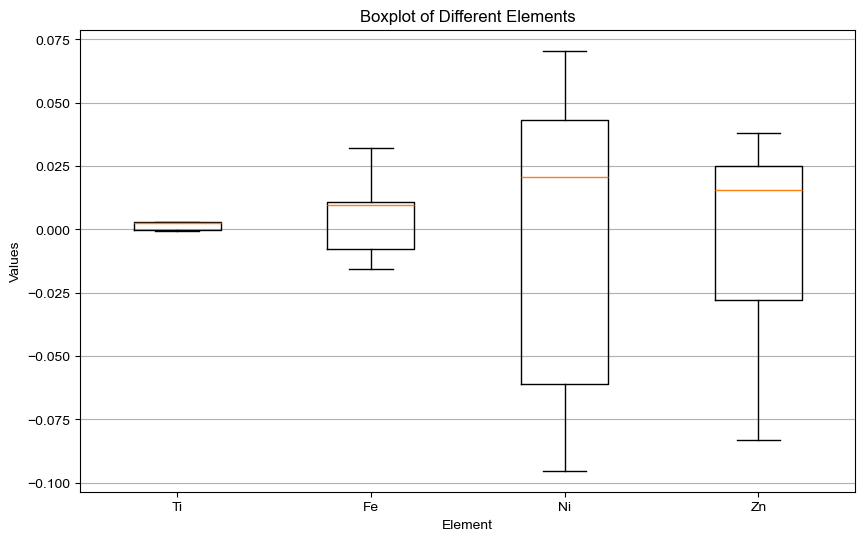

In [78]:
import matplotlib.pyplot as plt

# 假设这是你提取出的箱线图数据
data = {
    'Ti': [-0.000524, -0.0001696, 0.0026776, 0.0029469, 0.0031064],
    'Fe': [-0.01544, -0.0076496, 0.0098049, 0.010807, 0.032044],
    'Ni': [-0.0952785, -0.0610599, 0.0205557, 0.0432753, 0.0705555],
    'Zn': [-0.083104, -0.0279281, 0.0155926, 0.0252309, 0.0380253],
}
# data = {
#     'Cr': [-0.0118983, 0.0031487, 0.0061043, 0.014206, 0.0303703],
#     'Fe': [0.0428323, 0.0446595, 0.0561466, 0.0672636, 0.0893067],
#     'Cu': [-0.1185569, -0.1182976, -0.1115556, -0.089178, -0.074462],
#     'Zn': [0.0777682, 0.1049486, 0.1067877, 0.1452369, 0.2205985],
# }
# data = {
#     'Mn': [0.157027, 0.1678102, 0.1747804, 0.1965443, 0.2896004],
#     'Fe': [-0.0130597, -0.0111751, 0.029995, 0.0302134, 0.051506],
#     'Ni': [-0.2177193, -0.1912551, -0.1670604, -0.1237092, -0.0789356],
#     'Zn': [0.1069723, 0.1747244, 0.202238, 0.231437, 0.3249063],
# }
# 准备绘制箱线图的数据
plot_data = [values for values in data.values()]

# 绘制箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(plot_data, labels=data.keys())
plt.title('Boxplot of Different Elements')
plt.xlabel('Element')
plt.ylabel('Values')
plt.grid(axis='y')
plt.show()


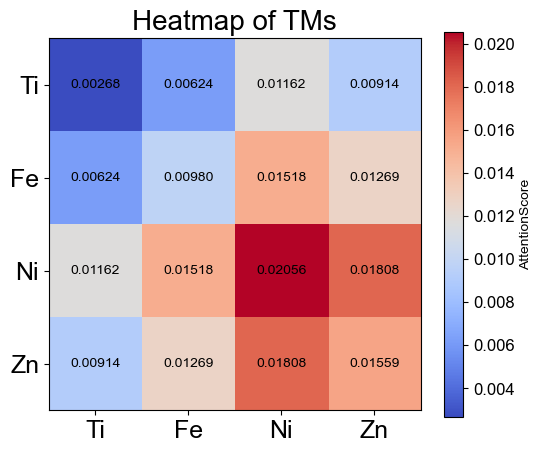

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# 提供的元素值
element_values = {
    'Ti': 0.00268,
    'Fe': 0.0098,
    'Ni': 0.02056,
    'Zn': 0.01559
}

# 构建元素对的平均值矩阵
elements = list(element_values.keys())
matrix = np.zeros((len(elements), len(elements)))

for i, elem1 in enumerate(elements):
    for j, elem2 in enumerate(elements):
        avg_value = (element_values[elem1] + element_values[elem2]) / 2
        matrix[i, j] = avg_value

# 设置字体
plt.rcParams['font.family'] = 'Arial'

# 绘制热图
plt.figure(figsize=(6, 5))
plt.imshow(matrix, cmap='coolwarm', interpolation='nearest')

# 添加元素标签，设置字号为18
plt.xticks(ticks=np.arange(len(elements)), labels=elements, fontsize=18)
plt.yticks(ticks=np.arange(len(elements)), labels=elements, fontsize=18)

# 添加颜色条，并修改标签
cbar = plt.colorbar(label='AttentionScore')
cbar.ax.tick_params(labelsize=12)  # 修改颜色条标签的字号

# 在热图上显示数值
for i in range(len(elements)):
    for j in range(len(elements)):
        plt.text(j, i, f'{matrix[i, j]:.5f}', ha='center', va='center', color='black')

# 修改标题
plt.title('Heatmap of TMs', fontsize=20)
plt.show()


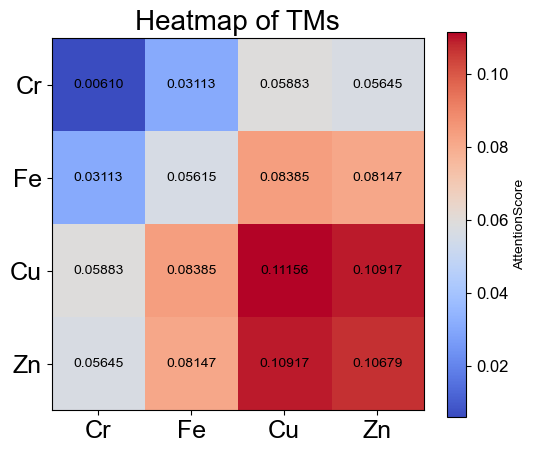

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# 提供的元素值
element_values = {
    'Cr': 0.0061043,
    'Fe': 0.0561466,
    'Cu': 0.1115556,
    'Zn': 0.1067877
}

# 构建元素对的平均值矩阵
elements = list(element_values.keys())
matrix = np.zeros((len(elements), len(elements)))

for i, elem1 in enumerate(elements):
    for j, elem2 in enumerate(elements):
        avg_value = (element_values[elem1] + element_values[elem2]) / 2
        matrix[i, j] = avg_value

# 设置字体
plt.rcParams['font.family'] = 'Arial'

# 绘制热图
plt.figure(figsize=(6, 5))
plt.imshow(matrix, cmap='coolwarm', interpolation='nearest')

# 添加元素标签，设置字号为18
plt.xticks(ticks=np.arange(len(elements)), labels=elements, fontsize=18)
plt.yticks(ticks=np.arange(len(elements)), labels=elements, fontsize=18)

# 添加颜色条，并修改标签
cbar = plt.colorbar(label='AttentionScore')
cbar.ax.tick_params(labelsize=12)  # 修改颜色条标签的字号

# 在热图上显示数值
for i in range(len(elements)):
    for j in range(len(elements)):
        plt.text(j, i, f'{matrix[i, j]:.5f}', ha='center', va='center', color='black')

# 修改标题
plt.title('Heatmap of TMs', fontsize=20)
plt.show()


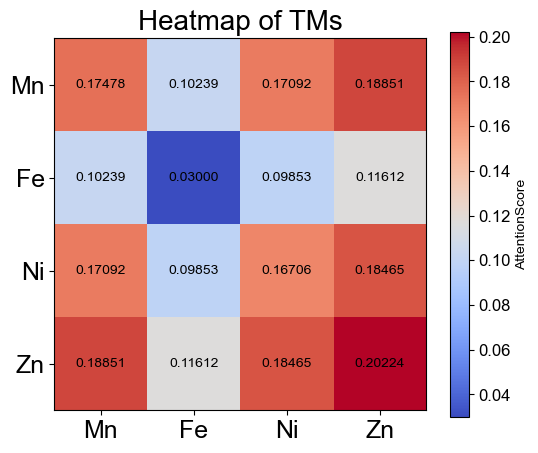

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# 提供的元素值
element_values = {
    'Mn': 0.1747804,
    'Fe': 0.029995,
    'Ni': 0.1670604,
    'Zn': 0.202238
}

# 构建元素对的平均值矩阵
elements = list(element_values.keys())
matrix = np.zeros((len(elements), len(elements)))

for i, elem1 in enumerate(elements):
    for j, elem2 in enumerate(elements):
        avg_value = (element_values[elem1] + element_values[elem2]) / 2
        matrix[i, j] = avg_value

# 设置字体
plt.rcParams['font.family'] = 'Arial'

# 绘制热图
plt.figure(figsize=(6, 5))
plt.imshow(matrix, cmap='coolwarm', interpolation='nearest')

# 添加元素标签，设置字号为18
plt.xticks(ticks=np.arange(len(elements)), labels=elements, fontsize=18)
plt.yticks(ticks=np.arange(len(elements)), labels=elements, fontsize=18)

# 添加颜色条，并修改标签
cbar = plt.colorbar(label='AttentionScore')
cbar.ax.tick_params(labelsize=12)  # 修改颜色条标签的字号

# 在热图上显示数值
for i in range(len(elements)):
    for j in range(len(elements)):
        plt.text(j, i, f'{matrix[i, j]:.5f}', ha='center', va='center', color='black')

# 修改标题
plt.title('Heatmap of TMs', fontsize=20)
plt.show()


Min 1: Key = Ti_Fe_Ni_Zn_9_1_14_7, Dop = -5.806311015625035, Median Min = 0.2871679567187977
Min 2: Key = Cr_Fe_Cu_Zn_11_6_7_3, Dop = -2.1398881640625342, Median Min = 0.28777639296881263
Min 3: Key = Mn_Fe_Ni_Zn_1_10_7_3, Dop = -0.11767625000003434, Median Min = 0.29458397750001675


<Figure size 640x480 with 0 Axes>

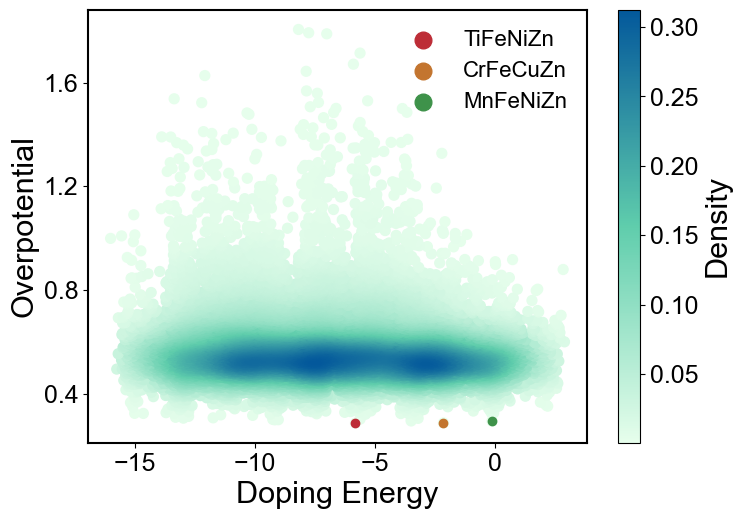

Min 1: Key = Ti_Fe_Ni_Zn_9_1_14_7, Dop = -5.806311015625035, Median Min = 0.2871679567187977
Min 2: Key = Cr_Fe_Cu_Zn_11_6_7_3, Dop = -2.1398881640625342, Median Min = 0.28777639296881263
Min 3: Key = Mn_Fe_Ni_Zn_1_10_7_3, Dop = -0.11767625000003434, Median Min = 0.29458397750001675


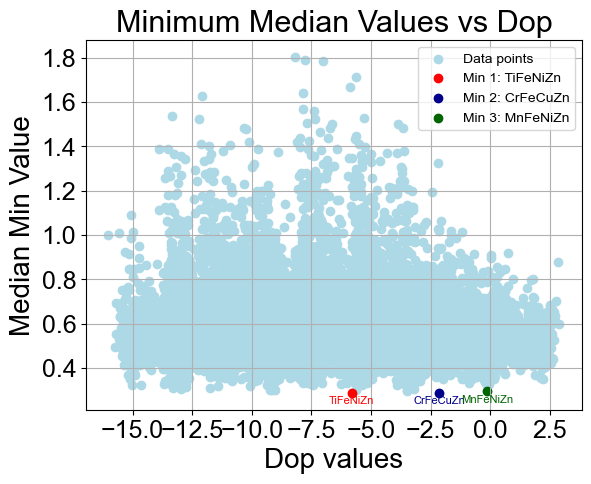

In [117]:
nums_list = ['0', ]
overpotentials = {}
yuanshu = 4
names = None
dop, basedE_dict = get_dop1(yuanshu)
if yuanshu == 4:
    names = "siyuan"
if yuanshu == 3:
    nmaes = "sanyuan"
if yuanshu == 2:
    names = "eryuan"
for ele in nums_list:
    for i in range(5): #3,4 --- 0
        checkpoints_name = f"{names}\\siyuanyuce_overpotential_{ele}_{str(i)}.txt"
        path = os.path.join(root_path, checkpoints_name)

        judge = (ele == nums_list[0] and i == 0)
        
        overpotentials = get_split_checkpoints_overpotential(path, overpotentials, judge, basedE_dict)

boxplot_results = calculate_column_boxplot_data(overpotentials)

min_values = compare_boxplot_statistics(boxplot_results)


from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

def plot_density_with_custom_colormap(x, y, keys_sorted):
    # 1. Set font to Arial for all elements
    rcParams['font.family'] = 'Arial'

    # 2. 计算点的密度
    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)

    # 3. 自定义 colormap，从黑到绿色的渐变
    custom_cmap = LinearSegmentedColormap.from_list(
        'custom_cmap', ['#E6FEEC', '#5FCDAC', '#03589B'] #, '#3B5598', '#372850', '#0F0509'
    )

    # 4. Set up the figure with specified size (converted from pixels to inches)
    plt.figure(figsize=(289.9 / 36, 202.41 / 36))

    # 5. 根据密度值绘制散点图，使用自定义的颜色映射（cmap）
    sc = plt.scatter(x, y, c=density, cmap=custom_cmap, s=50)

    # 6. Highlight the three densest points with specific colors
    highlight_colors = ['#BD2D37', '#C3752F', '#3E924A']
    for i in range(min(3, len(x))):
        key_processed = "".join(keys_sorted[i].split("_")[0:4])
        plt.scatter(x[i], y[i], color=highlight_colors[1], label=f"{key_processed}") ###, label=f"Min {i+1}: {key_processed}"
        # if i == 2:
        #     plt.text(x[i]+0.3, y[i] - 0.05, key_processed, color=highlight_colors[i], fontsize=9, ha='center', weight='bold')
        # elif i == 3:
        #     plt.text(x[i]-0.3, y[i] - 0.25, key_processed, color=highlight_colors[i], fontsize=9, ha='center', weight='bold')
        # else:
        #     plt.text(x[i], y[i] - 0.05, key_processed, color=highlight_colors[i], fontsize=9, ha='center', weight='bold')
        print(f"Min {i+1}: Key = {keys_sorted[i]}, Dop = {x[i]}, Median Min = {y[i]}")

    # 7. 添加颜色条
    cbar = plt.colorbar(sc, label='Density')
    cbar.ax.tick_params(labelsize=18)  # Colorbar ticks font size
    cbar.set_label('Density', fontsize=22)  # Colorbar label font size

    # 8. 设置标签和标尺
    # plt.title('Scatter plot with Density', fontsize=22)
    plt.xlabel('Doping Energy', fontsize=22)
    plt.ylabel('Overpotential', fontsize=22)

    plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))  # 5 ticks on x-axis
    plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))  # 5 ticks on y-axis

    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    for spine in plt.gca().spines.values():
        spine.set_linewidth(1.5)
    # ax = plt.gca()
    # ax.xaxis.set_ticks_position('in')
    # ax.yaxis.set_ticks_position('in')
    # # 9. 图例
    plt.legend(framealpha=0, fontsize=16, markerscale=2)

    # 10. 显示图表
    plt.show()

def plot_min_median_values(min_values: Dict[str, Dict[str, Dict[str, float]]], dop: Dict[str, float]):
    # Set font to Arial and figure background to white
    rcParams['font.family'] = 'Arial'
    plt.figure(facecolor='white')

    # Prepare x and y data
    x = []
    y = []
    keys = []

    # Extract dop values and corresponding median min_values
    for key, stats in min_values.items():
        if key in dop:
            x.append(dop[key])
            y.append(stats['median']['min_value'])  # Extract median min_value
            keys.append(key)

    # Convert to list of tuples (dop, median min_value, key)
    data = list(zip(x, y, keys))

    # Sort the data based on median min_value (y)
    data.sort(key=lambda item: item[1])

    # Separate x, y, and keys after sorting
    x_sorted = [item[0] for item in data]
    y_sorted = [item[1] for item in data]
    keys_sorted = [item[2] for item in data]

    # with open("H:\文章\预测\\xy.txt", 'w') as f:
    #     for x_val, y_val in zip(x_sorted, y_sorted):
    #         f.write(f"{x_val}\t{y_val}\n")
    plot_density_with_custom_colormap(x_sorted, y_sorted, keys_sorted)
    
    # Plot all data points in light blue
    plt.scatter(x_sorted, y_sorted, color='lightblue', label='Data points')

    # Colors for the three smallest points
    highlight_colors = ['red', 'darkblue', 'darkgreen']

    # Highlight the three smallest points in different colors and add text labels
    for i in range(min(3, len(x_sorted))):  # Ensure at least 3 points are available
        key_processed = "".join(keys_sorted[i].split("_")[0:4])
        plt.scatter(x_sorted[i], y_sorted[i], color=highlight_colors[i], label=f"Min {i+1}: {key_processed}")
        # key_processed = "".join(keys_sorted[i].split("_")[0:4])
        # Add text labels below the points with font size 8
        plt.text(x_sorted[i], y_sorted[i] - 0.05, key_processed, color=highlight_colors[i], fontsize=8, ha='center')
        print(f"Min {i+1}: Key = {keys_sorted[i]}, Dop = {x_sorted[i]}, Median Min = {y_sorted[i]}")

    # Labels and title
    plt.xlabel('Dop values', fontsize=20)
    plt.ylabel('Median Min Value', fontsize=20)
    plt.title('Minimum Median Values vs Dop', fontsize=22)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    # Add grid and legend
    plt.grid(True)
    plt.legend()

    # Show plot
    plt.show()



plot_min_median_values(min_values, dop)


<Figure size 640x480 with 0 Axes>

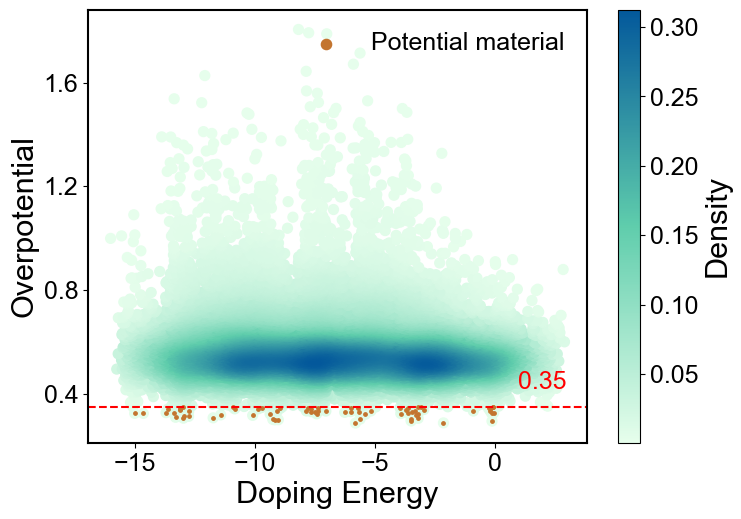

Min 1: Key = Ti_Fe_Ni_Zn_9_1_14_7, Dop = -5.806311015625035, Median Min = 0.2871679567187977
Min 2: Key = Cr_Fe_Cu_Zn_11_6_7_3, Dop = -2.1398881640625342, Median Min = 0.28777639296881263
Min 3: Key = Mn_Fe_Ni_Zn_1_10_7_3, Dop = -0.11767625000003434, Median Min = 0.29458397750001675


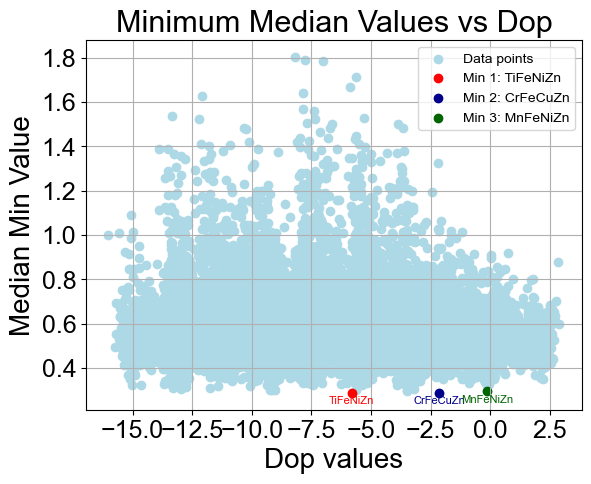

In [130]:
### 修改预测密度图，目标输出前100个最有益的材料
nums_list = ['0', ]
overpotentials = {}
yuanshu = 4
names = None
dop, basedE_dict = get_dop1(yuanshu)
if yuanshu == 4:
    names = "siyuan"
if yuanshu == 3:
    nmaes = "sanyuan"
if yuanshu == 2:
    names = "eryuan"
for ele in nums_list:
    for i in range(5): #3,4 --- 0
        checkpoints_name = f"{names}\\siyuanyuce_overpotential_{ele}_{str(i)}.txt"
        path = os.path.join(root_path, checkpoints_name)

        judge = (ele == nums_list[0] and i == 0)
        
        overpotentials = get_split_checkpoints_overpotential(path, overpotentials, judge, basedE_dict)

boxplot_results = calculate_column_boxplot_data(overpotentials)

min_values = compare_boxplot_statistics(boxplot_results)


from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

def plot_density_with_custom_colormap(x, y, keys_sorted):
    # 1. Set font to Arial for all elements
    rcParams['font.family'] = 'Arial'

    # 2. 计算点的密度
    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)

    # 3. 自定义 colormap，从黑到绿色的渐变
    custom_cmap = LinearSegmentedColormap.from_list(
        'custom_cmap', ['#E6FEEC', '#5FCDAC', '#03589B'] #, '#3B5598', '#372850', '#0F0509'
    )

    # 4. Set up the figure with specified size (converted from pixels to inches)
    plt.figure(figsize=(289.9 / 36, 202.41 / 36))

    # 5. 根据密度值绘制散点图，使用自定义的颜色映射（cmap）
    sc = plt.scatter(x, y, c=density, cmap=custom_cmap, s=50)

    # 6. Highlight the three densest points with specific colors
    highlight_colors = ['#BD2D37', '#C3752F', '#3E924A']
    label_added = False 
    for i in range(min(70, len(x))):
        if y[i] > 0.5:
            break
        if not label_added:
            plt.scatter(x[i], y[i], color=highlight_colors[1], s=6, label="Potential material")
            label_added = True  # 标志已添加标签
        else:
            plt.scatter(x[i], y[i], color=highlight_colors[1], s=6)
        key_processed = "".join(keys_sorted[i].split("_")[0:4])
        # plt.scatter(x[i], y[i], color=highlight_colors[1], label="Potential material") ###, label=f"{key_processed}", label=f"Min {i+1}: {key_processed}"
        # if i == 2:
        #     plt.text(x[i]+0.3, y[i] - 0.05, key_processed, color=highlight_colors[i], fontsize=9, ha='center', weight='bold')
        # elif i == 3:
        #     plt.text(x[i]-0.3, y[i] - 0.25, key_processed, color=highlight_colors[i], fontsize=9, ha='center', weight='bold')
        # else:
        #     plt.text(x[i], y[i] - 0.05, key_processed, color=highlight_colors[i], fontsize=9, ha='center', weight='bold')
        # print(f"Min {i+1}: Key = {keys_sorted[i]}, Dop = {x[i]}, Median Min = {y[i]}")

    # 7. 添加颜色条
    cbar = plt.colorbar(sc, label='Density')
    cbar.ax.tick_params(labelsize=18)  # Colorbar ticks font size
    cbar.set_label('Density', fontsize=22)  # Colorbar label font size

    # 8. 设置标签和标尺
    # plt.title('Scatter plot with Density', fontsize=22)
    plt.xlabel('Doping Energy', fontsize=22)
    plt.ylabel('Overpotential', fontsize=22)

    plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))  # 5 ticks on x-axis
    plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))  # 5 ticks on y-axis

    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    for spine in plt.gca().spines.values():
        spine.set_linewidth(1.5)
    # ax = plt.gca()
    # ax.xaxis.set_ticks_position('in')
    # ax.yaxis.set_ticks_position('in')
    # # 9. 图例
    plt.axhline(y=0.35, color='red', linestyle='--', linewidth=1.5)
    plt.text(3, 0.4, '0.35', fontsize=18, fontfamily='Arial', color='red', verticalalignment='bottom', horizontalalignment='right')

    plt.legend(framealpha=0, fontsize=18, markerscale=3)

    # 10. 显示图表
    plt.show()

def plot_min_median_values(min_values: Dict[str, Dict[str, Dict[str, float]]], dop: Dict[str, float]):
    # Set font to Arial and figure background to white
    rcParams['font.family'] = 'Arial'
    plt.figure(facecolor='white')

    # Prepare x and y data
    x = []
    y = []
    keys = []

    # Extract dop values and corresponding median min_values
    for key, stats in min_values.items():
        if key in dop:
            x.append(dop[key])
            y.append(stats['median']['min_value'])  # Extract median min_value
            keys.append(key)

    # Convert to list of tuples (dop, median min_value, key)
    data = list(zip(x, y, keys))

    # Sort the data based on median min_value (y)
    data.sort(key=lambda item: item[1])

    # Separate x, y, and keys after sorting
    x_sorted = [item[0] for item in data]
    y_sorted = [item[1] for item in data]
    keys_sorted = [item[2] for item in data]

    # with open("H:\文章\预测\\xy.txt", 'w') as f:
    #     for x_val, y_val in zip(x_sorted, y_sorted):
    #         f.write(f"{x_val}\t{y_val}\n")
    plot_density_with_custom_colormap(x_sorted, y_sorted, keys_sorted)
    
    # Plot all data points in light blue
    plt.scatter(x_sorted, y_sorted, color='lightblue', label='Data points')

    # Colors for the three smallest points
    highlight_colors = ['red', 'darkblue', 'darkgreen']

    # Highlight the three smallest points in different colors and add text labels
    for i in range(min(3, len(x_sorted))):  # Ensure at least 3 points are available
        key_processed = "".join(keys_sorted[i].split("_")[0:4])
        plt.scatter(x_sorted[i], y_sorted[i], color=highlight_colors[i], label=f"Min {i+1}: {key_processed}")
        # key_processed = "".join(keys_sorted[i].split("_")[0:4])
        # Add text labels below the points with font size 8
        plt.text(x_sorted[i], y_sorted[i] - 0.05, key_processed, color=highlight_colors[i], fontsize=8, ha='center')
        print(f"Min {i+1}: Key = {keys_sorted[i]}, Dop = {x_sorted[i]}, Median Min = {y_sorted[i]}")

    # Labels and title
    plt.xlabel('Dop values', fontsize=20)
    plt.ylabel('Median Min Value', fontsize=20)
    plt.title('Minimum Median Values vs Dop', fontsize=22)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    # Add grid and legend
    plt.grid(True)
    plt.legend()

    # Show plot
    plt.show()



plot_min_median_values(min_values, dop)


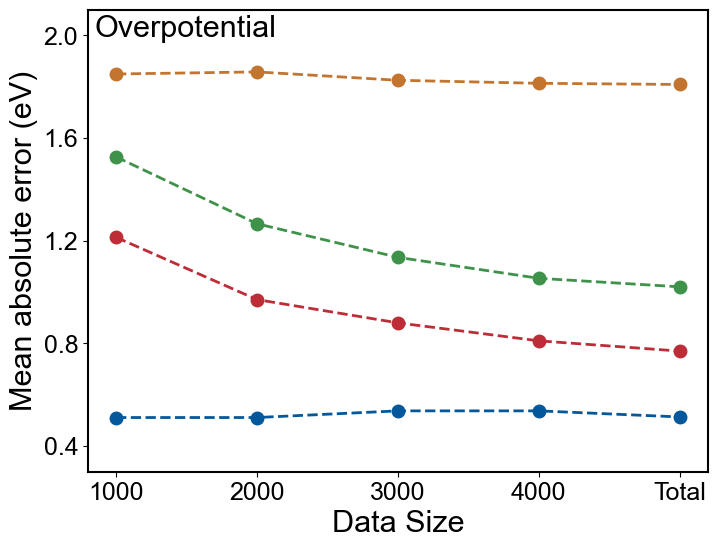

In [230]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator

# 设置全局字体为 Arial
rcParams['font.family'] = 'Arial'

# 示例数据
x = [1000, 2000, 3000, 4000, "Total"]
y1 = [1.2133, 0.9707, 0.88, 0.81, 0.77]  # 第一条线数据
y2 = [1.849547476, 1.857730569458, 1.82511362040201, 1.81331493988037, 1.80873724639709]  # 第二条线数据
y3 = [1.526725, 1.26622, 1.13526, 1.05356, 1.0204]  # 第三条线数据
y4 = [0.511141717, 0.511141717, 0.53710103, 0.53710103, 0.513376176]  # 第四条线数据

# 设置图像尺寸
plt.figure(figsize=(8, 6))
size_dot = 9
# 绘制四条点线图，分别使用指定的颜色，点大小为12，线宽为2
plt.plot(x, y1, marker='o', markersize=size_dot, linestyle='--', linewidth=2, color='#BD2D37', label=None)
plt.plot(x, y2, marker='o', markersize=size_dot, linestyle='--', linewidth=2, color='#C3752F', label=None)
plt.plot(x, y3, marker='o', markersize=size_dot, linestyle='--', linewidth=2, color='#3E924A', label=None)
plt.plot(x, y4, marker='o', markersize=size_dot, linestyle='--', linewidth=2, color='#03589B', label=None)

# 设置标题和标签
# plt.title("Four Lines with Custom Colors, Marker Size and Line Width", fontsize=14)
plt.xlabel('Data Size', fontsize=22)
plt.ylabel('Mean absolute error (eV)', fontsize=22)

plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))  # 5 ticks on x-axis
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))  # 5 ticks on y-axis
plt.text(0.01, 0.99, 'Overpotential', fontsize=22, ha='left', va='top', transform=plt.gca().transAxes)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylim(0.3, 2.1)
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.5)
# 显示图例
# plt.legend()

# 显示图形
plt.show()


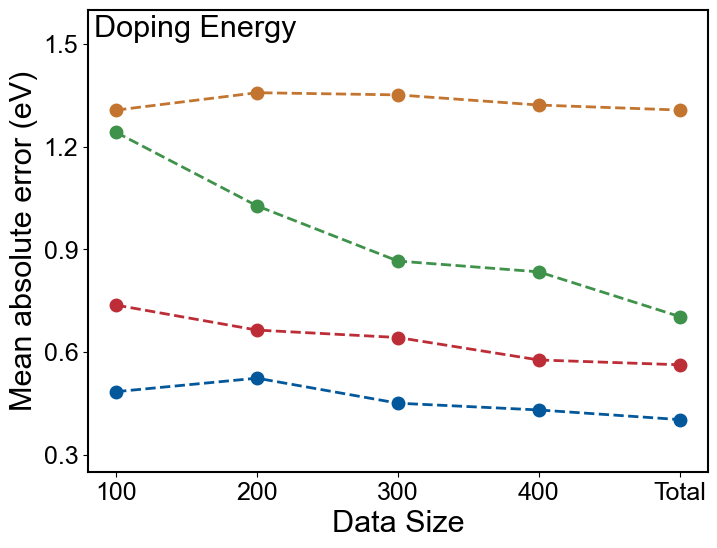

In [229]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator

# 设置全局字体为 Arial
rcParams['font.family'] = 'Arial'

# 示例数据
x = [100, 200, 300, 400, "Total"]
y1 = [0.7369, 0.6639, 0.6422, 0.5766, 0.5625]  # 第一条线数据
y2 = [1.30665, 1.35752, 1.35114, 1.32144, 1.30685]  # 第二条线数据
y3 = [1.24174, 1.0269, 0.86564, 0.83406, 0.70336]  # 第三条线数据
y4 = [0.48393, 0.52338, 0.45028, 0.43049, 0.40234]  # 第四条线数据

# 设置图像尺寸
plt.figure(figsize=(8, 6))
size_dot = 9
# 绘制四条点线图，分别使用指定的颜色，点大小为12，线宽为2
plt.plot(x, y1, marker='o', markersize=size_dot, linestyle='--', linewidth=2, color='#BD2D37', label=None)
plt.plot(x, y2, marker='o', markersize=size_dot, linestyle='--', linewidth=2, color='#C3752F', label=None)
plt.plot(x, y3, marker='o', markersize=size_dot, linestyle='--', linewidth=2, color='#3E924A', label=None)
plt.plot(x, y4, marker='o', markersize=size_dot, linestyle='--', linewidth=2, color='#03589B', label=None)

# 设置标题和标签
# plt.title("Four Lines with Custom Colors, Marker Size and Line Width", fontsize=14)
plt.xlabel('Data Size', fontsize=22)
plt.ylabel('Mean absolute error (eV)', fontsize=22)

plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))  # 5 ticks on x-axis
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))  # 5 ticks on y-axis
plt.text(0.01, 0.99, 'Doping Energy', fontsize=22, ha='left', va='top', transform=plt.gca().transAxes)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylim(0.25, 1.6)
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.5)
# 显示图例
# plt.legend()

# 显示图形
plt.show()


In [ ]:
def main():

    global root_path
    nums_list = ['0', ]
    overpotentials = {}
    yuanshu = 4
    names = None
    dop, basedE_dict = get_dop1(yuanshu)
    if yuanshu == 4:
        names = "siyuan"
    if yuanshu == 3:
        nmaes = "sanyuan"
    if yuanshu == 2:
        names = "eryuan"
    for ele in nums_list:
        for i in range(5): #3,4 --- 0
            checkpoints_name = f"{names}\\siyuanyuce_overpotential_{ele}_{str(i)}.txt"
            path = os.path.join(root_path, checkpoints_name)

            judge = (ele == nums_list[0] and i == 0)
            
            overpotentials = get_split_checkpoints_overpotential(path, overpotentials, judge, basedE_dict)

    boxplot_results = calculate_column_boxplot_data(overpotentials)
    # with open('D:\pre_train\checkpoint\equiformerV2\\train_record\overpotential-total\\output.txt', 'a') as file:
    #     json.dump(overpotentials, file)
    #     json.dump(boxplot_results, file)
    min_values = compare_boxplot_statistics(boxplot_results)
    find_key_of_global_min(min_values)
    for x in ["Zn", "Ni", "Fe", "Mn", "Cr", "Ti", "V", "Cu"]:
        judge_Zn_O_importance(min_values, x, yuanshu)
    # judge_Zn_O_importance(min_values)


if __name__ == "__main__":
    # 在这里调用主函数
    main()

Five smallest min_values and their corresponding keys:
Key: Ti_V_Fe_Ni_12_1_5_9, Min Value: 0.28312285568755324, the index: 13
Key: V_Mn_Fe_Ni_9_7_12_13, Min Value: 0.3069609416250475, the index: 0
Key: Ti_V_Mn_Fe_12_10_6_2, Min Value: 0.32951338200005365, the index: 8
Key: Ti_V_Mn_Ni_10_7_1_5, Min Value: 0.3335116176562945, the index: 13
Key: Ti_Cr_Mn_Fe_5_6_3_15, Min Value: 0.3373565491562851, the index: 13
Five smallest median_values and their corresponding keys:
Key: Ti_Fe_Ni_Zn_9_1_14_7, Median Value: 0.2871679567187977, the index: 8
Key: Cr_Fe_Cu_Zn_11_6_7_3, Median Value: 0.28777639296881263, the index: 8
Key: Mn_Fe_Ni_Zn_1_10_7_3, Median Value: 0.29458397750001675, the index: 8
Key: V_Mn_Fe_Ni_5_3_2_4, Median Value: 0.29516164687506263, the index: 4
Key: Ti_V_Fe_Ni_12_2_1_14, Median Value: 0.2995580934375477, the index: 11
Mean: Ti_V_Fe_Ni_12_1_5_9 with value 0.28312285568755324 at index 13
Median: Ti_Fe_Ni_Zn_9_1_14_7 with value 0.2871679567187977 at index 8
Cr_Fe_Cu_Zn_11_6_7

位点（X）: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
过电位（Y）: [0.4   0.584 0.514 0.472 0.33  0.33  0.299 0.557 0.472 0.507 0.287 0.59
 0.546 0.348 0.338 0.339]


C:\Users\PS\AppData\Local\Temp\ipykernel_20260\2124651247.py:41: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from current font.
  plt.tight_layout()
C:\Users\PS\AppData\Local\Temp\ipykernel_20260\2124651247.py:41: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from current font.
  plt.tight_layout()
C:\Users\PS\AppData\Local\Temp\ipykernel_20260\2124651247.py:41: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from current font.
  plt.tight_layout()
C:\Users\PS\AppData\Local\Temp\ipykernel_20260\2124651247.py:41: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from current font.
  plt.tight_layout()
C:\Users\PS\AppData\Local\Temp\ipykernel_20260\2124651247.py:41: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from current font.
  plt.tight_layout()
C:\Users\PS\AppData\Local\Temp\ipykernel_20260\2124651247.py:41: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from current f

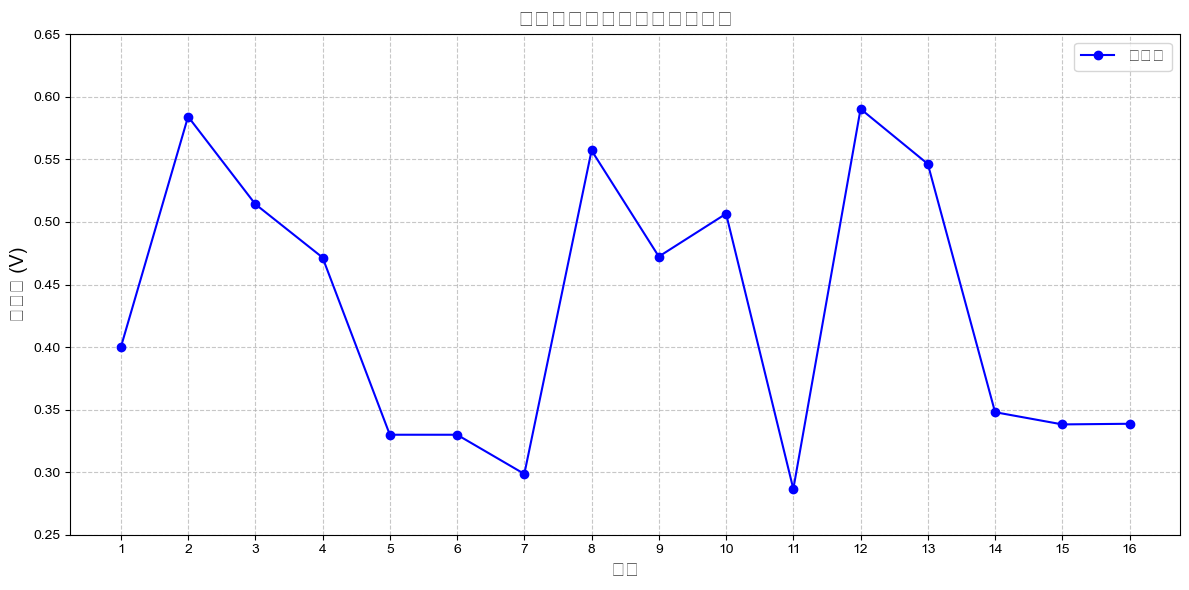

In [120]:
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子以确保结果可重复
np.random.seed(42)

# 生成位点数据（1到16的整数）
positions = np.arange(1, 17)

# 生成随机过电位数据，范围在0.28到0.6之间
overpotentials = np.random.uniform(0.28, 0.6, size=positions.size)

# 打印生成的数据（可选）
print("位点（X）:", positions)
print("过电位（Y）:", np.round(overpotentials, 3))

# 创建图表
plt.figure(figsize=(12, 6))

# 绘制电线图（使用直线连接各个独立点）
plt.plot(positions, overpotentials, marker='o', linestyle='-', color='blue', label='过电位')

# 添加标题和轴标签
plt.title('不同位点的过电位分布电线图', fontsize=16)
plt.xlabel('位点', fontsize=14)
plt.ylabel('过电位 (V)', fontsize=14)

# 设置X轴为整数刻度
plt.xticks(positions)

# 设置Y轴范围
plt.ylim(0.25, 0.65)

# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 添加图例
plt.legend(fontsize=12)

# 显示图表
plt.tight_layout()
plt.show()


In [52]:

nums_list = ['0', ]
overpotentials = {}
yuanshu = 2
names = "sanyuan"
dop, basedE_dict = get_dop(yuanshu)
if yuanshu == 4:
    names = "siyuan"
if yuanshu == 3:
    nmaes = "sanyuan"
if yuanshu == 2:
    names = "eryuan"
for ele in nums_list:
    for i in range(5): #3,4 --- 0
        checkpoints_name = f"{names}\\siyuanyuce_overpotential_{ele}_{str(i)}.txt"
        path = os.path.join(root_path, checkpoints_name)

        judge = (ele == nums_list[0] and i == 0)
        overpotentials = get_split_checkpoints_overpotential(path, overpotentials, judge, basedE_dict)

boxplot_results = calculate_column_boxplot_data(overpotentials)
# with open('D:\pre_train\checkpoint\equiformerV2\\train_record\overpotential-total\\output.txt', 'a') as file:
#     json.dump(overpotentials, file)
#     json.dump(boxplot_results, file)
min_values = compare_boxplot_statistics(boxplot_results)
find_key_of_global_min(min_values)
for x in ["Zn", "Ni", "Fe", "Mn", "Cr", "Ti", "V", "Cu"]:
    judge_Zn_O_importance(min_values, x, yuanshu)
# judge_Zn_O_importance(min_values)



Min: Ni_Zn_6_10 with value 0.02471678484379769 at index 4
Mean: Mn_Cu_5_13 with value 0.2907042879375349 at index 8
Median: V_Ni_15_12 with value 0.2496313356250477 at index 4
0.9267857142857143 0.9333333333333333 0.8773809523809524
0.2648809523809524 0.09345238095238095 0.0744047619047619
0.20773809523809525 0.16071428571428573 0.09821428571428571
0.2714285714285714 0.15892857142857142 0.10416666666666667
0.30238095238095236 0.24345238095238095 0.16130952380952382
0.10178571428571428 0.07857142857142857 0.07083333333333333
0.09166666666666666 0.06369047619047619 0.06488095238095239
0.5523809523809524 0.5910714285714286 0.4369047619047619


In [53]:
nums_list = ['0', ]
overpotentials = {}
yuanshu = 3
names = "sanyuan"
dop, basedE_dict = get_dop(yuanshu)
if yuanshu == 4:
    names = "siyuan"
if yuanshu == 3:
    nmaes = "sanyuan"
if yuanshu == 2:
    names = "eryuan"
for ele in nums_list:
    for i in range(1): #3,4 --- 0
        checkpoints_name = f"{names}\\siyuanyuce_overpotential_{ele}_{str(i)}.txt"
        path = os.path.join(root_path, checkpoints_name)

        judge = (ele == nums_list[0] and i == 0)
        overpotentials = get_split_checkpoints_overpotential(path, overpotentials, judge, basedE_dict)

boxplot_results = calculate_column_boxplot_data(overpotentials)
# with open('D:\pre_train\checkpoint\equiformerV2\\train_record\overpotential-total\\output.txt', 'a') as file:
#     json.dump(overpotentials, file)
#     json.dump(boxplot_results, file)
min_values = compare_boxplot_statistics(boxplot_results)
find_key_of_global_min(min_values)
for x in ["Zn", "Ni", "Fe", "Mn", "Cr", "Ti", "V", "Cu"]:
    judge_Zn_O_importance(min_values, x, yuanshu)
# judge_Zn_O_importance(min_values)

Min: Ni_Cu_Zn_1_2_11 with value 0.01037352312504769 at index 4
Mean: Ni_Cu_Zn_1_2_11 with value 0.01037352312504769 at index 4
Median: Ni_Cu_Zn_1_2_11 with value 0.01037352312504769 at index 4
0.9304126984126984 0.9304126984126984 0.9304126984126984
0.37314285714285716 0.37314285714285716 0.37314285714285716
0.3587936507936508 0.3587936507936508 0.3587936507936508
0.1838095238095238 0.1838095238095238 0.1838095238095238
0.35219047619047616 0.35219047619047616 0.35219047619047616
0.13111111111111112 0.13111111111111112 0.13111111111111112
0.06666666666666667 0.06666666666666667 0.06666666666666667
0.3958730158730159 0.3958730158730159 0.3958730158730159


In [85]:
dop, basedE_dict = get_dop1(4)
name_based = "Ti_Fe_Ni_Zn_9_1_14_7"
crmnfezn_0000 = basedE_dict["Ti_Fe_Ni_Zn_9_1_14_7"]
O_OH_OOH_index = 8

def get_overpotential_step(based_energy: float, O_energy: List[float], OH_energy: List[float], OOH_energy: List[float], judge: bool) -> List[float]:
    a1, a2, a3 = 0.352, 0.043, 0.346
    a4, a5, a6 = -9.86717672, -14.21525147, -6.82166311
    delter_1 = []
    delter_2 = []
    delter_3 = []
    delter_4 = []
    fine_based_energy = based_energy + 2 * a5

    for i in range(min(len(O_energy), len(OH_energy), len(OOH_energy))):
        delter_1.append(OH_energy[i] + a1 + 0.5 * a6 - based_energy - a5)
        delter_2.append(O_energy[i] + a2 + 0.5 * a6 - OH_energy[i] - a1)
        delter_3.append(OOH_energy[i] + a3 + 0.5 * a6 - O_energy[i] - a2 - a5)
        delter_4.append(based_energy + a4 + 0.5 * a6 - a3 - OOH_energy[i])

    return [[delter_1[i], delter_1[i] + delter_2[i], delter_1[i] + delter_2[i] + delter_3[i], delter_1[i] + delter_2[i] + delter_3[i] + delter_4[i]] for i in range(len(delter_1))]

from pathlib import Path
directory_path = "D:\pre_train\checkpoint\equiformerV2\\train_record\预测\\siyuan"
# 表达式：遍历目录下所有文件并读取内容
filenames = [file_path.name for file_path in Path(directory_path).iterdir() if file_path.is_file() and "doping" not in file_path.name]
for filesss in filenames:
    
    with open(os.path.join(directory_path, filesss), 'r') as f:
        data = f.readlines()
    based_index = 0
    for i in range(len(data)):
        if name_based in data[i]:
            based_index = i
            break
    
    try:
        base_2 = data[based_index].split()[0]
        O_es = data[O_OH_OOH_index*3 + 1 + based_index].split()[0]
        OH_es = data[O_OH_OOH_index*3 + 2 + based_index].split()[0]
        OOH_es = data[O_OH_OOH_index*3 + 3 + based_index].split()[0]
        print(crmnfezn_0000, base_2, O_es, OH_es, OOH_es)
        print(filesss, get_overpotential(float(crmnfezn_0000), [float(O_es)], [float(OH_es)], [float(OOH_es)], True), get_overpotential(float(base_2), [float(O_es)], [float(OH_es)], [float(OOH_es)], True))
        print(filesss, get_overpotential_step(float(crmnfezn_0000), [float(O_es)], [float(OH_es)], [float(OOH_es)], True), get_overpotential_step(float(base_2), [float(O_es)], [float(OH_es)], [float(OOH_es)], True))
    except:
        continue

    # print(base_2)

-645.092041015625 -644.8677978515625 -649.9921875 -654.9445190429688 -659.8429565429688
siyuanyuce_overpotential_0_0.txt [0.07394188765626675] [0.12115041640631263]
siyuanyuce_overpotential_0_0.txt [[1.3039418876562667, 2.5364418756250644, 3.79309274765636, 4.920000000000172]] [[1.0796987235937667, 2.3121987115625644, 3.56884958359386, 4.920000000000172]]
-645.092041015625 -645.600830078125 -649.7717895507812 -655.3787231445312 -660.2817993164062
siyuanyuce_overpotential_0_1.txt [0.6571020387500477] [0.6571020387500477]
siyuanyuce_overpotential_0_1.txt [[0.8697377860937667, 2.7568398248438144, 3.35424997421886, 4.920000000000172]] [[1.3785268485937667, 3.2656288873438144, 3.86303903671886, 4.920000000000172]]
-645.092041015625 -645.0702514648438 -649.6011962890625 -655.0552978515625 -660.438720703125
siyuanyuce_overpotential_0_2.txt [0.5042700075000477] [0.5144609632813126]
siyuanyuce_overpotential_0_2.txt [[1.1931630790625167, 2.9274330865625644, 3.19732858750011, 4.920000000000172]] 

In [108]:
dop, basedE_dict = get_dop1(4)
name_based = "Cr_Mn_Fe_Zn_0_0_0_0"
crmnfezn_0000 = basedE_dict[name_based]
O_OH_OOH_index = 9

def get_overpotential_step(based_energy: float, O_energy: List[float], OH_energy: List[float], OOH_energy: List[float], judge: bool) -> List[float]:
    a1, a2, a3 = 0.352, 0.043, 0.346
    a4, a5, a6 = -9.86717672, -14.21525147, -6.82166311
    delter_1 = []
    delter_2 = []
    delter_3 = []
    delter_4 = []
    fine_based_energy = based_energy + 2 * a5

    for i in range(min(len(O_energy), len(OH_energy), len(OOH_energy))):
        delter_1.append(OH_energy[i] + a1 + 0.5 * a6 - based_energy - a5)
        delter_2.append(O_energy[i] + a2 + 0.5 * a6 - OH_energy[i] - a1)
        delter_3.append(OOH_energy[i] + a3 + 0.5 * a6 - O_energy[i] - a2 - a5)
        delter_4.append(based_energy + a4 + 0.5 * a6 - a3 - OOH_energy[i])

    return [[delter_1[i], delter_1[i] + delter_2[i], delter_1[i] + delter_2[i] + delter_3[i], delter_1[i] + delter_2[i] + delter_3[i] + delter_4[i]] for i in range(len(delter_1))]

from pathlib import Path
directory_path = "D:\pre_train\checkpoint\equiformerV2\\train_record\预测\\siyuan"
# 表达式：遍历目录下所有文件并读取内容
filenames = [file_path.name for file_path in Path(directory_path).iterdir() if file_path.is_file() and "doping" not in file_path.name]
for filesss in filenames:
    
    with open(os.path.join(directory_path, filesss), 'r') as f:
        data = f.readlines()
    based_index = 0
    for i in range(len(data)):
        if name_based in data[i]:
            based_index = i
            break
    
    try:
        base_2 = data[based_index].split()[0]
        O_es = data[O_OH_OOH_index*3 + 1 + based_index].split()[0]
        OH_es = data[O_OH_OOH_index*3 + 2 + based_index].split()[0]
        OOH_es = data[O_OH_OOH_index*3 + 3 + based_index].split()[0]
        print(crmnfezn_0000, base_2, O_es, OH_es, OOH_es)
        print(filesss, get_overpotential(float(crmnfezn_0000), [float(O_es)], [float(OH_es)], [float(OOH_es)], True), get_overpotential(float(base_2), [float(O_es)], [float(OH_es)], [float(OOH_es)], True))
        print(filesss, get_overpotential_step(float(crmnfezn_0000), [float(O_es)], [float(OH_es)], [float(OOH_es)], True), get_overpotential_step(float(base_2), [float(O_es)], [float(OH_es)], [float(OOH_es)], True))
    except:
        continue

    # print(base_2)

-648.0348510742188 -648.9058227539062 -653.3148803710938 -658.60986328125 -663.2247314453125
siyuanyuce_overpotential_0_0.txt [0.3451513551562977] [0.3451513551562977]
siyuanyuce_overpotential_0_0.txt [[0.5814077079687667, 2.1565590631250644, 3.35412790390636, 4.920000000000172]] [[1.4523793876562667, 3.0275307428125644, 4.22509958359386, 4.920000000000172]]
-648.0348510742188 -648.8211669921875 -652.870361328125 -658.6348266601562 -663.55224609375
siyuanyuce_overpotential_0_1.txt [0.8146337770312977] [0.8146337770312977]
siyuanyuce_overpotential_0_1.txt [[0.5564443290625167, 2.6010781060938144, 3.02661325546886, 4.920000000000172]] [[1.3427602470312667, 3.3873940240625644, 3.81292917343761, 4.920000000000172]]
-648.0348510742188 -648.6239624023438 -652.8757934570312 -658.418701171875 -663.8026733398438
siyuanyuce_overpotential_0_2.txt [0.9138139906250626] [0.5930761598437977]
siyuanyuce_overpotential_0_2.txt [[0.7725698173437667, 2.5956459771875644, 2.77618600937511, 4.920000000000172

In [95]:
dop, basedE_dict = get_dop1(4)
name_based = "Cr_Fe_Cu_Zn_11_6_7_3"
crmnfezn_0000 = basedE_dict["Cr_Fe_Cu_Zn_11_6_7_3"]
O_OH_OOH_index = 8

def get_overpotential_step(based_energy: float, O_energy: List[float], OH_energy: List[float], OOH_energy: List[float], judge: bool) -> List[float]:
    a1, a2, a3 = 0.352, 0.043, 0.346
    a4, a5, a6 = -9.86717672, -14.21525147, -6.82166311
    delter_1 = []
    delter_2 = []
    delter_3 = []
    delter_4 = []
    fine_based_energy = based_energy + 2 * a5

    for i in range(min(len(O_energy), len(OH_energy), len(OOH_energy))):
        delter_1.append(OH_energy[i] + a1 + 0.5 * a6 - based_energy - a5)
        delter_2.append(O_energy[i] + a2 + 0.5 * a6 - OH_energy[i] - a1)
        delter_3.append(OOH_energy[i] + a3 + 0.5 * a6 - O_energy[i] - a2 - a5)
        delter_4.append(based_energy + a4 + 0.5 * a6 - a3 - OOH_energy[i])

    return [[delter_1[i], delter_1[i] + delter_2[i], delter_1[i] + delter_2[i] + delter_3[i], delter_1[i] + delter_2[i] + delter_3[i] + delter_4[i]] for i in range(len(delter_1))]

from pathlib import Path
directory_path = "D:\pre_train\checkpoint\equiformerV2\\train_record\预测\\siyuan"
# 表达式：遍历目录下所有文件并读取内容
filenames = [file_path.name for file_path in Path(directory_path).iterdir() if file_path.is_file() and "doping" not in file_path.name]
for filesss in filenames:
    
    with open(os.path.join(directory_path, filesss), 'r') as f:
        data = f.readlines()
    based_index = 0
    for i in range(len(data)):
        if name_based in data[i]:
            based_index = i
            break
    
    try:
        base_2 = data[based_index].split()[0]
        O_es = data[O_OH_OOH_index*3 + 1 + based_index].split()[0]
        OH_es = data[O_OH_OOH_index*3 + 2 + based_index].split()[0]
        OOH_es = data[O_OH_OOH_index*3 + 3 + based_index].split()[0]
        print(crmnfezn_0000, base_2, O_es, OH_es, OOH_es)
        print(filesss, get_overpotential(float(crmnfezn_0000), [float(O_es)], [float(OH_es)], [float(OOH_es)], True), get_overpotential(float(base_2), [float(O_es)], [float(OH_es)], [float(OOH_es)], True))
        print(filesss, get_overpotential_step(float(crmnfezn_0000), [float(O_es)], [float(OH_es)], [float(OOH_es)], True), get_overpotential_step(float(base_2), [float(O_es)], [float(OH_es)], [float(OOH_es)], True))
    except:
        continue

    # print(base_2)

-641.4586181640625 -641.283203125 -646.5651245117188 -651.5586547851562 -656.2457275390625
siyuanyuce_overpotential_0_0.txt [0.19681688765629568] [0.19681688765629568]
siyuanyuce_overpotential_0_0.txt [[1.0563832939062667, 2.3300820123438144, 3.75689890000011, 4.920000000000172]] [[0.8809682548437667, 2.1546669732813144, 3.58148386093761, 4.920000000000172]]
-641.4586181640625 -641.9913940429688 -646.3478393554688 -651.6996459960938 -656.59423828125
siyuanyuce_overpotential_0_1.txt [0.4019750856250477] [0.4019750856250477]
siyuanyuce_overpotential_0_1.txt [[0.9153920829687667, 2.5473671685938144, 3.40838815781261, 4.920000000000172]] [[1.4481679618750167, 3.0801430475000644, 3.94116403671886, 4.920000000000172]]
-641.4586181640625 -641.4178466796875 -646.2123413085938 -651.6011352539062 -656.892578125
siyuanyuce_overpotential_0_2.txt [0.5799516859375626] [0.6207231703125626]
siyuanyuce_overpotential_0_2.txt [[1.0139028251562667, 2.6828652154688144, 3.11004831406261, 4.920000000000172]]

In [104]:
dop, basedE_dict = get_dop1(4)

name_based = "Mn_Fe_Ni_Zn_1_10_7_3"
crmnfezn_0000 = basedE_dict["Mn_Fe_Ni_Zn_1_10_7_3"]
O_OH_OOH_index = 8

def get_overpotential_step(based_energy: float, O_energy: List[float], OH_energy: List[float], OOH_energy: List[float], judge: bool) -> List[float]:
    a1, a2, a3 = 0.352, 0.043, 0.346
    a4, a5, a6 = -9.86717672, -14.21525147, -6.82166311
    delter_1 = []
    delter_2 = []
    delter_3 = []
    delter_4 = []
    fine_based_energy = based_energy + 2 * a5

    for i in range(min(len(O_energy), len(OH_energy), len(OOH_energy))):
        delter_1.append(OH_energy[i] + a1 + 0.5 * a6 - based_energy - a5)
        delter_2.append(O_energy[i] + a2 + 0.5 * a6 - OH_energy[i] - a1)
        delter_3.append(OOH_energy[i] + a3 + 0.5 * a6 - O_energy[i] - a2 - a5)
        delter_4.append(based_energy + a4 + 0.5 * a6 - a3 - OOH_energy[i])

    return [[delter_1[i], delter_1[i] + delter_2[i], delter_1[i] + delter_2[i] + delter_3[i], delter_1[i] + delter_2[i] + delter_3[i] + delter_4[i]] for i in range(len(delter_1))]

from pathlib import Path
directory_path = "D:\pre_train\checkpoint\equiformerV2\\train_record\预测\\siyuan"
# 表达式：遍历目录下所有文件并读取内容
filenames = [file_path.name for file_path in Path(directory_path).iterdir() if file_path.is_file() and "doping" not in file_path.name]
for filesss in filenames:
    
    with open(os.path.join(directory_path, filesss), 'r') as f:
        data = f.readlines()
    based_index = 0
    for i in range(len(data)):
        if name_based in data[i]:
            based_index = i
            break
    
    try:
        base_2 = data[based_index].split()[0]
        O_es = data[O_OH_OOH_index*3 + 1 + based_index].split()[0]
        OH_es = data[O_OH_OOH_index*3 + 2 + based_index].split()[0]
        OOH_es = data[O_OH_OOH_index*3 + 3 + based_index].split()[0]
        print(crmnfezn_0000, base_2, O_es, OH_es, OOH_es)
        print(filesss, get_overpotential(float(crmnfezn_0000), [float(O_es)], [float(OH_es)], [float(OOH_es)], True), get_overpotential(float(base_2), [float(O_es)], [float(OH_es)], [float(OOH_es)], True))
        print(filesss, get_overpotential_step(float(crmnfezn_0000), [float(O_es)], [float(OH_es)], [float(OOH_es)], True), get_overpotential_step(float(base_2), [float(O_es)], [float(OH_es)], [float(OOH_es)], True))
    except:
        continue


-640.44140625 -640.2839965820312 -645.3467407226562 -650.2957153320312 -655.0663452148438
siyuanyuce_overpotential_0_0.txt [0.15781542281254568] [0.15781542281254568]
siyuanyuce_overpotential_0_0.txt [[1.3021108329687667, 2.5312538873438144, 3.91906931015636, 4.920000000000172]] [[1.1447011650000167, 2.3738442193750644, 3.76165964218761, 4.920000000000172]]
-640.44140625 -640.7911987304688 -644.9434204101562 -650.5384521484375 -655.4151611328125
siyuanyuce_overpotential_0_1.txt [0.6452001832812977] [0.6452001832812977]
siyuanyuce_overpotential_0_1.txt [[1.0593740165625167, 2.9345741998438144, 3.57025339218761, 4.920000000000172]] [[1.4091664970312667, 3.2843666803125644, 3.92004587265636, 4.920000000000172]]
-640.44140625 -640.1358032226562 -644.9426879882812 -650.40234375 -655.6153564453125
siyuanyuce_overpotential_0_2.txt [0.5098242067187977] [0.6255449476563126]
siyuanyuce_overpotential_0_2.txt [[1.1954824150000167, 2.9353066217188144, 3.37005807968761, 4.920000000000172]] [[0.88987

In [ ]:
with open("H:\预测\four_doping\基地空间\\POSCAR", 'r') as f:
    data_CoOOH = f.readlines()



Original Embedding Shape: (17501, 128)


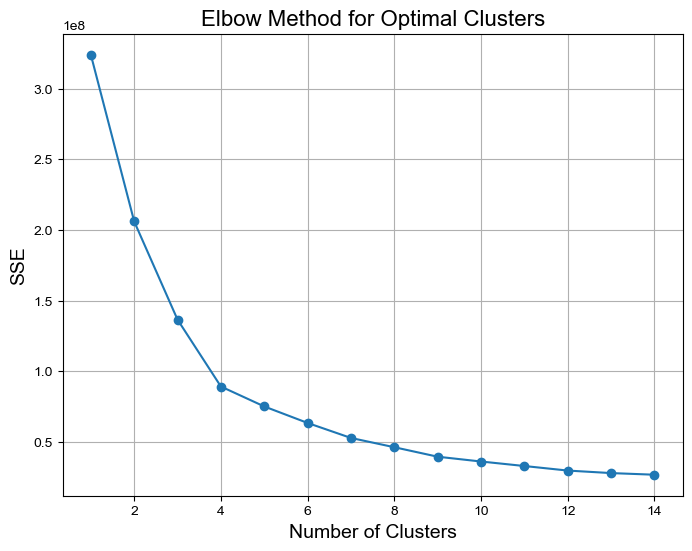

In [237]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. 读取嵌入文件内容
file_path = 'H:\文章\预测\embedding\\embedding.txt'

# 假设文件内容是以三维向量存储，数值用逗号分隔
embeddings = []
taitou = []
labels_real = []
for i in range(100):
    with open(f"H:\文章\预测\embedding\\embedding{i}.txt", 'r') as file:
        for line in file:
            # 如果行中包含 \\OOH\\, \\O\\ 或 \\OH\\，则跳过
            if any(substring in line for substring in ["\\OOH\\", "\\O\\", "\\OH\\"]):
                continue

            taitou.append(line.split("\t")[0].split("[")[1].split("]")[0])
            line = line.split("\t")[1]  # 提取向量部分
            current_sample = list(map(float, line.strip().split(',')))  # 转换为浮点数列表
            embeddings.append(current_sample)

# 转为 NumPy 数组
embeddings = np.array(embeddings)  # 2D array: (samples, features)
print(f"Original Embedding Shape: {embeddings.shape}")

# 2. t-SNE 降维
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=10000)
reduced_embeddings = tsne.fit_transform(embeddings)

# 3. 使用肘部法则选择最佳聚类数量
sse = []  # 存储每个聚类数量的 SSE 值
cluster_range = range(1, 15)  # 尝试从 1 到 10 个聚类

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(reduced_embeddings)
    sse.append(kmeans.inertia_)  # KMeans 的 inertia_ 属性即 SSE 值

# 绘制肘部法则图
plt.figure(figsize=(8, 6))
plt.plot(cluster_range, sse, marker='o')
plt.xlabel('Number of Clusters', fontsize=14)
plt.ylabel('SSE', fontsize=14)
plt.title('Elbow Method for Optimal Clusters', fontsize=16)
plt.grid(True)
plt.show()



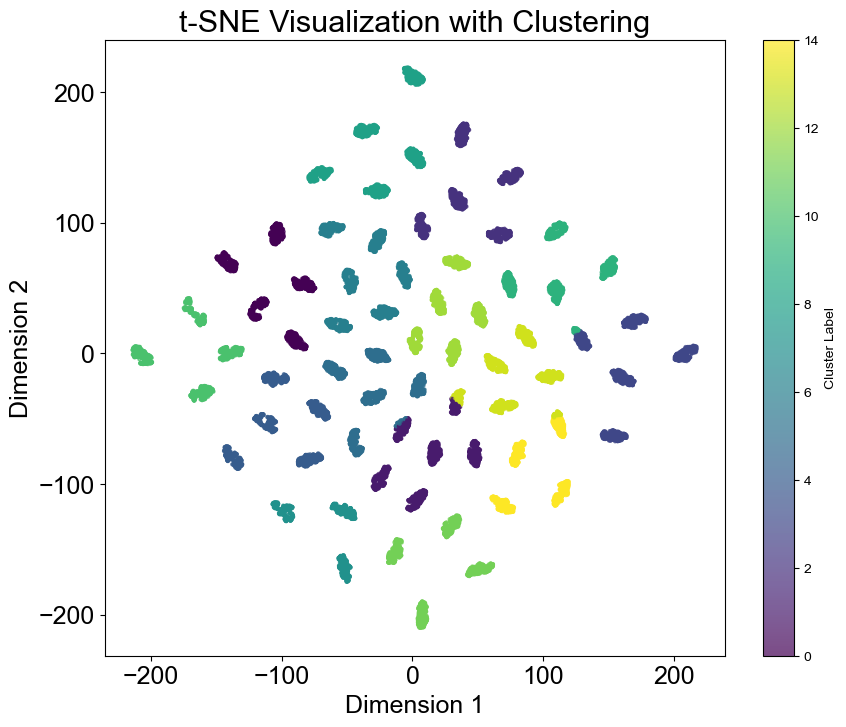

In [236]:
# 根据肘部法则图选择合适的 n_clusters 值
n_clusters = 15  # 例如通过观察肘部法则图手动选择聚类数量

# 4. KMeans 聚类
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(reduced_embeddings)

# 5. 可视化
plt.rcParams['font.family'] = 'Arial'  # 设置字体为 Arial
plt.figure(figsize=(10, 8))

# 使用聚类标签设置点的颜色
scatter = plt.scatter(
    reduced_embeddings[:, 0],
    reduced_embeddings[:, 1],
    c=cluster_labels,  # 使用聚类标签作为颜色
    cmap='viridis',    # 颜色映射
    s=5,
    alpha=0.7
)

# 添加颜色条
plt.colorbar(scatter, label="Cluster Label")
plt.title("t-SNE Visualization with Clustering", fontsize=22)  # 标题字号 22
plt.xlabel("Dimension 1", fontsize=18)  # 横坐标标题字号 18
plt.ylabel("Dimension 2", fontsize=18)  # 纵坐标标题字号 18
plt.tick_params(axis='both', which='major', labelsize=18)  # 坐标轴刻度字号 18
plt.show()

2
Original Embedding Shape: (4822, 128)
Original Embedding Shape: (4223, 128)


c:\Users\PS\anaconda3\envs\ocp-m\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=17.
  warnings.warn(


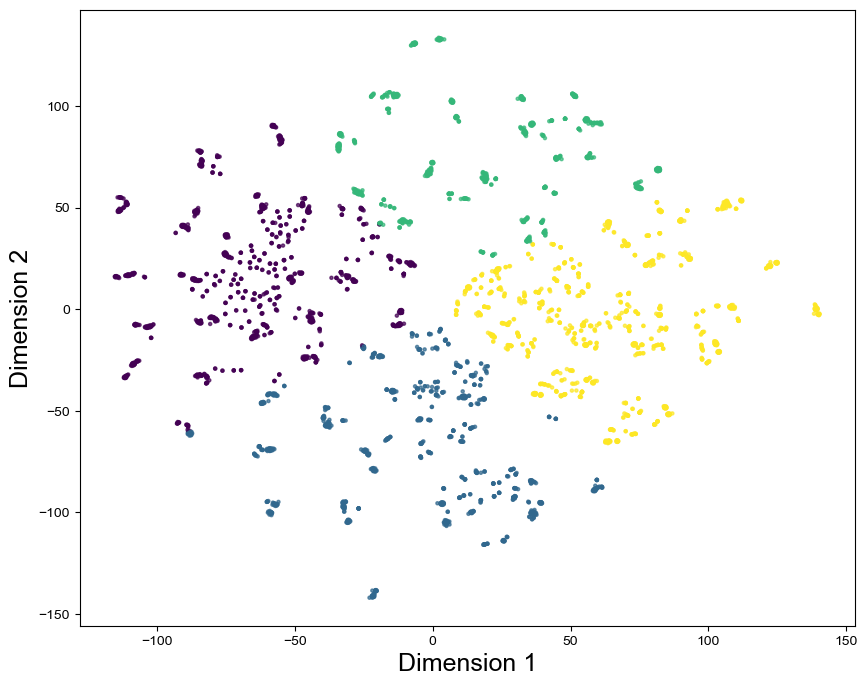

In [231]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. 读取嵌入文件内容
file_path = 'H:\\文章\\大模型微调\\embedding.txt'

# 假设文件内容是以三维向量存储，数值用逗号分隔
embeddings = []
taitou = []
labels_real = []
with open(file_path, 'r') as file:
    for line in file:
        taitou.append(line.split("\t")[0].split("[")[1].split("]")[0])
        line = line.split("\t")[1]  # 提取向量部分
        current_sample = list(map(float, line.strip().split(',')))  # 转换为浮点数列表
        embeddings.append(current_sample)
with open("H:\文章\data\\filter_total_removetest_sidtodir.txt", 'r') as f:
    data = f.readlines()
    for i in range(len(data)):
        absorate = data[int(taitou[i])].split("\\")[-3]
        if absorate == "O":
            labels_real.append(1)
        elif absorate == "OH":
            labels_real.append(2)
        elif absorate == "OOH":
            labels_real.append(3)
        else:
            labels_real.append(0)
print(labels_real[0])

embeddings_slab = []
for i in range(len(embeddings)):
    if labels_real[i] != 0:
        embeddings_slab.append(embeddings[i])

# 转为 NumPy 数组
embeddings = np.array(embeddings)  # 2D array: (samples, features)
embeddings_slab = np.array(embeddings_slab)
print(f"Original Embedding Shape: {embeddings.shape}")
print(f"Original Embedding Shape: {embeddings_slab.shape}")

# 2. t-SNE 降维
tsne = TSNE(n_components=2, random_state=42, perplexity=20, n_iter=10000)
reduced_embeddings = tsne.fit_transform(embeddings_slab)

# 3. 聚类（KMeans）
n_clusters = 4  # 设置聚类数量
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(reduced_embeddings)

# 4. 可视化
plt.rcParams['font.family'] = 'Arial'  # 设置字体为 Arial
plt.figure(figsize=(10, 8))

# 使用聚类标签设置点的颜色
scatter = plt.scatter(
    reduced_embeddings[:, 0],
    reduced_embeddings[:, 1],
    c=cluster_labels,  # 使用聚类标签作为颜色
    cmap='viridis',    # 颜色映射
    s=5,
    alpha=0.7
)

# 添加颜色条
# plt.colorbar(scatter, label="Cluster Label")
# plt.title("t-SNE Visualization with Clustering", fontsize=22)  # 标题字号 22
plt.xlabel("Dimension 1", fontsize=18)  # 横坐标标题字号 18
plt.ylabel("Dimension 2", fontsize=18)  # 纵坐标标题字号 18
# plt.tick_params(axis='both', which='major', labelsize=18)  # 坐标轴刻度字号 18
plt.show()


In [197]:
import os

# 假设 a_list 定义在这里
a_list = ["Cr", "Cu", "Fe", "Mn", "Ni", "Ti", "V", "Zn"]

# 定义一个检查重复的函数
def has_duplicates(lst):
    return len(lst) != len(set(lst))

# 设置文件夹路径
folder_path = "D:\\POSCAR_data_four\\POSCAR_data_four"

# 获取目标文件夹下的所有子文件夹
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
abssad = []

for ele in subfolders:
    txt = ele.split("\\")[-1]
    eles = txt.split('_')[:4]
    if has_duplicates(eles):
        continue
    if "Sc" not in ele:
        abssad.append(ele)

print(len(abssad))
print(abssad[0].split('\\')[-1])

target_kongjian = []
for absd in abssad:
    x1wa = absd.split('\\')[-1]
    target_kongjian.append(x1wa.split('_'))

print(target_kongjian[0])

# 定义一个函数，将前四个元素和后面对应的数字进行排列
def reorder_elements(data, a_list):
    ordered_data = []
    for entry in data:
        # 提取前四个元素
        elements = entry[:4]
        # 提取后面对应的数字
        numbers = entry[4:]
        
        # 创建一个字典以便按a_list的顺序排列
        element_dict = {ele: number for ele, number in zip(elements, numbers)}
        
        # 按a_list顺序排列
        ordered_numbers = [element_dict.get(a) for a in a_list if a in element_dict]
        
        # 组合结果
        ordered_entry = elements + ordered_numbers
        ordered_data.append(ordered_entry)
    
    return ordered_data

# 调用函数处理 target_kongjian
reordered_kongjian = reorder_elements(target_kongjian, a_list)

# 输出处理结果
print(reordered_kongjian[0])
from collections import Counter
counter = Counter()
# 统计出现频次
for element in reordered_kongjian:
    for item in element[:4]:  # 只取前四个字符串
        if item in a_list:
            counter[item] += 1

# 按目标顺序排序
sorted_counts = {key: counter[key] for key in a_list}

# 输出结果
print(sorted_counts)


17501
Cr_Fe_Cu_Zn_10_11_15_6
['Cr', 'Fe', 'Cu', 'Zn', '10', '11', '15', '6']
['Cr', 'Fe', 'Cu', 'Zn', '10', '15', '11', '6']
{'Cr': 8751, 'Cu': 8750, 'Fe': 8751, 'Mn': 8751, 'Ni': 8750, 'Ti': 8750, 'V': 8750, 'Zn': 8751}


In [168]:
meyset = set()
for adsd in reordered_kongjian:
    str_yuansuname = '_'.join(adsd[:4])
    meyset.add(str_yuansuname)
print(meyset)
namelist = list(meyset)
sigelist = []
import itertools

# 从 1 到 16 生成所有可能的四个数字组合
all_combinations = list(itertools.permutations(range(1, 17), 4))

# 将每个数字转换为字符串
all_combinations = [tuple(map(str, combination)) for combination in all_combinations]

print(len(all_combinations), all_combinations[0])
for ele in namelist:
    lsj = ele.split('_')
    for ele1 in all_combinations:
        sigelist.append(lsj + list(ele1))
print(len(sigelist), sigelist[0])

# ['#5FCDAC', '#03589B']


{'Cr_Mn_Ni_Cu', 'Ti_V_Cr_Mn', 'V_Fe_Cu_Zn', 'Ti_Fe_Cu_Zn', 'Ti_Fe_Ni_Zn', 'Mn_Fe_Ni_Cu', 'Cr_Mn_Fe_Cu', 'Ti_V_Cu_Zn', 'Ti_Cr_Fe_Zn', 'V_Cr_Fe_Zn', 'Ti_V_Ni_Cu', 'Cr_Mn_Cu_Zn', 'Cr_Fe_Ni_Zn', 'V_Mn_Fe_Zn', 'V_Cr_Ni_Cu', 'V_Cr_Ni_Zn', 'Ti_Cr_Mn_Ni', 'Ti_V_Fe_Ni', 'Ti_Mn_Ni_Zn', 'Mn_Fe_Ni_Zn', 'Cr_Fe_Cu_Zn', 'Ti_Cr_Fe_Ni', 'Ti_Cr_Mn_Cu', 'Ti_Cr_Mn_Fe', 'V_Mn_Cu_Zn', 'V_Mn_Fe_Ni', 'Ti_V_Ni_Zn', 'Ti_V_Mn_Fe', 'Ti_V_Cr_Zn', 'Ti_V_Cr_Ni', 'Ti_V_Cr_Fe', 'Ti_V_Mn_Ni', 'Ti_V_Mn_Zn', 'V_Mn_Ni_Zn', 'V_Fe_Ni_Cu', 'Ti_Cr_Fe_Cu', 'Ti_Cr_Mn_Zn', 'Ti_Mn_Ni_Cu', 'V_Cr_Mn_Zn', 'Ti_Fe_Ni_Cu', 'V_Cr_Cu_Zn', 'Mn_Ni_Cu_Zn', 'Ti_Mn_Fe_Zn', 'Ti_V_Mn_Cu', 'Cr_Ni_Cu_Zn', 'Ti_Cr_Ni_Zn', 'Ti_V_Fe_Zn', 'V_Fe_Ni_Zn', 'V_Cr_Fe_Cu', 'V_Mn_Fe_Cu', 'V_Mn_Ni_Cu', 'Ti_Cr_Cu_Zn', 'Cr_Mn_Ni_Zn', 'Ti_V_Cr_Cu', 'Cr_Mn_Fe_Ni', 'Ti_Cr_Ni_Cu', 'Ti_Mn_Fe_Ni', 'Ti_V_Fe_Cu', 'Fe_Ni_Cu_Zn', 'V_Cr_Fe_Ni', 'Ti_Mn_Fe_Cu', 'V_Cr_Mn_Fe', 'V_Ni_Cu_Zn', 'Mn_Fe_Cu_Zn', 'V_Cr_Mn_Cu', 'Cr_Mn_Fe_Zn', 'V_Cr_Mn_Ni', 'Ti_Mn_Cu_Zn', 'Cr_Fe_Ni_Cu',

In [184]:
def encode_2d_list(input_2d_list):
    encoded_2d_list = []
    
    # 遍历二维数组的每个子数组
    for input_list in input_2d_list:
        encoded_list = []
        # 对每个子数组进行编码
        for item in input_list:
            if item in a_list:
                # 将元素用它在 a_list 中的索引替代
                encoded_list.append(a_list.index(item))
            else:
                # 如果是数字的字符串，转换为整数
                try:
                    encoded_list.append(int(item))
                except ValueError:
                    print(f"无法转换: {item}")
        encoded_2d_list.append(encoded_list)
    
    return encoded_2d_list

encoded_tar = encode_2d_list(target_kongjian)
encoded_tol = encode_2d_list(sigelist)
encoded_tol.append([0, 3, 2, 7, 0, 0, 0, 0])
print(encoded_tol[0], encoded_tar[0])
indexoftar = []
for ads in encoded_tar:
    indexoftar.append(encoded_tol.index(ads))
print(len(indexoftar), indexoftar[0])


[0, 3, 4, 1, 1, 2, 3, 4] [0, 2, 1, 7, 10, 11, 15, 6]
17501 899969


In [ ]:
encoded_tol

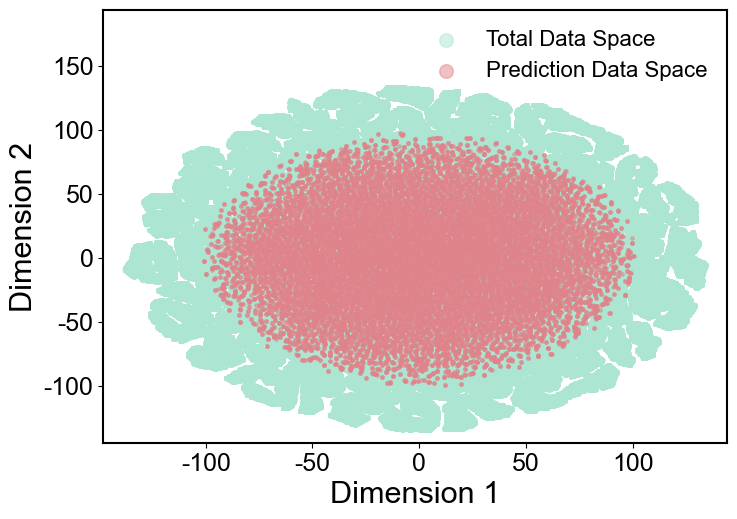

In [176]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import FormatStrFormatter

# 绘制散点图的函数
def plot_scatter(data1, data2, colors=['#E1838A', '#ACE6D3']):
    rcParams['font.family'] = 'Arial'
    plt.figure(figsize=(289.9 / 36, 202.41 / 36))
    
    # 绘制第一个数据集的散点图（Prediction data space）
    plt.scatter(data2[:, 0], data2[:, 1], color=colors[1], label='Total Data Space', alpha=0.5, s=6)
    
    # 绘制第二个数据集的散点图（Total Data Space）
    plt.scatter(data1[:, 0], data1[:, 1], color=colors[0], label='Prediction Data Space', alpha=0.5, s=6)

    # 调整坐标轴范围以增大显示区域
    plt.xlim(min(min(data1[:, 0]), min(data2[:, 0])) - 10, max(max(data1[:, 0]), max(data2[:, 0])) + 10)
    plt.ylim(min(min(data1[:, 1]), min(data2[:, 1])) - 10, max(max(data1[:, 1]), max(data2[:, 1])) + 60)

    # 设置 x 和 y 轴标签
    plt.xlabel('Dimension 1', fontsize=22)
    plt.ylabel('Dimension 2', fontsize=22)

    # 设置 x 轴和 y 轴刻度显示为小数点后一位
    plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%d'))
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%d'))

    # 设置坐标轴刻度字体大小
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    # 设置坐标轴边框线宽
    for spine in plt.gca().spines.values():
        spine.set_linewidth(1.5)
    
    # 添加图例并设置位置为右上方
    plt.legend(framealpha=0, fontsize=16, markerscale=4, loc='upper right')
    
    # 显示图形
    plt.show()
    
plot_scatter(tar_2d, tol_2d)


In [199]:
import os
import numpy as np

def has_duplicates(lst):
    return len(lst) != len(set(lst))

def create_directory(parent_dir, new_dir_name):
    # 创建新目录的完整路径
    new_dir_path = os.path.join(parent_dir, new_dir_name)
    
    # 检查目录是否已经存在
    if not os.path.exists(new_dir_path):
        os.makedirs(new_dir_path)
target_path = []

folder_path = "D:\POSCAR_data_four\\POSCAR_data_four"
# 获取目标文件夹下的所有子文件夹
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]

for folder in subfolders:
    txt = folder.split("\\")[-1]
    ele = txt.split('_')[:4]
    if has_duplicates(ele):
        continue
    create_directory(folder, "O")
    create_directory(folder, "OH")
    create_directory(folder, "OOH")
    poscar_path = os.path.join(folder, "POSCAR")
    with open(poscar_path, 'r') as f:
        lines = f.readlines()
    target_path.append(poscar_path)

    atom_coords= []
    for line in lines[8:120]:
        atom_coords.append(list(map(float, line.split()[:3])))
    # print(atom_coords[0])
    i = 0
    for coords in atom_coords:

        elements = lines[5].split()
        counts = lines[6].split()

        if 0.32 < float(coords[2]) < 0.33:
            # print(os.path.join(folder, f"O\\POSCAR{i}"))
            # print(coords[2])
            target_path.append(os.path.join(folder, f"O\\POSCAR{i}"))
            target_path.append(os.path.join(folder, f"OH\\POSCAR{i}"))
            target_path.append(os.path.join(folder, f"OOH\\POSCAR{i}"))

In [200]:
print(len(target_path))

1543543


In [15]:
import os
import numpy as np

def has_duplicates(lst):
    return len(lst) != len(set(lst))

def create_directory(parent_dir, new_dir_name):
    # 创建新目录的完整路径
    new_dir_path = os.path.join(parent_dir, new_dir_name)
    
    # 检查目录是否已经存在
    if not os.path.exists(new_dir_path):
        os.makedirs(new_dir_path)
target_path = []

folder_path = "D:\POSCAR_data_three"
# 获取目标文件夹下的所有子文件夹
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]

for folder in subfolders:
    txt = folder.split("\\")[-1]
    ele = txt.split('_')[:3]
    if has_duplicates(ele):
        continue
    create_directory(folder, "O")
    create_directory(folder, "OH")
    create_directory(folder, "OOH")
    poscar_path = os.path.join(folder, "POSCAR")
    with open(poscar_path, 'r') as f:
        lines = f.readlines()
    target_path.append(poscar_path)

    atom_coords= []
    for line in lines[8:120]:
        atom_coords.append(list(map(float, line.split()[:3])))
    # print(atom_coords[0])
    i = 0
    for coords in atom_coords:

        elements = lines[5].split()
        counts = lines[6].split()

        if 0.32 < float(coords[2]) < 0.33:
            # print(os.path.join(folder, f"O\\POSCAR{i}"))
            # print(coords[2])
            target_path.append(os.path.join(folder, f"O\\POSCAR{i}"))
            target_path.append(os.path.join(folder, f"OH\\POSCAR{i}"))
            target_path.append(os.path.join(folder, f"OOH\\POSCAR{i}"))

            with open(os.path.join(folder, f"O\\POSCAR{i}"), 'w') as f:
                elements.append("O")
                counts.append("1")
                f.writelines(lines[:5])
                f.writelines(" ".join(elements) + "\n")
                f.writelines(" ".join(counts) + "\n")
                f.writelines(lines[7:120])
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.391) + "\n")
            
            with open(os.path.join(folder, f"OH\\POSCAR{i}"), 'w') as f:
                elements.append("H")
                counts.append("1")
                f.writelines(lines[:5])
                f.writelines(" ".join(elements) + "\n")
                f.writelines(" ".join(counts) + "\n")
                f.writelines(lines[7:120])
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.391) + "\n")
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.441) + "\n")

            with open(os.path.join(folder, f"OOH\\POSCAR{i}"), 'w') as f:
                elements.insert(-2, "O")
                counts.append("1")
                f.writelines(lines[:5])
                f.writelines(" ".join(elements) + "\n")
                f.writelines(" ".join(counts) + "\n")
                f.writelines(lines[7:120])
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.391) + "\n")
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.451) + "\n")
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.501) + "\n")
            i += 1
        else:
            # print(coords[2])
            continue


In [16]:
print(len(target_path))

3087000


In [17]:
import os
import numpy as np

def has_duplicates(lst):
    return len(lst) != len(set(lst))

def create_directory(parent_dir, new_dir_name):
    # 创建新目录的完整路径
    new_dir_path = os.path.join(parent_dir, new_dir_name)
    
    # 检查目录是否已经存在
    if not os.path.exists(new_dir_path):
        os.makedirs(new_dir_path)
target_path = []

folder_path = "D:\POSCAR_data_tWO"
# 获取目标文件夹下的所有子文件夹
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]

for folder in subfolders:
    txt = folder.split("\\")[-1]
    ele = txt.split('_')[:2]
    if has_duplicates(ele):
        continue
    create_directory(folder, "O")
    create_directory(folder, "OH")
    create_directory(folder, "OOH")
    poscar_path = os.path.join(folder, "POSCAR")
    with open(poscar_path, 'r') as f:
        lines = f.readlines()
    target_path.append(poscar_path)

    atom_coords= []
    for line in lines[8:120]:
        atom_coords.append(list(map(float, line.split()[:3])))
    # print(atom_coords[0])
    i = 0
    for coords in atom_coords:

        elements = lines[5].split()
        counts = lines[6].split()

        if 0.32 < float(coords[2]) < 0.33:
            # print(os.path.join(folder, f"O\\POSCAR{i}"))
            # print(coords[2])
            target_path.append(os.path.join(folder, f"O\\POSCAR{i}"))
            target_path.append(os.path.join(folder, f"OH\\POSCAR{i}"))
            target_path.append(os.path.join(folder, f"OOH\\POSCAR{i}"))

            with open(os.path.join(folder, f"O\\POSCAR{i}"), 'w') as f:
                elements.append("O")
                counts.append("1")
                f.writelines(lines[:5])
                f.writelines(" ".join(elements) + "\n")
                f.writelines(" ".join(counts) + "\n")
                f.writelines(lines[7:120])
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.391) + "\n")
            
            with open(os.path.join(folder, f"OH\\POSCAR{i}"), 'w') as f:
                elements.append("H")
                counts.append("1")
                f.writelines(lines[:5])
                f.writelines(" ".join(elements) + "\n")
                f.writelines(" ".join(counts) + "\n")
                f.writelines(lines[7:120])
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.391) + "\n")
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.441) + "\n")

            with open(os.path.join(folder, f"OOH\\POSCAR{i}"), 'w') as f:
                elements.insert(-2, "O")
                counts.append("1")
                f.writelines(lines[:5])
                f.writelines(" ".join(elements) + "\n")
                f.writelines(" ".join(counts) + "\n")
                f.writelines(lines[7:120])
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.391) + "\n")
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.451) + "\n")
                f.writelines("  " + str(coords[0]) + "  " + str(coords[1]) + "  " + str(0.501) + "\n")
            i += 1
        else:
            # print(coords[2])
            continue


In [18]:
print(len(target_path))

423360
